# PRISM Complete Experiment

**Platform-Robust In-Field Sequential Monitoring for Silicon Lifecycle
Management**

This notebook is the canonical executable source for the PRISM experiment. It
contains the collection package, workload harness, command-line operations,
validation, unit tests, and guarded experiment controls that previously lived
in separate Python files.

Run the notebook from top to bottom once on each machine. The source cells
materialize an ephemeral `.prism_runtime/` tree because the collection engine
starts isolated subprocesses. That tree is Git-ignored and disposable; rerun
the source cells to rebuild it. By default, raw data are written to the
repository's Git-ignored `data/raw/` directory. Set `PRISM_DATA_ROOT` before
starting Jupyter to use a larger local or server volume without editing cells.

Safety rules:

- `Run All` performs setup, preflight, and unit tests only.
- Hardware probes, DICE import, smoke collection, and production collection
  remain disabled until their explicit boolean guard is changed to `True`.
- Production collection still requires a clean committed Git revision.
- Jupyter outputs and documented boolean run switches are treated as execution
  state only; any other notebook source change still blocks collection.
- Do not edit `.prism_runtime/`; edit the corresponding cell in this notebook.


## Experiment flow

1. Materialize and validate the complete runtime.
2. Optionally import the frozen DICE baseline for retrospective comparison.
3. Probe Apple M2 Pro capabilities and collect a matched smoke pair.
4. Repeat the same probe and smoke gate on AMD EPYC/Linux.
5. Freeze the shared schema after both smoke gates pass.
6. Collect calibration/development rows, then freeze the method.
7. Explicitly unlock the held-out test rows.
8. Monitor run validity, channel availability, and benign hours daily.

The immutable plan declares 252 runs and 64.8 total machine-hours across the
two platforms. Review `docs/extension-collection-contract.md` before production.


## 1. Locate the repository and create the disposable runtime


In [1]:

from __future__ import annotations

import json
import os
import platform
import shutil
import subprocess
import sys
from pathlib import Path


MINIMUM_PYTHON = (3, 10)
if sys.version_info < MINIMUM_PYTHON:
    raise RuntimeError(
        "PRISM requires Python 3.10 or newer; detected "
        + platform.python_version()
    )


def find_repository_root(start: Path) -> Path:
    candidates: list[Path] = []
    override = os.environ.get("PRISM_REPO_ROOT")
    if override:
        candidates.append(Path(override).expanduser())
    resolved_start = start.expanduser().resolve()
    candidates.extend((resolved_start, *resolved_start.parents))
    seen: set[Path] = set()
    for candidate in candidates:
        candidate = candidate.resolve()
        if candidate in seen:
            continue
        seen.add(candidate)
        if (
            (candidate / ".git").exists()
            and (candidate / "configs" / "experiment-matrix.toml").is_file()
        ):
            return candidate
    raise RuntimeError(
        "The PRISM repository root could not be located. Start Jupyter "
        "inside the checkout or set PRISM_REPO_ROOT to its absolute path."
    )


REPO_ROOT = find_repository_root(Path.cwd())
DATA_ROOT = Path(
    os.environ.get("PRISM_DATA_ROOT", str(REPO_ROOT / "data"))
).expanduser().resolve()
DATA_ROOT.mkdir(parents=True, exist_ok=True)
RUNTIME_ROOT = REPO_ROOT / ".prism_runtime"
RUNTIME_ROOT.mkdir(parents=True, exist_ok=True)
for runtime_directory in ("src/prism_slm", "scripts", "tests"):
    (RUNTIME_ROOT / runtime_directory).mkdir(parents=True, exist_ok=True)
os.chdir(REPO_ROOT)
os.environ["PRISM_REPO_ROOT"] = str(REPO_ROOT)
os.environ["PRISM_DATA_ROOT"] = str(DATA_ROOT)

runtime_src = str(RUNTIME_ROOT / "src")
existing_pythonpath = os.environ.get("PYTHONPATH", "")
os.environ["PYTHONPATH"] = (
    runtime_src
    if not existing_pythonpath
    else runtime_src + os.pathsep + existing_pythonpath
)

print(f"Repository: {REPO_ROOT}")
print(f"Data root: {DATA_ROOT}")
print(f"Disposable runtime: {RUNTIME_ROOT}")
print(
    "Host: "
    f"{platform.system()} {platform.machine()} | "
    f"Python {platform.python_version()} | {sys.executable}"
)


Repository: /Users/hsiaopingni/Documents/New project/PRISM-SLM
Data root: /Users/hsiaopingni/Documents/New project/PRISM-SLM/data
Disposable runtime: /Users/hsiaopingni/Documents/New project/PRISM-SLM/.prism_runtime
Host: Darwin arm64 | Python 3.13.5 | /opt/anaconda3/bin/python


## 2. Embedded source

Each cell below is a complete former Python file. Running the cell writes that
source into `.prism_runtime/` without changing tracked repository files.


### `src/prism_slm/__init__.py`


In [2]:
%%writefile .prism_runtime/src/prism_slm/__init__.py
"""PRISM-SLM research scaffolding."""

from .contracts import ChannelSpec, PlatformSpec, SemanticGroup

__all__ = ["ChannelSpec", "PlatformSpec", "SemanticGroup"]


Overwriting .prism_runtime/src/prism_slm/__init__.py


### `src/prism_slm/contracts.py`


In [3]:
%%writefile .prism_runtime/src/prism_slm/contracts.py
"""Typed contracts for heterogeneous host telemetry."""

from __future__ import annotations

from dataclasses import dataclass, field
from enum import Enum
from typing import Iterable


class SemanticGroup(str, Enum):
    COMPUTE = "compute"
    MEMORY = "memory"
    IO = "io"
    THERMAL_POWER = "thermal_power"
    ACCELERATOR = "accelerator"
    AVAILABILITY = "availability"


@dataclass(frozen=True)
class ChannelSpec:
    native_name: str
    unit: str
    semantic_group: SemanticGroup
    source: str
    sampling_period_seconds: float
    cumulative: bool = False
    description: str = ""

    def __post_init__(self) -> None:
        if not self.native_name.strip():
            raise ValueError("native_name must be non-empty")
        if not self.unit.strip():
            raise ValueError("unit must be non-empty")
        if not self.source.strip():
            raise ValueError("source must be non-empty")
        if self.sampling_period_seconds <= 0:
            raise ValueError("sampling_period_seconds must be positive")


@dataclass(frozen=True)
class PlatformSpec:
    platform_id: str
    architecture: str
    operating_system: str
    observability: str
    channels: tuple[ChannelSpec, ...] = field(default_factory=tuple)

    @classmethod
    def from_channels(
        cls,
        *,
        platform_id: str,
        architecture: str,
        operating_system: str,
        observability: str,
        channels: Iterable[ChannelSpec],
    ) -> "PlatformSpec":
        return cls(
            platform_id=platform_id,
            architecture=architecture,
            operating_system=operating_system,
            observability=observability,
            channels=tuple(channels),
        )

    def __post_init__(self) -> None:
        values = {
            "platform_id": self.platform_id,
            "architecture": self.architecture,
            "operating_system": self.operating_system,
            "observability": self.observability,
        }
        for name, value in values.items():
            if not value.strip():
                raise ValueError(f"{name} must be non-empty")

        names = [channel.native_name for channel in self.channels]
        if len(names) != len(set(names)):
            raise ValueError("channel native_name values must be unique per platform")

    @property
    def available_groups(self) -> frozenset[SemanticGroup]:
        return frozenset(channel.semantic_group for channel in self.channels)


Overwriting .prism_runtime/src/prism_slm/contracts.py


### `src/prism_slm/workload_harness.py`


In [4]:
%%writefile .prism_runtime/src/prism_slm/workload_harness.py
"""Cross-platform workload and pressure harness for PRISM collection.

The harness is intentionally a separate process. Terminating a collector does
not leave a compute loop running, and every independent run starts fresh state.
"""

from __future__ import annotations

import argparse
import hashlib
import os
import random
import signal
import threading
import time
import urllib.parse
import zlib

import numpy as np


SEED = 830616
WORKLOADS = ("PY_STATS", "PY_AI", "BROWSER", "VIDEO_SW")
STRESSORS = (
    "NOMINAL",
    "ATOMIC",
    "BRANCH",
    "CACHE",
    "MEMBW",
    "TLB",
    "THERMAL_SHIFT",
    "POWER_SHIFT",
    "DEGRADATION_PROXY",
)
CONTROL_SCENARIOS = ("CONTROLLED_CRASH", "TELEMETRY_INTERRUPTION")
SCENARIOS = STRESSORS + CONTROL_SCENARIOS


def _stop_event() -> threading.Event:
    event = threading.Event()

    def stop(_signum: int, _frame: object) -> None:
        event.set()

    signal.signal(signal.SIGTERM, stop)
    signal.signal(signal.SIGINT, stop)
    return event


def _memory_mb() -> int:
    value = int(os.environ.get("PRISM_STRESS_MB", "128"))
    return min(max(value, 16), 1024)


def workload_py_stats(stop: threading.Event) -> None:
    rng = np.random.default_rng(SEED)
    values = rng.standard_normal(8_000_000, dtype=np.float32)
    while not stop.is_set():
        _ = (
            float(values.mean()),
            float(values.std()),
            float(np.percentile(values[::16], 95)),
        )
        values[::1024] += np.float32(0.0001)


def workload_py_ai(stop: threading.Event) -> None:
    rng = np.random.default_rng(SEED)
    left = rng.standard_normal((768, 768), dtype=np.float32)
    right = rng.standard_normal((768, 768), dtype=np.float32)
    while not stop.is_set():
        result = left @ right
        left, right = right, np.tanh(result).astype(np.float32, copy=False)


def workload_browser(stop: threading.Event) -> None:
    # A network-free, deterministic web-processing workload. It avoids making
    # Internet availability a hidden experimental variable.
    blocks = [
        (
            f"<article id='{idx}'><a href='/paper/{idx}?view=full'>"
            f"Telemetry article {idx}</a><p>{'silicon ' * 200}</p></article>"
        )
        for idx in range(512)
    ]
    document = ("<html><body>" + "".join(blocks) + "</body></html>").encode()
    while not stop.is_set():
        compressed = zlib.compress(document, level=3)
        restored = zlib.decompress(compressed).decode()
        for token in restored.split("href='")[1::32]:
            urllib.parse.urlparse(token.split("'", 1)[0])
        hashlib.sha256(compressed).digest()


def workload_video_sw(stop: threading.Event) -> None:
    rng = np.random.default_rng(SEED)
    frame = rng.integers(0, 256, size=(720, 1280, 3), dtype=np.uint8)
    while not stop.is_set():
        gray = (
            0.299 * frame[:, :, 0]
            + 0.587 * frame[:, :, 1]
            + 0.114 * frame[:, :, 2]
        ).astype(np.uint8)
        compressed = zlib.compress(gray[::2, ::2].tobytes(), level=1)
        zlib.decompress(compressed)
        frame = np.roll(frame, 1, axis=1)


def stress_nominal(stop: threading.Event) -> None:
    stop.wait()


def stress_atomic(stop: threading.Event) -> None:
    lock = threading.Lock()
    counter = [0]

    def worker() -> None:
        while not stop.is_set():
            with lock:
                counter[0] += 1

    count = max(2, (os.cpu_count() or 2) // 2)
    threads = [threading.Thread(target=worker, daemon=True) for _ in range(count)]
    for thread in threads:
        thread.start()
    while not stop.wait(0.1):
        pass


def stress_branch(stop: threading.Event) -> None:
    rng = random.Random(SEED)
    value = 0
    while not stop.is_set():
        bits = rng.getrandbits(32)
        if bits & 1:
            value += 3
        elif bits & 2:
            value -= 2
        elif bits & 4:
            value ^= bits
        else:
            value += 1


def stress_cache(stop: threading.Event) -> None:
    rng = np.random.default_rng(SEED)
    count = _memory_mb() * 1024 * 1024 // np.dtype(np.float32).itemsize
    values = rng.standard_normal(count, dtype=np.float32)
    indices = rng.integers(0, count, size=min(count, 1_000_000), dtype=np.int64)
    while not stop.is_set():
        _ = float(values[indices].sum())
        indices = np.roll(indices, 1024)


def stress_membw(stop: threading.Event) -> None:
    size = _memory_mb() * 1024 * 1024
    source = np.zeros(size, dtype=np.uint8)
    target = np.ones(size, dtype=np.uint8)
    while not stop.is_set():
        np.copyto(source, target)
        source += np.uint8(1)
        source, target = target, source


def stress_tlb(stop: threading.Event) -> None:
    rng = np.random.default_rng(SEED)
    size = _memory_mb() * 1024 * 1024
    values = np.zeros(size, dtype=np.uint8)
    pages = np.arange(0, size, 4096, dtype=np.int64)
    while not stop.is_set():
        rng.shuffle(pages)
        for start in range(0, len(pages), 4096):
            if stop.is_set():
                return
            block = pages[start : start + 4096]
            values[block] = values[block] + np.uint8(1)


def _matrix_burst(
    stop: threading.Event,
    *,
    active_seconds: float,
    idle_seconds: float,
) -> None:
    rng = np.random.default_rng(SEED)
    left = rng.standard_normal((512, 512), dtype=np.float32)
    right = rng.standard_normal((512, 512), dtype=np.float32)
    while not stop.is_set():
        deadline = time.monotonic() + active_seconds
        while time.monotonic() < deadline and not stop.is_set():
            result = left @ right
            left, right = right, np.tanh(result).astype(np.float32, copy=False)
        if idle_seconds > 0:
            stop.wait(idle_seconds)


def stress_thermal_shift(stop: threading.Event) -> None:
    """Sustained compute-load change used as a portable thermal-condition proxy."""

    _matrix_burst(stop, active_seconds=2.0, idle_seconds=0.02)


def stress_power_shift(stop: threading.Event) -> None:
    """Repeatable duty-cycled compute used as a portable power-demand shift."""

    _matrix_burst(stop, active_seconds=0.35, idle_seconds=0.15)


def stress_degradation_proxy(stop: threading.Event) -> None:
    """Progressively increase compute duty cycle without claiming physical aging."""

    rng = np.random.default_rng(SEED)
    left = rng.standard_normal((512, 512), dtype=np.float32)
    right = rng.standard_normal((512, 512), dtype=np.float32)
    stage = 0
    stage_started = time.monotonic()
    while not stop.is_set():
        active_seconds = min(0.10 + 0.08 * stage, 0.90)
        idle_seconds = max(1.0 - active_seconds, 0.10)
        deadline = time.monotonic() + active_seconds
        while time.monotonic() < deadline and not stop.is_set():
            result = left @ right
            left, right = right, np.tanh(result).astype(np.float32, copy=False)
        stop.wait(idle_seconds)
        if time.monotonic() - stage_started >= 30:
            stage = min(stage + 1, 10)
            stage_started = time.monotonic()


WORKLOAD_FUNCTIONS = {
    "PY_STATS": workload_py_stats,
    "PY_AI": workload_py_ai,
    "BROWSER": workload_browser,
    "VIDEO_SW": workload_video_sw,
}
STRESSOR_FUNCTIONS = {
    "NOMINAL": stress_nominal,
    "ATOMIC": stress_atomic,
    "BRANCH": stress_branch,
    "CACHE": stress_cache,
    "MEMBW": stress_membw,
    "TLB": stress_tlb,
    "THERMAL_SHIFT": stress_thermal_shift,
    "POWER_SHIFT": stress_power_shift,
    "DEGRADATION_PROXY": stress_degradation_proxy,
}


def main() -> int:
    parser = argparse.ArgumentParser()
    parser.add_argument("--role", choices=("workload", "stressor"), required=True)
    parser.add_argument("--name", required=True)
    args = parser.parse_args()

    name = args.name.upper()
    functions = WORKLOAD_FUNCTIONS if args.role == "workload" else STRESSOR_FUNCTIONS
    if name not in functions:
        raise SystemExit(f"Unsupported {args.role}: {name}")

    stop = _stop_event()
    functions[name](stop)
    return 0


if __name__ == "__main__":
    raise SystemExit(main())


Overwriting .prism_runtime/src/prism_slm/workload_harness.py


### `src/prism_slm/collection.py`


In [5]:
%%writefile .prism_runtime/src/prism_slm/collection.py
"""Synchronized, provenance-safe telemetry collection for PRISM."""

from __future__ import annotations

import csv
import hashlib
import json
import math
import os
import platform
import re
import shutil
import statistics
import subprocess
import sys
import threading
import time
import traceback
from dataclasses import dataclass
from datetime import datetime, timezone
from pathlib import Path
from typing import Any, Iterable

import psutil

from .contracts import SemanticGroup
from .workload_harness import SCENARIOS, STRESSORS, WORKLOADS


QUALITY_CONTRACT = {
    "primary_channel_minimum_fraction": 0.95,
    "apple_temperature_minimum_fraction": 0.70,
    "apple_temperature_min_celsius": 15.0,
    "apple_temperature_max_celsius": 125.0,
    "maximum_quality_flag_fraction": 0.25,
}


def utc_now() -> str:
    return datetime.now(timezone.utc).isoformat().replace("+00:00", "Z")


def utc_date() -> str:
    return datetime.now(timezone.utc).date().isoformat()


def safe_json(value: Any) -> Any:
    if isinstance(value, float) and not math.isfinite(value):
        return None
    if isinstance(value, dict):
        return {str(key): safe_json(item) for key, item in value.items()}
    if isinstance(value, (list, tuple)):
        return [safe_json(item) for item in value]
    return value


def dump_json(path: Path, value: Any) -> None:
    path.write_text(
        json.dumps(safe_json(value), indent=2, sort_keys=True) + "\n",
        encoding="utf-8",
    )


def append_jsonl(stream: Any, value: dict[str, Any]) -> None:
    stream.write(json.dumps(safe_json(value), sort_keys=True) + "\n")
    stream.flush()


def _rate(current: float | None, previous: float | None, elapsed: float) -> float | None:
    if current is None or previous is None or elapsed <= 0:
        return None
    delta = current - previous
    return delta / elapsed if delta >= 0 else None


def _mean_cpu_percent(per_logical: Iterable[float | int]) -> float | None:
    values = [
        float(value)
        for value in per_logical
        if isinstance(value, (int, float))
    ]
    return statistics.fmean(values) if values else None


class HostSampler:
    """Portable host telemetry backed by psutil."""

    def __init__(self) -> None:
        psutil.cpu_percent(interval=None)
        psutil.cpu_times_percent(interval=None)
        self.previous_time: float | None = None
        self.previous_cpu_times: Any = None
        self.previous_disk: Any = None
        self.previous_net: Any = None

    def sample(self) -> dict[str, Any]:
        now = time.monotonic()
        elapsed = now - self.previous_time if self.previous_time is not None else 0.0
        output: dict[str, Any] = {}

        output["cpu_percent_psutil"] = psutil.cpu_percent(interval=None)
        per_logical_cpu = psutil.cpu_percent(interval=None, percpu=True)
        output["cpu_percent_per_logical"] = per_logical_cpu
        try:
            cumulative_cpu = psutil.cpu_times()
        except (OSError, PermissionError):
            cumulative_cpu = None
        derived_utilization = None
        if cumulative_cpu is not None and self.previous_cpu_times is not None:
            fields = (
                "user",
                "nice",
                "system",
                "idle",
                "iowait",
                "irq",
                "softirq",
                "steal",
            )
            total_delta = sum(
                max(
                    0.0,
                    float(getattr(cumulative_cpu, field, 0.0))
                    - float(getattr(self.previous_cpu_times, field, 0.0)),
                )
                for field in fields
            )
            idle_delta = max(
                0.0,
                float(getattr(cumulative_cpu, "idle", 0.0))
                - float(getattr(self.previous_cpu_times, "idle", 0.0)),
            ) + max(
                0.0,
                float(getattr(cumulative_cpu, "iowait", 0.0))
                - float(getattr(self.previous_cpu_times, "iowait", 0.0)),
            )
            if total_delta > 0:
                derived_utilization = 100.0 * (1.0 - min(idle_delta, total_delta) / total_delta)
        # The interval=None aggregate from psutil is retained as a raw audit
        # channel, but it can collapse to repeated zeroes on macOS. Averaging
        # the simultaneously sampled logical-CPU percentages is complete at
        # 5 Hz on both platforms and is the canonical portable utilization.
        output["cpu_percent"] = _mean_cpu_percent(per_logical_cpu)
        output["cpu_utilization_derived_percent"] = derived_utilization
        cpu_times = psutil.cpu_times_percent(interval=None)
        output["cpu_times_percent"] = {
            name: getattr(cpu_times, name, None)
            for name in (
                "user",
                "system",
                "idle",
                "nice",
                "iowait",
                "irq",
                "softirq",
                "steal",
            )
        }
        try:
            output["load_average"] = list(psutil.getloadavg())
        except (AttributeError, OSError):
            output["load_average"] = None

        try:
            stats = psutil.cpu_stats()
        except (OSError, PermissionError):
            stats = None
        output["context_switches_total"] = getattr(stats, "ctx_switches", None)
        output["interrupts_total"] = getattr(stats, "interrupts", None)
        output["soft_interrupts_total"] = getattr(stats, "soft_interrupts", None)
        output["syscalls_total"] = getattr(stats, "syscalls", None)

        # psutil.cpu_freq() serially opens every scaling_cur_freq file on
        # Linux. On high-core-count EPYC hosts that alone can exceed one
        # second, so Linux frequency is collected once through the bounded
        # representative sysfs sampler below.
        if platform.system() == "Linux":
            frequency = None
        else:
            try:
                frequency = psutil.cpu_freq()
            except (OSError, PermissionError):
                frequency = None
        output["cpu_frequency_mhz"] = (
            {
                "current": frequency.current,
                "minimum": frequency.min,
                "maximum": frequency.max,
            }
            if frequency is not None
            else None
        )

        try:
            memory = psutil.virtual_memory()
        except (OSError, PermissionError):
            memory = None
        output["memory"] = (
            {
                name: getattr(memory, name, None)
                for name in (
                    "total",
                    "available",
                    "used",
                    "free",
                    "active",
                    "inactive",
                    "wired",
                    "cached",
                    "percent",
                )
            }
            if memory is not None
            else None
        )
        try:
            swap = psutil.swap_memory()
        except (OSError, PermissionError):
            swap = None
        output["swap"] = (
            {
                name: getattr(swap, name, None)
                for name in ("total", "used", "free", "percent", "sin", "sout")
            }
            if swap is not None
            else None
        )

        try:
            disk = psutil.disk_io_counters(perdisk=False)
        except (OSError, PermissionError):
            disk = None
        if disk is not None:
            output["disk"] = {
                "read_bytes_total": disk.read_bytes,
                "write_bytes_total": disk.write_bytes,
                "read_count_total": disk.read_count,
                "write_count_total": disk.write_count,
                "read_bytes_per_second": _rate(
                    disk.read_bytes,
                    self.previous_disk.read_bytes if self.previous_disk else None,
                    elapsed,
                ),
                "write_bytes_per_second": _rate(
                    disk.write_bytes,
                    self.previous_disk.write_bytes if self.previous_disk else None,
                    elapsed,
                ),
            }
        else:
            output["disk"] = None

        try:
            net = psutil.net_io_counters(pernic=False)
        except (OSError, PermissionError):
            net = None
        if net is not None:
            output["network"] = {
                "bytes_sent_total": net.bytes_sent,
                "bytes_received_total": net.bytes_recv,
                "packets_sent_total": net.packets_sent,
                "packets_received_total": net.packets_recv,
                "bytes_sent_per_second": _rate(
                    net.bytes_sent,
                    self.previous_net.bytes_sent if self.previous_net else None,
                    elapsed,
                ),
                "bytes_received_per_second": _rate(
                    net.bytes_recv,
                    self.previous_net.bytes_recv if self.previous_net else None,
                    elapsed,
                ),
            }
        else:
            output["network"] = None

        try:
            output["process_count"] = len(psutil.pids())
        except (OSError, PermissionError):
            output["process_count"] = None
        try:
            output["uptime_seconds"] = time.time() - psutil.boot_time()
        except (OSError, PermissionError):
            output["uptime_seconds"] = None
        self.previous_time = now
        self.previous_cpu_times = cumulative_cpu
        self.previous_disk = disk
        self.previous_net = net
        return safe_json(output)


class MacmonStream:
    def __init__(
        self,
        executable: str,
        interval_ms: int,
        log_path: Path,
        raw_path: Path,
    ) -> None:
        self.executable = executable
        self.interval_ms = interval_ms
        self.log_handle = log_path.open("w", encoding="utf-8")
        self.raw_handle = raw_path.open("w", encoding="utf-8")
        self.process: subprocess.Popen[str] | None = None
        self.thread: threading.Thread | None = None
        self.lock = threading.Lock()
        self.latest_sample: dict[str, Any] | None = None
        self.sample_count = 0

    def start(self, timeout_seconds: float = 10.0) -> None:
        self.process = subprocess.Popen(
            [self.executable, "pipe", "-i", str(self.interval_ms)],
            stdout=subprocess.PIPE,
            stderr=self.log_handle,
            text=True,
            bufsize=1,
        )

        def read() -> None:
            assert self.process is not None and self.process.stdout is not None
            for line in self.process.stdout:
                self.raw_handle.write(line)
                self.raw_handle.flush()
                try:
                    sample = json.loads(line)
                except json.JSONDecodeError:
                    continue
                if isinstance(sample, dict):
                    with self.lock:
                        self.latest_sample = sample
                        self.sample_count += 1

        self.thread = threading.Thread(target=read, daemon=True)
        self.thread.start()
        deadline = time.monotonic() + timeout_seconds
        while time.monotonic() < deadline:
            with self.lock:
                if self.latest_sample is not None:
                    return
            if self.process.poll() is not None:
                break
            time.sleep(0.05)
        self.stop()
        raise RuntimeError("macmon produced no JSON telemetry during its startup probe")

    def latest(self) -> dict[str, Any] | None:
        with self.lock:
            return safe_json(dict(self.latest_sample)) if self.latest_sample else None

    def stop(self) -> None:
        if self.process is not None and self.process.poll() is None:
            self.process.terminate()
            try:
                self.process.wait(timeout=5)
            except subprocess.TimeoutExpired:
                self.process.kill()
                self.process.wait(timeout=5)
        if self.thread is not None:
            self.thread.join(timeout=2)
        if not self.log_handle.closed:
            self.log_handle.close()
        if not self.raw_handle.closed:
            self.raw_handle.close()


@dataclass(frozen=True)
class SysfsChannel:
    key: str
    path: Path
    unit: str
    divisor: float


def _slug(value: str) -> str:
    return re.sub(r"[^a-z0-9]+", "_", value.lower()).strip("_") or "unknown"


def _representative_frequency_paths(
    paths: list[Path],
    limit: int = 4,
) -> list[Path]:
    """Select bounded, evenly distributed CPU-frequency paths."""
    if limit <= 0:
        raise ValueError("frequency path limit must be positive")
    if len(paths) <= limit:
        return list(paths)
    if limit == 1:
        return [paths[0]]
    indices = {
        round(position * (len(paths) - 1) / (limit - 1))
        for position in range(limit)
    }
    return [paths[index] for index in sorted(indices)]


class LinuxSysfsSampler:
    def __init__(self) -> None:
        self.channels = self._discover()
        discovered_frequency_paths = sorted(
            Path("/sys/devices/system/cpu").glob(
                "cpu[0-9]*/cpufreq/scaling_cur_freq"
            ),
            key=lambda path: int(path.parent.parent.name.removeprefix("cpu")),
        )
        self.frequency_path_count_discovered = len(discovered_frequency_paths)
        self.frequency_paths = _representative_frequency_paths(
            discovered_frequency_paths
        )

    @staticmethod
    def _discover() -> list[SysfsChannel]:
        result: list[SysfsChannel] = []
        seen: set[str] = set()

        def add_channel(
            *,
            base: str,
            path: Path,
            unit: str,
            divisor: float,
        ) -> None:
            key = base
            suffix = 2
            while key in seen:
                key = f"{base}_{suffix}"
                suffix += 1
            seen.add(key)
            result.append(SysfsChannel(key, path, unit, divisor))

        specifications = (
            ("temp", "celsius", 1000.0),
            ("power", "watts", 1_000_000.0),
            ("energy", "joules", 1_000_000.0),
            ("fan", "rpm", 1.0),
        )
        for hwmon in sorted(Path("/sys/class/hwmon").glob("hwmon*")):
            try:
                chip = (hwmon / "name").read_text().strip()
            except OSError:
                chip = hwmon.name
            for prefix, unit, divisor in specifications:
                for path in sorted(hwmon.glob(f"{prefix}[0-9]*_input")):
                    stem = path.name.removesuffix("_input")
                    label_path = path.with_name(f"{stem}_label")
                    try:
                        label = label_path.read_text().strip()
                    except OSError:
                        label = stem
                    add_channel(
                        base=f"hwmon.{_slug(chip)}.{_slug(label)}",
                        path=path,
                        unit=unit,
                        divisor=divisor,
                    )
        powercap = Path("/sys/class/powercap")
        if powercap.is_dir():
            for path in sorted(powercap.rglob("energy_uj")):
                try:
                    zone = (path.parent / "name").read_text().strip()
                except OSError:
                    zone = path.parent.name
                add_channel(
                    base=f"powercap.{_slug(zone)}.energy",
                    path=path,
                    unit="joules",
                    divisor=1_000_000.0,
                )
            for path in sorted(powercap.rglob("power_uw")):
                try:
                    zone = (path.parent / "name").read_text().strip()
                except OSError:
                    zone = path.parent.name
                add_channel(
                    base=f"powercap.{_slug(zone)}.power",
                    path=path,
                    unit="watts",
                    divisor=1_000_000.0,
                )
        return result

    def sample(self) -> dict[str, Any]:
        values: dict[str, Any] = {}
        for channel in self.channels:
            try:
                values[channel.key] = float(channel.path.read_text().strip()) / channel.divisor
            except (OSError, ValueError):
                values[channel.key] = None
        frequencies: list[float] = []
        for path in self.frequency_paths:
            try:
                frequencies.append(float(path.read_text().strip()) / 1000.0)
            except (OSError, ValueError):
                continue
        values["cpu_frequency_average_mhz"] = (
            statistics.fmean(frequencies) if frequencies else None
        )
        values["cpu_frequency_paths_sampled"] = len(self.frequency_paths)
        values["cpu_frequency_paths_discovered"] = (
            self.frequency_path_count_discovered
        )
        return values

    def metadata(self) -> list[dict[str, str]]:
        metadata = [
            {
                "native_name": channel.key,
                "unit": channel.unit,
                "source": str(channel.path),
            }
            for channel in self.channels
        ]
        metadata.append(
            {
                "native_name": "cpu_frequency_average_mhz",
                "unit": "megahertz",
                "source": (
                    "representative scaling_cur_freq paths: "
                    + ", ".join(str(path) for path in self.frequency_paths)
                ),
            }
        )
        return metadata


def _command_version(command: list[str]) -> str | None:
    try:
        result = subprocess.run(
            command,
            stdout=subprocess.PIPE,
            stderr=subprocess.STDOUT,
            text=True,
            timeout=15,
            check=False,
        )
    except (OSError, subprocess.TimeoutExpired):
        return None
    text = (result.stdout or "").strip()
    return text.splitlines()[0] if text else None


_NOTEBOOK_PATH = Path("notebooks/PRISM_Complete_Experiment.ipynb")
_NOTEBOOK_EXECUTION_GUARDS = frozenset(
    {
        "RUN_DICE_IMPORT",
        "RUN_CAPABILITY_PROBE",
        "RUN_SMOKE_PAIR",
        "VALIDATE_RUN",
        "COMPARE_SMOKE_PAIR",
        "PREVIEW_NEXT_RUN",
        "EXECUTE_PRODUCTION",
        "UNLOCK_LOCKED_TEST",
        "RUN_DAILY_REPORT",
    }
)


def _notebook_provenance_view(notebook: dict[str, Any]) -> list[tuple[str, str]]:
    """Return code-relevant notebook content, excluding safe run controls."""
    view: list[tuple[str, str]] = []
    for cell in notebook.get("cells", []):
        source_value = cell.get("source", [])
        source = (
            "".join(source_value)
            if isinstance(source_value, list)
            else str(source_value)
        )
        if cell.get("cell_type") == "code":
            retained: list[str] = []
            for line in source.splitlines(keepends=True):
                name = line.split("=", 1)[0].strip() if "=" in line else ""
                if name in _NOTEBOOK_EXECUTION_GUARDS:
                    continue
                retained.append(line)
            source = "".join(retained)
        view.append((str(cell.get("cell_type")), source))
    return view


def _notebook_change_is_execution_only(root: Path) -> bool:
    current_path = root / _NOTEBOOK_PATH
    if not current_path.is_file():
        return False
    try:
        committed_text = subprocess.check_output(
            ["git", "-C", str(root), "show", f"HEAD:{_NOTEBOOK_PATH.as_posix()}"],
            text=True,
            stderr=subprocess.DEVNULL,
        )
        current = json.loads(current_path.read_text(encoding="utf-8"))
        committed = json.loads(committed_text)
        return _notebook_provenance_view(current) == _notebook_provenance_view(
            committed
        )
    except (OSError, ValueError, subprocess.CalledProcessError):
        return False


def repository_state() -> dict[str, Any]:
    root = Path(
        os.environ.get(
            "PRISM_REPO_ROOT",
            str(Path(__file__).resolve().parents[2]),
        )
    ).resolve()
    try:
        commit = subprocess.check_output(
            ["git", "-C", str(root), "rev-parse", "HEAD"],
            text=True,
            stderr=subprocess.DEVNULL,
        ).strip()
        status = subprocess.check_output(
            ["git", "-C", str(root), "status", "--porcelain", "--untracked-files=normal"],
            text=True,
            stderr=subprocess.DEVNULL,
        )
        status_entries = [line for line in status.splitlines() if line.strip()]
        ignored_execution_state = False
        if _notebook_change_is_execution_only(root):
            relevant_entries: list[str] = []
            for entry in status_entries:
                if entry[3:] == _NOTEBOOK_PATH.as_posix():
                    ignored_execution_state = True
                    continue
                relevant_entries.append(entry)
        else:
            relevant_entries = status_entries
        return {
            "repository": root.name,
            "git_commit": commit,
            "git_dirty": bool(relevant_entries),
            "notebook_execution_state_ignored": ignored_execution_state,
        }
    except (OSError, subprocess.CalledProcessError):
        return {
            "repository": root.name,
            "git_commit": None,
            "git_dirty": None,
        }


def sanitized_platform_snapshot(platform_id: str) -> dict[str, Any]:
    snapshot: dict[str, Any] = {
        "platform_id": platform_id,
        "architecture": platform.machine(),
        "operating_system": platform.system(),
        "operating_system_release": platform.release(),
        "operating_system_version": platform.version(),
        "logical_cpu_count": psutil.cpu_count(logical=True),
        "physical_cpu_count": psutil.cpu_count(logical=False),
        "memory_bytes": psutil.virtual_memory().total,
        "python_version": platform.python_version(),
        "psutil_version": psutil.__version__,
        "capture_utc": utc_now(),
        "privacy": "serial numbers, hardware UUIDs, hostname, and user identity omitted",
    }
    if platform.system() == "Darwin":
        try:
            result = subprocess.run(
                ["system_profiler", "-json", "SPHardwareDataType"],
                stdout=subprocess.PIPE,
                stderr=subprocess.DEVNULL,
                text=True,
                timeout=30,
                check=False,
            )
            payload = json.loads(result.stdout)
            hardware = payload.get("SPHardwareDataType", [{}])[0]
            snapshot["hardware"] = {
                "model_name": hardware.get("machine_name"),
                "model_identifier": hardware.get("machine_model"),
                "chip": hardware.get("chip_type"),
                "physical_memory": hardware.get("physical_memory"),
            }
        except (OSError, ValueError, subprocess.TimeoutExpired):
            snapshot["hardware"] = {}
        snapshot["tools"] = {
            "macmon": _command_version(["macmon", "--version"]),
            "xctrace": _command_version(["xcrun", "xctrace", "version"]),
        }
    elif platform.system() == "Linux":
        model = None
        try:
            for line in Path("/proc/cpuinfo").read_text().splitlines():
                if line.lower().startswith("model name"):
                    model = line.split(":", 1)[1].strip()
                    break
        except OSError:
            pass
        os_release: dict[str, str] = {}
        try:
            for line in Path("/etc/os-release").read_text().splitlines():
                if "=" in line:
                    key, value = line.split("=", 1)
                    if key in {"ID", "VERSION_ID", "PRETTY_NAME"}:
                        os_release[key.lower()] = value.strip().strip('"')
        except OSError:
            pass
        snapshot["hardware"] = {"cpu_model": model}
        snapshot["linux_distribution"] = os_release
        snapshot["tools"] = {
            "perf": _command_version(["perf", "--version"]),
            "sensors": _command_version(["sensors", "--version"]),
        }
    return safe_json(snapshot)


def flatten_leaves(value: Any, prefix: str = "") -> dict[str, Any]:
    output: dict[str, Any] = {}
    if isinstance(value, dict):
        for key, item in value.items():
            child = f"{prefix}.{key}" if prefix else str(key)
            output.update(flatten_leaves(item, child))
    elif isinstance(value, list):
        for index, item in enumerate(value):
            child = f"{prefix}.{index}" if prefix else str(index)
            output.update(flatten_leaves(item, child))
    else:
        output[prefix] = value
    return output


def sanitize_enriched_sample(
    platform_id: str,
    value: dict[str, Any] | None,
) -> tuple[dict[str, Any] | None, list[str]]:
    """Preserve raw collector output separately and null impossible derived values."""

    if value is None:
        return None, []
    sample = safe_json(value)
    flags: list[str] = []
    if platform_id == "M2_MACOS":
        temperatures = sample.get("temp")
        if isinstance(temperatures, dict):
            for name, raw in list(temperatures.items()):
                if isinstance(raw, (int, float)) and not (
                    QUALITY_CONTRACT["apple_temperature_min_celsius"]
                    <= float(raw)
                    <= QUALITY_CONTRACT["apple_temperature_max_celsius"]
                ):
                    temperatures[name] = None
                    flags.append(f"out_of_range:enriched.temp.{name}")
        for name in (
            "all_power",
            "ane_power",
            "cpu_power",
            "gpu_power",
            "gpu_ram_power",
            "ram_power",
            "sys_power",
        ):
            raw = sample.get(name)
            if isinstance(raw, (int, float)) and float(raw) < 0:
                sample[name] = None
                flags.append(f"out_of_range:enriched.{name}")
        for name in ("pcpu_usage", "ecpu_usage", "gpu_usage"):
            raw = sample.get(name)
            if (
                isinstance(raw, list)
                and len(raw) > 1
                and isinstance(raw[1], (int, float))
                and not (0.0 <= float(raw[1]) <= 1.0)
            ):
                raw[1] = None
                flags.append(f"out_of_range:enriched.{name}.1")
    return sample, flags


def channel_group(name: str) -> SemanticGroup:
    lower = name.lower()
    if lower.endswith(("frequency_paths_sampled", "frequency_paths_discovered")):
        return SemanticGroup.AVAILABILITY
    if any(token in lower for token in ("gpu", "ane", "accelerator")):
        return SemanticGroup.ACCELERATOR
    if any(token in lower for token in ("temperature", "temp", "power", "energy", "fan")):
        return SemanticGroup.THERMAL_POWER
    if any(token in lower for token in ("memory", "swap", "ram")):
        return SemanticGroup.MEMORY
    if any(token in lower for token in ("disk", "network", "io", "bytes_", "packets_")):
        return SemanticGroup.IO
    if "availability" in lower or "missing" in lower:
        return SemanticGroup.AVAILABILITY
    return SemanticGroup.COMPUTE


def channel_unit(name: str) -> str:
    lower = name.lower()
    if lower.endswith(("frequency_paths_sampled", "frequency_paths_discovered")):
        return "count"
    if lower.endswith("timestamp") or lower.endswith("ts_utc"):
        return "ISO-8601"
    if "temperature" in lower or "_temp" in lower or ".temp" in lower:
        return "celsius"
    if "power" in lower:
        return "watts"
    if "energy" in lower:
        return "joules"
    if "frequency" in lower or lower.endswith("_mhz") or lower.endswith("usage.0"):
        return "megahertz"
    if "percent" in lower:
        return "percent"
    if lower.endswith("usage.1"):
        return "fraction"
    if "bytes_per_second" in lower:
        return "bytes/second"
    if ("memory." in lower or "swap." in lower) and not lower.endswith(".percent"):
        return "bytes"
    if "bytes" in lower or "ram_" in lower:
        return "bytes"
    if "seconds" in lower or lower.endswith("_s"):
        return "seconds"
    if "fan" in lower:
        return "rpm"
    return "count_or_native"


def channel_registry(samples: Iterable[dict[str, Any]], period: float) -> list[dict[str, Any]]:
    names: set[str] = set()
    for sample in samples:
        for branch in ("host", "enriched"):
            value = sample.get(branch)
            if value is not None:
                names.update(f"{branch}.{name}" for name in flatten_leaves(value))
    registry = []
    for name in sorted(names):
        registry.append(
            {
                "native_name": name,
                "unit": channel_unit(name),
                "semantic_group": channel_group(name).value,
                "source": (
                    "derived_psutil_per_cpu_mean"
                    if name == "host.cpu_percent"
                    else "derived_psutil_cpu_times"
                    if name == "host.cpu_utilization_derived_percent"
                    else "psutil"
                    if name.startswith("host.")
                    else "platform_native"
                ),
                "sampling_period_seconds": period,
                "missingness": "null means unavailable or unreadable; never imputed as zero",
            }
        )
    return registry


def apply_native_channel_metadata(
    registry: list[dict[str, Any]],
    native_metadata: Iterable[dict[str, str]],
) -> list[dict[str, Any]]:
    """Apply authoritative sysfs units and semantics to flattened channels."""
    overrides = {
        f"enriched.{item['native_name']}": item
        for item in native_metadata
    }
    result: list[dict[str, Any]] = []
    for original in registry:
        channel = dict(original)
        metadata = overrides.get(str(channel.get("native_name")))
        if metadata is not None:
            unit = metadata.get("unit", channel["unit"])
            channel["unit"] = unit
            channel["source_detail"] = metadata.get("source")
            if unit in {"celsius", "watts", "joules", "rpm"}:
                channel["semantic_group"] = SemanticGroup.THERMAL_POWER.value
            elif unit == "megahertz":
                channel["semantic_group"] = SemanticGroup.COMPUTE.value
        result.append(channel)
    return result


def write_checksums(run_dir: Path) -> None:
    excluded = {"checksums.sha256", "validation.json"}
    lines: list[str] = []
    for path in sorted(item for item in run_dir.rglob("*") if item.is_file()):
        if path.name in excluded:
            continue
        lines.append(f"{file_sha256(path)}  {path.relative_to(run_dir).as_posix()}")
    (run_dir / "checksums.sha256").write_text("\n".join(lines) + "\n", encoding="utf-8")


def file_sha256(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as stream:
        for chunk in iter(lambda: stream.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()


def _nested_value(value: Any, dotted_name: str) -> Any:
    current = value
    for part in dotted_name.split("."):
        if isinstance(current, dict):
            current = current.get(part)
        elif isinstance(current, list) and part.isdigit():
            index = int(part)
            current = current[index] if index < len(current) else None
        else:
            return None
    return current


def telemetry_quality_summary(
    samples: list[dict[str, Any]],
    platform_id: str,
    profile: str = "enriched",
    controlled_crash_t_rel_seconds: float | None = None,
) -> dict[str, Any]:
    usable_samples = [
        sample
        for sample in samples
        if not sample.get("availability", {}).get("interruption_injected", False)
    ]
    portable_critical = (
        "host.cpu_percent",
        "host.memory.percent",
        "host.load_average.0",
    )
    apple_enriched_critical = (
        "enriched.cpu_power",
        "enriched.sys_power",
        "enriched.pcpu_usage.1",
        "enriched.temp.cpu_temp_avg",
    )
    critical = (
        portable_critical + apple_enriched_critical
        if platform_id == "M2_MACOS" and profile == "enriched"
        else portable_critical
    )
    channels: dict[str, Any] = {}
    for name in critical:
        eligible = (
            [
                sample
                for sample in usable_samples
                if float(sample.get("t_rel_seconds", float("inf")))
                < controlled_crash_t_rel_seconds
            ]
            if name == "enriched.temp.cpu_temp_avg"
            and controlled_crash_t_rel_seconds is not None
            else usable_samples
        )
        values = [_nested_value(sample, name) for sample in eligible]
        if name == "enriched.temp.cpu_temp_avg":
            valid = [
                isinstance(value, (int, float))
                and QUALITY_CONTRACT["apple_temperature_min_celsius"]
                <= float(value)
                <= QUALITY_CONTRACT["apple_temperature_max_celsius"]
                for value in values
            ]
        elif name in {"enriched.cpu_power", "enriched.sys_power"}:
            valid = [
                isinstance(value, (int, float)) and float(value) >= 0
                for value in values
            ]
        elif name == "enriched.pcpu_usage.1":
            valid = [
                isinstance(value, (int, float)) and 0.0 <= float(value) <= 1.0
                for value in values
            ]
        else:
            valid = [value is not None for value in values]
        count = sum(valid)
        denominator = len(eligible)
        channels[name] = {
            "non_null_samples": count,
            "eligible_samples": denominator,
            "non_null_fraction": count / denominator if denominator else 0.0,
        }
    flag_counts: dict[str, int] = {}
    gating_flag_counts: dict[str, int] = {}
    expected_control_effect_flag_counts: dict[str, int] = {}
    gating_flagged_samples = 0
    for sample in samples:
        gating_flags: list[str] = []
        for flag in sample.get("availability", {}).get("quality_flags", []):
            name = str(flag)
            flag_counts[name] = flag_counts.get(name, 0) + 1
            expected_control_effect = (
                controlled_crash_t_rel_seconds is not None
                and float(sample.get("t_rel_seconds", float("-inf")))
                >= controlled_crash_t_rel_seconds
                and name == "out_of_range:enriched.temp.cpu_temp_avg"
            )
            if expected_control_effect:
                expected_control_effect_flag_counts[name] = (
                    expected_control_effect_flag_counts.get(name, 0) + 1
                )
            else:
                gating_flags.append(name)
                gating_flag_counts[name] = gating_flag_counts.get(name, 0) + 1
        if gating_flags:
            gating_flagged_samples += 1
    if platform_id == "M2_MACOS":
        recorded_temperature_flags = flag_counts.get(
            "out_of_range:enriched.temp.cpu_temp_avg",
            0,
        )
        observed_temperature_flags = sum(
            isinstance(value, (int, float))
            and not (
                QUALITY_CONTRACT["apple_temperature_min_celsius"]
                <= float(value)
                <= QUALITY_CONTRACT["apple_temperature_max_celsius"]
            )
            for value in (
                _nested_value(sample, "enriched.temp.cpu_temp_avg")
                for sample in usable_samples
            )
        )
        if observed_temperature_flags > recorded_temperature_flags:
            flag_counts["out_of_range:enriched.temp.cpu_temp_avg"] = (
                observed_temperature_flags
            )
    return {
        "critical_channels": channels,
        "quality_flag_counts": flag_counts,
        "gating_quality_flag_counts": gating_flag_counts,
        "gating_quality_flagged_samples": gating_flagged_samples,
        "expected_control_effect_flag_counts": expected_control_effect_flag_counts,
        "interruption_masked_samples": len(samples) - len(usable_samples),
    }


def verify_checksums(run_dir: Path) -> list[str]:
    failures: list[str] = []
    manifest = run_dir / "checksums.sha256"
    if not manifest.is_file():
        return ["checksums.sha256 is missing"]
    for line in manifest.read_text().splitlines():
        expected, relative = line.split("  ", 1)
        path = run_dir / relative
        if not path.is_file():
            failures.append(f"missing checksum target: {relative}")
            continue
        actual = file_sha256(path)
        if actual != expected:
            failures.append(f"checksum mismatch: {relative}")
    return failures


def validate_run(run_dir: Path, verify_hashes: bool = True) -> dict[str, Any]:
    failures: list[str] = []
    warnings: list[str] = []
    required = (
        "platform.json",
        "collection.json",
        "telemetry.jsonl",
        "events.jsonl",
        "channels.json",
    )
    for filename in required:
        if not (run_dir / filename).is_file():
            failures.append(f"missing required file: {filename}")
    if failures:
        return {"valid": False, "failures": failures, "validated_utc": utc_now()}

    collection = json.loads((run_dir / "collection.json").read_text())
    samples = [
        json.loads(line)
        for line in (run_dir / "telemetry.jsonl").read_text().splitlines()
        if line.strip()
    ]
    events = [
        json.loads(line)
        for line in (run_dir / "events.jsonl").read_text().splitlines()
        if line.strip()
    ]
    expected = int(collection["expected_samples"])
    if len(samples) != expected:
        failures.append(f"sample count {len(samples)} does not equal expected {expected}")
    relative = [float(sample["t_rel_seconds"]) for sample in samples]
    if any(right <= left for left, right in zip(relative, relative[1:])):
        failures.append("sample relative timestamps are not strictly increasing")
    if len(relative) > 2:
        deltas = [right - left for left, right in zip(relative, relative[1:])]
        median = statistics.median(deltas)
        target = 1.0 / float(collection["sampling_hz"])
        if not (target * 0.5 <= median <= target * 1.5):
            failures.append(
                f"median sampling interval {median:.4f}s is outside tolerance around {target:.4f}s"
            )
        if max(deltas) > target * 3:
            failures.append(
                f"maximum sampling gap {max(deltas):.4f}s exceeds three periods"
            )
        expected_span = (expected - 1) * target
        observed_span = relative[-1] - relative[0]
        span_tolerance = max(0.5, expected_span * 0.05)
        if abs(observed_span - expected_span) > span_tolerance:
            failures.append(
                f"observed sample span {observed_span:.4f}s differs from expected "
                f"{expected_span:.4f}s by more than {span_tolerance:.4f}s"
            )
    event_names = {event.get("event") for event in events}
    if "workload_started" not in event_names:
        failures.append("workload_started event is missing")
    scenario = collection["scenario"]
    if scenario == "CONTROLLED_CRASH":
        if "controlled_crash_injected" not in event_names:
            failures.append("controlled_crash_injected event is missing")
    elif scenario == "TELEMETRY_INTERRUPTION":
        for required_event in (
            "telemetry_interruption_started",
            "telemetry_interruption_ended",
        ):
            if required_event not in event_names:
                failures.append(f"{required_event} event is missing")
        interrupted = [
            sample
            for sample in samples
            if sample.get("availability", {}).get("interruption_injected", False)
        ]
        if not interrupted:
            failures.append("telemetry interruption produced no masked samples")
        if interrupted and len(interrupted) == len(samples):
            failures.append("telemetry interruption never recovered before run end")
    elif scenario != "NOMINAL" and "stressor_started" not in event_names:
        failures.append("stressor_started event is missing")
    if collection.get("status") != "complete":
        failures.append(f"collection status is {collection.get('status')!r}, not 'complete'")
    if verify_hashes:
        failures.extend(verify_checksums(run_dir))
    null_enriched = sum(sample.get("enriched") is None for sample in samples)
    platform_id = str(collection.get("platform_id", ""))
    quality = (
        telemetry_quality_summary(
            samples,
            platform_id,
            str(collection.get("profile", "enriched")),
            min(
                float(event["t_rel_seconds"])
                for event in events
                if event.get("event") == "controlled_crash_injected"
                and isinstance(event.get("t_rel_seconds"), (int, float))
            )
            if scenario == "CONTROLLED_CRASH"
            and any(
                event.get("event") == "controlled_crash_injected"
                and isinstance(event.get("t_rel_seconds"), (int, float))
                for event in events
            )
            else None,
        )
        if platform_id in {"M2_MACOS", "EPYC_LINUX"}
        else {
            "critical_channels": {},
            "quality_flag_counts": {},
            "gating_quality_flag_counts": {},
            "gating_quality_flagged_samples": 0,
            "expected_control_effect_flag_counts": {},
            "interruption_masked_samples": 0,
        }
    )
    for name, metrics in quality["critical_channels"].items():
        fraction = float(metrics["non_null_fraction"])
        if name == "enriched.temp.cpu_temp_avg":
            minimum_fraction = QUALITY_CONTRACT[
                "apple_temperature_minimum_fraction"
            ]
        else:
            minimum_fraction = (
                QUALITY_CONTRACT["primary_channel_minimum_fraction"]
                if collection.get("purpose") == "production"
                else 0.70
            )
        if fraction < minimum_fraction:
            failures.append(
                f"critical channel {name} non-null fraction {fraction:.3f} "
                f"is below {minimum_fraction:.2f}"
            )
        elif fraction < 0.95:
            warnings.append(
                f"critical channel {name} non-null fraction is {fraction:.3f}"
            )
    flagged = int(quality["gating_quality_flagged_samples"])
    flagged_fraction = flagged / len(samples) if samples else 0.0
    if flagged_fraction > QUALITY_CONTRACT["maximum_quality_flag_fraction"]:
        failures.append(
            f"quality flags affect {flagged_fraction:.3f} of samples, above "
            f"{QUALITY_CONTRACT['maximum_quality_flag_fraction']:.2f}"
        )
    elif flagged:
        warnings.append(
            f"detected {flagged} samples with impossible enriched values; they are excluded "
            "from critical-channel quality coverage"
        )
    expected_control_flags = sum(
        quality["expected_control_effect_flag_counts"].values()
    )
    if expected_control_flags:
        warnings.append(
            f"retained {expected_control_flags} post-crash CPU-temperature "
            "availability flags as expected control-effect evidence"
        )
    return {
        "valid": not failures,
        "failures": failures,
        "warnings": warnings,
        "validated_utc": utc_now(),
        "sample_count": len(samples),
        "expected_samples": expected,
        "duration_observed_seconds": relative[-1] - relative[0] if len(relative) > 1 else 0,
        "enriched_missing_samples": null_enriched,
        "quality": quality,
        "checksums_verified": verify_hashes,
    }


def _event(stream: Any, start: float, name: str, **details: Any) -> None:
    append_jsonl(
        stream,
        {
            "event": name,
            "ts_utc": utc_now(),
            "t_rel_seconds": time.monotonic() - start,
            **details,
        },
    )


def _start_harness(role: str, name: str, log_path: Path) -> tuple[subprocess.Popen[str], Any]:
    log_handle = log_path.open("w", encoding="utf-8")
    environment = os.environ.copy()
    threads = environment.get("PRISM_NUM_THREADS", "1")
    environment.update(
        {
            "OMP_NUM_THREADS": threads,
            "OPENBLAS_NUM_THREADS": threads,
            "MKL_NUM_THREADS": threads,
            "VECLIB_MAXIMUM_THREADS": threads,
            "NUMEXPR_NUM_THREADS": threads,
        }
    )
    process = subprocess.Popen(
        [
            sys.executable,
            "-m",
            "prism_slm.workload_harness",
            "--role",
            role,
            "--name",
            name,
        ],
        stdout=log_handle,
        stderr=subprocess.STDOUT,
        text=True,
        env=environment,
    )
    return process, log_handle


def _stop_process(process: subprocess.Popen[str] | None, log_handle: Any = None) -> int | None:
    code = None
    if process is not None:
        if process.poll() is None:
            process.terminate()
            try:
                process.wait(timeout=10)
            except subprocess.TimeoutExpired:
                process.kill()
                process.wait(timeout=10)
        code = process.returncode
    if log_handle is not None:
        log_handle.close()
    return code


@dataclass(frozen=True)
class CollectionRequest:
    platform_id: str
    workload: str
    scenario: str
    repetition: int
    split: str
    duration_seconds: int
    sampling_hz: float
    warmup_seconds: float
    interruption_seconds: float
    purpose: str
    profile: str
    output_root: Path
    run_id: str | None = None
    macmon_executable: str = "macmon"
    enable_xctrace: bool = False
    xctrace_template: str = "Time Profiler"


def collect(request: CollectionRequest) -> Path:
    workload = request.workload.upper()
    scenario = request.scenario.upper()
    current_system = platform.system()
    expected_systems = {"M2_MACOS": "Darwin", "EPYC_LINUX": "Linux"}
    if request.platform_id not in expected_systems:
        raise ValueError(f"unsupported platform_id: {request.platform_id}")
    if current_system != expected_systems[request.platform_id]:
        raise ValueError(
            f"platform_id {request.platform_id} requires {expected_systems[request.platform_id]}, "
            f"but the current system is {current_system}"
        )
    if request.profile not in {"portable", "enriched"}:
        raise ValueError(f"unsupported collection profile: {request.profile}")
    if request.purpose not in {"smoke", "production"}:
        raise ValueError(f"unsupported collection purpose: {request.purpose}")
    if workload not in WORKLOADS:
        raise ValueError(f"unsupported workload: {workload}")
    if scenario not in SCENARIOS:
        raise ValueError(f"unsupported executable scenario: {scenario}")
    if request.duration_seconds < 5:
        raise ValueError("duration_seconds must be at least 5")
    if request.sampling_hz <= 0 or request.sampling_hz > 20:
        raise ValueError("sampling_hz must be in (0, 20]")
    if scenario != "NOMINAL" and not (0 <= request.warmup_seconds < request.duration_seconds):
        raise ValueError("warmup_seconds must be within the run for anomalous scenarios")
    if scenario == "TELEMETRY_INTERRUPTION" and not (
        0 < request.interruption_seconds
        < request.duration_seconds - request.warmup_seconds
    ):
        raise ValueError(
            "interruption_seconds must be positive and leave time for recovery"
        )
    if scenario == "TELEMETRY_INTERRUPTION" and request.profile != "enriched":
        raise ValueError("TELEMETRY_INTERRUPTION requires the enriched profile")
    software_state = repository_state()
    if request.purpose == "production" and software_state.get("git_dirty") is not False:
        raise RuntimeError(
            "production collection requires a clean, committed Git checkout"
        )

    timestamp = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ")
    run_id = request.run_id or (
        f"{request.purpose}__{request.platform_id.lower()}__{workload.lower()}__"
        f"{scenario.lower()}__r{request.repetition:02d}__{timestamp}"
    )
    run_dir = request.output_root / request.platform_id / utc_date() / run_id
    if run_dir.exists():
        raise FileExistsError(f"run directory already exists: {run_dir}")
    run_dir.mkdir(parents=True)

    period = 1.0 / request.sampling_hz
    expected_samples = int(round(request.duration_seconds * request.sampling_hz))
    collector_process = psutil.Process(os.getpid())
    collector_cpu_start = collector_process.cpu_times()
    collection_record: dict[str, Any] = {
        "run_id": run_id,
        "platform_id": request.platform_id,
        "workload": workload,
        "scenario": scenario,
        "repetition": request.repetition,
        "planned_split": request.split,
        "purpose": request.purpose,
        "profile": request.profile,
        "duration_seconds": request.duration_seconds,
        "sampling_hz": request.sampling_hz,
        "warmup_seconds": request.warmup_seconds,
        "interruption_seconds": request.interruption_seconds,
        "expected_samples": expected_samples,
        "start_utc": utc_now(),
        "status": "collecting",
        "command": sys.argv,
        "software": software_state,
        "workload_protocol": {
            "num_threads": int(os.environ.get("PRISM_NUM_THREADS", "1")),
            "stress_memory_mb": int(os.environ.get("PRISM_STRESS_MB", "128")),
        },
        "quality_contract": QUALITY_CONTRACT,
    }
    dump_json(run_dir / "platform.json", sanitized_platform_snapshot(request.platform_id))
    dump_json(run_dir / "collection.json", collection_record)

    host = HostSampler()
    macmon: MacmonStream | None = None
    linux_sysfs: LinuxSysfsSampler | None = None
    workload_process: subprocess.Popen[str] | None = None
    workload_log: Any = None
    stressor_process: subprocess.Popen[str] | None = None
    stressor_log: Any = None
    trace_process: subprocess.Popen[str] | None = None
    trace_log: Any = None
    samples_for_registry: list[dict[str, Any]] = []
    setup_start = time.monotonic()
    start = setup_start
    collection_error: str | None = None
    controlled_crash_injected = False
    telemetry_interruption_started = False
    telemetry_interruption_ended = False

    with (run_dir / "events.jsonl").open("w", encoding="utf-8") as events, (
        run_dir / "telemetry.jsonl"
    ).open("w", encoding="utf-8") as telemetry:
        try:
            enriched_event: dict[str, Any] | None = None
            if platform.system() == "Darwin" and request.profile == "enriched":
                executable = shutil.which(request.macmon_executable)
                if executable is None:
                    raise RuntimeError(f"macmon not found: {request.macmon_executable}")
                macmon = MacmonStream(
                    executable,
                    int(round(period * 1000)),
                    run_dir / "macmon.log",
                    run_dir / "macmon-raw.jsonl",
                )
                macmon.start()
                enriched_event = {"source": "macmon"}
            elif platform.system() == "Linux" and request.profile == "enriched":
                linux_sysfs = LinuxSysfsSampler()
                enriched_event = {
                    "source": "linux_sysfs",
                    "discovered_channels": len(linux_sysfs.channels),
                    "frequency_paths_discovered": (
                        linux_sysfs.frequency_path_count_discovered
                    ),
                    "frequency_paths_sampled": len(
                        linux_sysfs.frequency_paths
                    ),
                }

            # The research clock begins only after platform collectors are
            # ready. Setup latency must not compress early sample intervals or
            # shift the declared stressor onset.
            start = time.monotonic()
            collection_record["start_utc"] = utc_now()
            _event(events, start, "collector_started", profile=request.profile)
            if enriched_event is not None:
                _event(events, start, "enriched_collector_started", **enriched_event)
            if request.enable_xctrace:
                if platform.system() != "Darwin":
                    raise RuntimeError("xctrace is supported only on macOS")
                trace_log = (run_dir / "xctrace.log").open("w", encoding="utf-8")
                trace_process = subprocess.Popen(
                    [
                        "xcrun",
                        "xctrace",
                        "record",
                        "--template",
                        request.xctrace_template,
                        "--all-processes",
                        "--time-limit",
                        f"{request.duration_seconds}s",
                        "--output",
                        str(run_dir / "xctrace.trace"),
                        "--no-prompt",
                    ],
                    stdout=trace_log,
                    stderr=subprocess.STDOUT,
                    text=True,
                )
                _event(
                    events,
                    start,
                    "trace_collector_started",
                    source="xctrace",
                    template=request.xctrace_template,
                )

            workload_process, workload_log = _start_harness(
                "workload", workload, run_dir / "workload.log"
            )
            _event(events, start, "workload_started", workload=workload)

            next_sample = start
            for sequence in range(expected_samples):
                now = time.monotonic()
                lateness = now - next_sample
                if sequence >= 2 and lateness > period * 5:
                    raise RuntimeError(
                        "collector cannot sustain declared cadence: "
                        f"{lateness:.4f}s behind at sample {sequence} "
                        f"for a {period:.4f}s period"
                    )
                elapsed = now - start
                if (
                    scenario == "CONTROLLED_CRASH"
                    and not controlled_crash_injected
                    and elapsed >= request.warmup_seconds
                ):
                    assert workload_process is not None
                    workload_process.kill()
                    workload_process.wait(timeout=10)
                    controlled_crash_injected = True
                    _event(
                        events,
                        start,
                        "controlled_crash_injected",
                        target="workload_child",
                        signal="SIGKILL",
                        exit_code=workload_process.returncode,
                    )
                elif (
                    scenario == "TELEMETRY_INTERRUPTION"
                    and not telemetry_interruption_started
                    and elapsed >= request.warmup_seconds
                ):
                    telemetry_interruption_started = True
                    _event(
                        events,
                        start,
                        "telemetry_interruption_started",
                        source=(
                            "macmon"
                            if macmon is not None
                            else "linux_sysfs"
                            if linux_sysfs is not None
                            else "enriched"
                        ),
                        planned_duration_seconds=request.interruption_seconds,
                    )
                elif (
                    scenario == "TELEMETRY_INTERRUPTION"
                    and telemetry_interruption_started
                    and not telemetry_interruption_ended
                    and elapsed
                    >= request.warmup_seconds + request.interruption_seconds
                ):
                    telemetry_interruption_ended = True
                    _event(
                        events,
                        start,
                        "telemetry_interruption_ended",
                        planned_duration_seconds=request.interruption_seconds,
                    )
                elif (
                    scenario in STRESSORS
                    and scenario != "NOMINAL"
                    and stressor_process is None
                ):
                    if elapsed >= request.warmup_seconds:
                        stressor_process, stressor_log = _start_harness(
                            "stressor", scenario, run_dir / "stressor.log"
                        )
                        _event(events, start, "stressor_started", scenario=scenario)

                if workload_process.poll() is not None and not (
                    scenario == "CONTROLLED_CRASH" and controlled_crash_injected
                ):
                    raise RuntimeError(
                        f"workload exited before collection ended with code {workload_process.returncode}"
                    )
                if stressor_process is not None and stressor_process.poll() is not None:
                    raise RuntimeError(
                        f"stressor exited before collection ended with code {stressor_process.returncode}"
                    )

                enriched_raw: dict[str, Any] | None = None
                source = None
                if macmon is not None:
                    enriched_raw = macmon.latest()
                    source = "macmon"
                elif linux_sysfs is not None:
                    enriched_raw = linux_sysfs.sample()
                    source = "linux_sysfs"
                enriched, quality_flags = sanitize_enriched_sample(
                    request.platform_id,
                    enriched_raw,
                )
                interruption_active = (
                    scenario == "TELEMETRY_INTERRUPTION"
                    and telemetry_interruption_started
                    and not telemetry_interruption_ended
                )
                if interruption_active:
                    enriched = None

                sample = {
                    "sequence": sequence,
                    "ts_utc": utc_now(),
                    "t_rel_seconds": time.monotonic() - start,
                    "host": host.sample(),
                    "enriched": enriched,
                    "availability": {
                        "host_available": True,
                        "enriched_available": enriched is not None,
                        "enriched_raw_available": enriched_raw is not None,
                        "enriched_source": source,
                        "interruption_injected": interruption_active,
                        "quality_flags": quality_flags,
                    },
                }
                append_jsonl(telemetry, sample)
                if len(samples_for_registry) < 10:
                    samples_for_registry.append(sample)

                next_sample += period
                time.sleep(max(0.0, next_sample - time.monotonic()))

            _event(events, start, "sampling_completed", samples=expected_samples)
        except BaseException as exc:
            collection_error = f"{type(exc).__name__}: {exc}"
            (run_dir / "collector_error.log").write_text(
                traceback.format_exc(), encoding="utf-8"
            )
            _event(events, start, "collection_failed", error=collection_error)
        finally:
            stress_code = _stop_process(stressor_process, stressor_log)
            workload_code = _stop_process(workload_process, workload_log)
            if macmon is not None:
                macmon.stop()
            trace_code = None
            if trace_process is not None:
                try:
                    trace_code = trace_process.wait(timeout=30)
                except subprocess.TimeoutExpired:
                    trace_process.terminate()
                    trace_code = trace_process.wait(timeout=10)
                if trace_code != 0 and collection_error is None:
                    collection_error = f"xctrace exited with code {trace_code}"
            if trace_log is not None:
                trace_log.close()
            _event(
                events,
                start,
                "collectors_stopped",
                workload_exit_code=workload_code,
                stressor_exit_code=stress_code,
                trace_exit_code=trace_code,
            )

    elapsed_seconds = time.monotonic() - start
    collector_cpu_end = collector_process.cpu_times()
    telemetry_bytes = (run_dir / "telemetry.jsonl").stat().st_size
    events_bytes = (run_dir / "events.jsonl").stat().st_size
    native_bytes = sum(
        path.stat().st_size
        for path in run_dir.glob("*-raw.jsonl")
        if path.is_file()
    )
    collection_record.update(
        {
            "end_utc": utc_now(),
            "elapsed_seconds": elapsed_seconds,
            "setup_elapsed_seconds": start - setup_start,
            "status": "failed" if collection_error else "complete",
            "error": collection_error,
            "xctrace_enabled": request.enable_xctrace,
            "xctrace_template": request.xctrace_template if request.enable_xctrace else None,
            "collection_cost": {
                "collector_cpu_seconds": (
                    collector_cpu_end.user
                    + collector_cpu_end.system
                    - collector_cpu_start.user
                    - collector_cpu_start.system
                ),
                "telemetry_bytes": telemetry_bytes,
                "events_bytes": events_bytes,
                "native_raw_bytes": native_bytes,
                "telemetry_bytes_per_second": (
                    telemetry_bytes / elapsed_seconds if elapsed_seconds > 0 else None
                ),
            },
        }
    )
    dump_json(run_dir / "collection.json", collection_record)
    linux_channel_metadata = linux_sysfs.metadata() if linux_sysfs else []
    dump_json(
        run_dir / "channels.json",
        {
            "channels": apply_native_channel_metadata(
                channel_registry(samples_for_registry, period),
                linux_channel_metadata,
            ),
            "linux_sysfs_channels": linux_channel_metadata,
        },
    )
    validation = validate_run(run_dir, verify_hashes=False)
    dump_json(run_dir / "validation.json", validation)
    write_checksums(run_dir)
    validation = validate_run(run_dir, verify_hashes=True)
    dump_json(run_dir / "validation.json", validation)

    if collection_error:
        raise RuntimeError(f"collection failed; preserved run at {run_dir}: {collection_error}")
    if not validation["valid"]:
        raise RuntimeError(f"collection validation failed at {run_dir}: {validation['failures']}")
    return run_dir


def update_collection_plan(plan_path: Path, run_dir: Path) -> None:
    collection = json.loads((run_dir / "collection.json").read_text())
    validation = json.loads((run_dir / "validation.json").read_text())
    rows: list[dict[str, str]]
    with plan_path.open(newline="", encoding="utf-8") as stream:
        reader = csv.DictReader(stream)
        fieldnames = list(reader.fieldnames or [])
        rows = list(reader)
    matched = False
    for row in rows:
        if row["run_id"] == collection["run_id"]:
            row["status"] = "valid" if validation["valid"] else "replacement_required"
            row["start_utc"] = collection["start_utc"]
            row["end_utc"] = collection["end_utc"]
            row["valid_rows"] = str(validation["sample_count"])
            if collection["scenario"] == "NOMINAL" and validation["valid"]:
                row["benign_hours"] = (
                    f"{float(validation['duration_observed_seconds']) / 3600:.6f}"
                )
            row["exclusion_reason"] = "; ".join(validation["failures"])
            warnings = validation.get("warnings", [])
            if warnings:
                prefix = f"{row['notes']}; " if row.get("notes") else ""
                row["notes"] = prefix + "validation warnings: " + "; ".join(warnings)
            matched = True
            break
    if not matched:
        raise ValueError(f"run_id {collection['run_id']} is not present in {plan_path}")
    with plan_path.open("w", newline="", encoding="utf-8") as stream:
        writer = csv.DictWriter(stream, fieldnames=fieldnames, lineterminator="\n")
        writer.writeheader()
        writer.writerows(rows)


Overwriting .prism_runtime/src/prism_slm/collection.py


### `scripts/preflight.py`


In [6]:
%%writefile .prism_runtime/scripts/preflight.py
#!/usr/bin/env python3
"""Validate the PRISM experiment contract before data collection."""

from __future__ import annotations

import argparse
from datetime import date
from pathlib import Path
try:
    import tomllib
except ModuleNotFoundError:
    import tomli as tomllib


REQUIRED_TOP_LEVEL = {
    "study",
    "platforms",
    "matrix",
    "collection",
    "splits",
    "gates",
    "long_benign",
}

EXTENSION_REQUIRED_SCENARIOS = {
    "NOMINAL",
    "ATOMIC",
    "BRANCH",
    "CACHE",
    "MEMBW",
    "TLB",
    "CONTROLLED_CRASH",
    "TELEMETRY_INTERRUPTION",
}
EXTENSION_TARGETED_SCENARIOS = {
    "THERMAL_SHIFT",
    "POWER_SHIFT",
    "DEGRADATION_PROXY",
}


def validate(config: dict) -> list[str]:
    errors: list[str] = []
    missing = sorted(REQUIRED_TOP_LEVEL - set(config))
    if missing:
        errors.append(f"missing top-level keys: {', '.join(missing)}")

    required_platforms = [
        platform for platform in config.get("platforms", []) if platform.get("required")
    ]
    if len(required_platforms) < 2:
        errors.append("at least two platforms must be required")

    required_ids = [platform.get("id") for platform in required_platforms]
    if len(required_ids) != len(set(required_ids)):
        errors.append("required platform IDs must be unique")

    repetitions = config.get("collection", {}).get(
        "minimum_independent_repetitions", 0
    )
    if repetitions < 3:
        errors.append("minimum independent repetitions must be at least 3")

    matrix = config.get("matrix", {})
    required_scenarios = set(matrix.get("required_scenarios", []))
    missing_required = sorted(EXTENSION_REQUIRED_SCENARIOS - required_scenarios)
    if missing_required:
        errors.append(
            "required scenarios do not cover the extension: "
            + ", ".join(missing_required)
        )
    targeted_scenarios = set(matrix.get("targeted_scenarios", []))
    missing_targeted = sorted(EXTENSION_TARGETED_SCENARIOS - targeted_scenarios)
    if missing_targeted:
        errors.append(
            "targeted scenarios do not cover the extension: "
            + ", ".join(missing_targeted)
        )
    if len(matrix.get("targeted_scenario_workloads", [])) < 2:
        errors.append("targeted extension scenarios require at least two workloads")

    collection = config.get("collection", {})
    if collection.get("target_run_duration_seconds", 0) < 720:
        errors.append("production matrix runs must be at least 720 seconds")
    if collection.get("target_benign_hours_per_required_platform", 0) < 12:
        errors.append("benign target must be at least 12 hours per platform")

    long_benign = config.get("long_benign", {})
    if not long_benign.get("required"):
        errors.append("long-benign collection must be required")
    long_workloads = long_benign.get("workloads", [])
    sessions = long_benign.get("sessions_per_workload", 0)
    session_seconds = long_benign.get("session_duration_seconds", 0)
    matrix_benign_hours = (
        len(matrix.get("workloads", []))
        * repetitions
        * collection.get("target_run_duration_seconds", 0)
        / 3600
    )
    supplement_hours = len(long_workloads) * sessions * session_seconds / 3600
    if matrix_benign_hours + supplement_hours < collection.get(
        "target_benign_hours_per_required_platform", 0
    ):
        errors.append(
            "matrix nominal runs plus long-benign sessions do not meet the "
            "per-platform benign-hour target"
        )

    if config.get("splits", {}).get("unit") != "run_id":
        errors.append("split unit must be run_id")
    if not config.get("splits", {}).get("forbid_window_level_split"):
        errors.append("window-level splitting must be forbidden")

    fractions = [
        config.get("splits", {}).get("calibration_fraction", 0),
        config.get("splits", {}).get("development_fraction", 0),
        config.get("splits", {}).get("locked_test_fraction", 0),
    ]
    if abs(sum(fractions) - 1.0) > 1e-9:
        errors.append("split fractions must sum to 1.0")

    gate_dates: list[date] = []
    for gate_name, raw_date in config.get("gates", {}).items():
        try:
            gate_dates.append(date.fromisoformat(str(raw_date)))
        except ValueError:
            errors.append(f"gate {gate_name} has invalid ISO date: {raw_date}")
    if gate_dates != sorted(gate_dates):
        errors.append("gate dates must be chronological")

    return errors


def main() -> int:
    parser = argparse.ArgumentParser()
    parser.add_argument("config", type=Path)
    args = parser.parse_args()

    with args.config.open("rb") as config_file:
        config = tomllib.load(config_file)
    errors = validate(config)
    if errors:
        for error in errors:
            print(f"ERROR: {error}")
        return 1

    required_platforms = [
        platform["id"] for platform in config["platforms"] if platform["required"]
    ]
    print("PRISM experiment contract is valid")
    print(f"required platforms: {', '.join(required_platforms)}")
    print(
        "minimum repetitions: "
        f"{config['collection']['minimum_independent_repetitions']}"
    )
    print(
        "extension scenarios: "
        f"{len(config['matrix']['required_scenarios'])} required + "
        f"{len(config['matrix']['targeted_scenarios'])} targeted"
    )
    matrix_benign_hours = (
        len(config["matrix"]["workloads"])
        * config["collection"]["minimum_independent_repetitions"]
        * config["collection"]["target_run_duration_seconds"]
        / 3600
    )
    long_benign = config["long_benign"]
    supplement_hours = (
        len(long_benign["workloads"])
        * long_benign["sessions_per_workload"]
        * long_benign["session_duration_seconds"]
        / 3600
    )
    print(
        "benign coverage per platform: "
        f"{matrix_benign_hours:.1f} h matrix + "
        f"{supplement_hours:.1f} h supplement = "
        f"{matrix_benign_hours + supplement_hours:.1f} h"
    )
    print(f"submission gate: {config['gates']['submission']}")
    return 0


if __name__ == "__main__":
    raise SystemExit(main())


Overwriting .prism_runtime/scripts/preflight.py


### `scripts/make_collection_plan.py`


In [7]:
%%writefile .prism_runtime/scripts/make_collection_plan.py
#!/usr/bin/env python3
"""Generate the predeclared PRISM run-level collection tracker."""

from __future__ import annotations

import argparse
import csv
try:
    import tomllib
except ModuleNotFoundError:
    import tomli as tomllib
from pathlib import Path


FIELDS = (
    "run_id",
    "platform_id",
    "workload",
    "scenario",
    "run_kind",
    "repetition",
    "planned_split",
    "purpose",
    "profile",
    "duration_seconds",
    "sampling_hz",
    "warmup_seconds",
    "interruption_seconds",
    "status",
    "replacement_for",
    "start_utc",
    "end_utc",
    "valid_rows",
    "benign_hours",
    "exclusion_reason",
    "notes",
)


def split_for(scenario: str, repetition: int) -> str:
    if repetition >= 3:
        return "locked_test"
    if scenario == "NOMINAL" and repetition == 1:
        return "calibration"
    return "development"


def _matrix_row(
    *,
    platform: str,
    workload: str,
    scenario: str,
    repetition: int,
    collection: dict,
    run_kind: str,
) -> dict[str, object]:
    run_id = (
        f"{platform.lower()}__{workload.lower()}__"
        f"{scenario.lower()}__r{repetition:02d}"
    )
    return {
        "run_id": run_id,
        "platform_id": platform,
        "workload": workload,
        "scenario": scenario,
        "run_kind": run_kind,
        "repetition": repetition,
        "planned_split": split_for(scenario, repetition),
        "purpose": "production",
        "profile": "enriched",
        "duration_seconds": collection["target_run_duration_seconds"],
        "sampling_hz": collection["sampling_hz"],
        "warmup_seconds": (
            0
            if scenario == "NOMINAL"
            else collection["anomaly_warmup_seconds"]
        ),
        "interruption_seconds": (
            collection["telemetry_interruption_seconds"]
            if scenario == "TELEMETRY_INTERRUPTION"
            else 0
        ),
        "status": "planned",
        "replacement_for": "",
        "start_utc": "",
        "end_utc": "",
        "valid_rows": "",
        "benign_hours": "",
        "exclusion_reason": "",
        "notes": "",
    }


def build_rows(config: dict, repetitions_override: int | None = None) -> list[dict[str, object]]:
    platforms = [
        item["id"] for item in config["platforms"] if item.get("required", False)
    ]
    matrix = config["matrix"]
    collection = config["collection"]
    workloads = matrix["workloads"]
    repetitions = repetitions_override or collection["minimum_independent_repetitions"]
    if repetitions < collection["minimum_independent_repetitions"]:
        raise ValueError("Repetitions cannot be below the declared minimum")

    rows: list[dict[str, object]] = []
    for platform in platforms:
        for workload in workloads:
            for scenario in matrix["required_scenarios"]:
                for repetition in range(1, repetitions + 1):
                    rows.append(
                        _matrix_row(
                            platform=platform,
                            workload=workload,
                            scenario=scenario,
                            repetition=repetition,
                            collection=collection,
                            run_kind="required_matrix",
                        )
                    )

        for workload in matrix["targeted_scenario_workloads"]:
            for scenario in matrix["targeted_scenarios"]:
                for repetition in range(1, repetitions + 1):
                    rows.append(
                        _matrix_row(
                            platform=platform,
                            workload=workload,
                            scenario=scenario,
                            repetition=repetition,
                            collection=collection,
                            run_kind="targeted_extension",
                        )
                    )

        long_benign = config["long_benign"]
        for workload in long_benign["workloads"]:
            for session in range(1, long_benign["sessions_per_workload"] + 1):
                rows.append(
                    {
                        "run_id": (
                            f"{platform.lower()}__{workload.lower()}__"
                            f"long_benign__s{session:02d}"
                        ),
                        "platform_id": platform,
                        "workload": workload,
                        "scenario": "NOMINAL",
                        "run_kind": "long_benign",
                        "repetition": session,
                        "planned_split": (
                            "development" if session == 1 else "locked_test"
                        ),
                        "purpose": "production",
                        "profile": "enriched",
                        "duration_seconds": long_benign["session_duration_seconds"],
                        "sampling_hz": long_benign["sampling_hz"],
                        "warmup_seconds": 0,
                        "interruption_seconds": 0,
                        "status": "planned",
                        "replacement_for": "",
                        "start_utc": "",
                        "end_utc": "",
                        "valid_rows": "",
                        "benign_hours": "",
                        "exclusion_reason": "",
                        "notes": "long-benign supplement toward 12 h/platform",
                    }
                )
    return rows


def main() -> int:
    root = Path(__file__).resolve().parents[1]
    parser = argparse.ArgumentParser()
    parser.add_argument(
        "--config",
        type=Path,
        default=root / "configs/experiment-matrix.toml",
    )
    parser.add_argument(
        "--output",
        type=Path,
        default=root / "data/collection-plan.csv",
    )
    parser.add_argument(
        "--repetitions",
        type=int,
        help="Override minimum repetitions from the experiment configuration",
    )
    parser.add_argument(
        "--overwrite",
        action="store_true",
        help="Replace an existing plan; never use after collection has started",
    )
    args = parser.parse_args()

    with args.config.open("rb") as stream:
        config = tomllib.load(stream)

    if args.output.exists() and not args.overwrite:
        raise SystemExit(
            f"Plan already exists: {args.output}. Pass --overwrite only before "
            "production collection begins."
        )
    try:
        rows = build_rows(config, args.repetitions)
    except ValueError as exc:
        raise SystemExit(str(exc)) from exc

    args.output.parent.mkdir(parents=True, exist_ok=True)
    with args.output.open("w", newline="", encoding="utf-8") as stream:
        writer = csv.DictWriter(stream, fieldnames=FIELDS, lineterminator="\n")
        writer.writeheader()
        writer.writerows(rows)

    seconds = sum(int(row["duration_seconds"]) for row in rows)
    kinds: dict[str, int] = {}
    for row in rows:
        key = str(row["run_kind"])
        kinds[key] = kinds.get(key, 0) + 1
    print(f"Wrote {len(rows)} planned runs to {args.output}")
    print(
        "Run kinds: "
        + ", ".join(f"{key}={value}" for key, value in sorted(kinds.items()))
    )
    print(f"Declared collection time: {seconds / 3600:.1f} machine-hours")
    return 0


if __name__ == "__main__":
    raise SystemExit(main())


Overwriting .prism_runtime/scripts/make_collection_plan.py


### `scripts/import_dice_baseline.py`


In [8]:
%%writefile .prism_runtime/scripts/import_dice_baseline.py
#!/usr/bin/env python3
"""Import the frozen DICE M2 Pro baseline without bloating PRISM Git history."""

from __future__ import annotations

import argparse
import hashlib
import json
import shutil
import subprocess
from datetime import date
from pathlib import Path


SOURCE_REL = Path("data generation/dataset/ITC_M2Pro_DATA")
RAW_ITEMS = ("tier0", "tier1_alt", "tier2", "no_nan_report.json")
SUMMARY_FILES = (
    "RESULTS_SUMMARY.md",
    "case_inventory.csv",
    "case_predictions.csv",
    "config_runtime_summary.csv",
    "overall_metrics.csv",
    "run_context.json",
    "sequential_metrics.csv",
)


def git_value(repo: Path, *args: str) -> str:
    return subprocess.check_output(
        ("git", "-C", str(repo), *args), text=True
    ).strip()


def sha256(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as stream:
        for chunk in iter(lambda: stream.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()


def copy_item(source: Path, destination: Path) -> None:
    if source.is_dir():
        shutil.copytree(source, destination, dirs_exist_ok=True, copy_function=shutil.copy2)
    else:
        destination.parent.mkdir(parents=True, exist_ok=True)
        shutil.copy2(source, destination)


def copy_summaries(source_root: Path, destination_root: Path) -> list[str]:
    copied: list[str] = []
    profiles = {
        "mixed": ("results_dice_full", "results_dice_full_holdout"),
        "full": ("results_dice_full_full", "results_dice_full_full_holdout"),
    }
    for profile, (headline_dir, holdout_dir) in profiles.items():
        target = destination_root / profile
        target.mkdir(parents=True, exist_ok=True)
        for filename in SUMMARY_FILES:
            source = source_root / headline_dir / filename
            if not source.is_file():
                raise FileNotFoundError(source)
            shutil.copy2(source, target / filename)
            copied.append(str((target / filename).relative_to(destination_root)))
        holdout = source_root / holdout_dir / "holdout_robustness_summary.csv"
        if not holdout.is_file():
            raise FileNotFoundError(holdout)
        shutil.copy2(holdout, target / "holdout_robustness_summary.csv")
        copied.append(str((target / "holdout_robustness_summary.csv").relative_to(destination_root)))
    return copied


def main() -> int:
    parser = argparse.ArgumentParser()
    parser.add_argument(
        "--dice-root",
        type=Path,
        default=Path("../DICE"),
        help="Path to the local DICE checkout (default: ../DICE)",
    )
    parser.add_argument(
        "--prism-root",
        type=Path,
        default=Path(__file__).resolve().parents[1],
        help="PRISM repository root",
    )
    args = parser.parse_args()

    dice_root = args.dice_root.resolve()
    prism_root = args.prism_root.resolve()
    source_root = dice_root / SOURCE_REL
    payload_root = prism_root / "data/external/dice_m2pro_itc/payload"
    metadata_root = payload_root.parent
    baseline_root = prism_root / "data/baselines/dice_m2pro_itc"

    if not source_root.is_dir():
        raise SystemExit(f"DICE dataset not found: {source_root}")

    for item in RAW_ITEMS:
        source = source_root / item
        if not source.exists():
            raise SystemExit(f"Required DICE baseline item missing: {source}")
        copy_item(source, payload_root / item)

    copied_summaries = copy_summaries(source_root, baseline_root)

    files = sorted(path for path in payload_root.rglob("*") if path.is_file())
    checksum_lines = [
        f"{sha256(path)}  {path.relative_to(payload_root).as_posix()}" for path in files
    ]
    (metadata_root / "local-files.sha256").write_text(
        "\n".join(checksum_lines) + "\n", encoding="utf-8"
    )

    total_bytes = sum(path.stat().st_size for path in files)
    source_record = {
        "dataset_id": "dice_m2pro_itc",
        "role": "historical_baseline_only",
        "source_remote": git_value(dice_root, "remote", "get-url", "origin"),
        "source_commit": git_value(dice_root, "rev-parse", "HEAD"),
        "source_path": SOURCE_REL.as_posix(),
        "import_date": date.today().isoformat(),
        "payload_file_count": len(files),
        "payload_bytes": total_bytes,
        "payload_sha256_manifest": "local-files.sha256",
        "copied_summary_files": copied_summaries,
        "limitations": [
            "Apple M2 Pro/macOS only",
            "24 workload-scenario cases",
            "one recorded execution per case",
            "not independent PRISM replication",
        ],
    }
    (metadata_root / "source.json").write_text(
        json.dumps(source_record, indent=2) + "\n", encoding="utf-8"
    )

    print(f"Imported {len(files)} payload files ({total_bytes / 1024**2:.1f} MiB)")
    print(f"Source commit: {source_record['source_commit']}")
    print(f"Raw payload: {payload_root} (Git-ignored)")
    print(f"Tracked summaries: {baseline_root}")
    return 0


if __name__ == "__main__":
    raise SystemExit(main())


Overwriting .prism_runtime/scripts/import_dice_baseline.py


### `scripts/probe_collection.py`


In [9]:
%%writefile .prism_runtime/scripts/probe_collection.py
#!/usr/bin/env python3
"""Report collection capabilities without recording a research run."""

from __future__ import annotations

import json
import platform
import shutil
import subprocess
from pathlib import Path

from prism_slm.collection import LinuxSysfsSampler, sanitized_platform_snapshot


def command_status(command: list[str]) -> dict[str, object]:
    executable = shutil.which(command[0])
    if executable is None:
        return {"available": False, "executable": None}
    try:
        result = subprocess.run(
            command,
            stdout=subprocess.PIPE,
            stderr=subprocess.STDOUT,
            text=True,
            timeout=20,
            check=False,
        )
        return {
            "available": result.returncode == 0,
            "executable": executable,
            "return_code": result.returncode,
            "first_output_line": (result.stdout or "").strip().splitlines()[:1],
        }
    except subprocess.TimeoutExpired:
        return {"available": False, "executable": executable, "error": "timeout"}


def main() -> int:
    root = Path(__file__).resolve().parents[1]
    system = platform.system()
    platform_id = "M2_MACOS" if system == "Darwin" else "EPYC_LINUX"
    result: dict[str, object] = {
        "platform": sanitized_platform_snapshot(platform_id),
        "python": command_status(["python3", "--version"]),
    }
    if system == "Darwin":
        result["macmon"] = command_status(["macmon", "pipe", "-s", "1", "-i", "200"])
        result["xctrace"] = command_status(["xcrun", "xctrace", "version"])
    elif system == "Linux":
        sysfs = LinuxSysfsSampler()
        result["perf"] = command_status(["perf", "--version"])
        result["sensors"] = command_status(["sensors", "--version"])
        result["linux_sysfs"] = {
            "sensor_channels": sysfs.metadata(),
            "frequency_channel_count": len(sysfs.frequency_paths),
        }
        paranoid = Path("/proc/sys/kernel/perf_event_paranoid")
        result["perf_event_paranoid"] = (
            paranoid.read_text().strip() if paranoid.is_file() else None
        )

    destination = root / "data/collection-probes" / f"{platform_id.lower()}.json"
    destination.parent.mkdir(parents=True, exist_ok=True)
    destination.write_text(json.dumps(result, indent=2, sort_keys=True) + "\n")
    print(json.dumps(result, indent=2, sort_keys=True))
    print(f"Probe saved locally: {destination}")
    return 0


if __name__ == "__main__":
    raise SystemExit(main())


Overwriting .prism_runtime/scripts/probe_collection.py


### `scripts/collect_run.py`


In [10]:
%%writefile .prism_runtime/scripts/collect_run.py
#!/usr/bin/env python3
"""Collect one synchronized PRISM run."""

from __future__ import annotations

import argparse
from pathlib import Path

from prism_slm.collection import CollectionRequest, collect


def main() -> int:
    root = Path(__file__).resolve().parents[1]
    parser = argparse.ArgumentParser()
    parser.add_argument("--platform-id", required=True)
    parser.add_argument("--workload", required=True)
    parser.add_argument("--scenario", required=True)
    parser.add_argument("--repetition", type=int, required=True)
    parser.add_argument(
        "--split",
        choices=("calibration", "development", "locked_test", "smoke"),
        default="smoke",
    )
    parser.add_argument("--duration-seconds", type=int, default=30)
    parser.add_argument("--sampling-hz", type=float, default=5.0)
    parser.add_argument("--warmup-seconds", type=float, default=5.0)
    parser.add_argument(
        "--interruption-seconds",
        type=float,
        default=10.0,
        help="Masked enriched-telemetry interval for TELEMETRY_INTERRUPTION",
    )
    parser.add_argument("--purpose", choices=("smoke", "production"), default="smoke")
    parser.add_argument("--profile", choices=("portable", "enriched"), default="enriched")
    parser.add_argument("--run-id")
    parser.add_argument("--macmon-executable", default="macmon")
    parser.add_argument("--enable-xctrace", action="store_true")
    parser.add_argument("--xctrace-template", default="Time Profiler")
    parser.add_argument("--output-root", type=Path, default=root / "data/raw")
    args = parser.parse_args()

    run_dir = collect(
        CollectionRequest(
            platform_id=args.platform_id,
            workload=args.workload,
            scenario=args.scenario,
            repetition=args.repetition,
            split=args.split,
            duration_seconds=args.duration_seconds,
            sampling_hz=args.sampling_hz,
            warmup_seconds=args.warmup_seconds,
            interruption_seconds=args.interruption_seconds,
            purpose=args.purpose,
            profile=args.profile,
            output_root=args.output_root,
            run_id=args.run_id,
            macmon_executable=args.macmon_executable,
            enable_xctrace=args.enable_xctrace,
            xctrace_template=args.xctrace_template,
        )
    )
    print(f"Valid PRISM run: {run_dir}")
    return 0


if __name__ == "__main__":
    raise SystemExit(main())


Overwriting .prism_runtime/scripts/collect_run.py


### `scripts/validate_run.py`


In [11]:
%%writefile .prism_runtime/scripts/validate_run.py
#!/usr/bin/env python3
"""Validate a completed PRISM run and refresh validation.json."""

from __future__ import annotations

import argparse
import json
from pathlib import Path

from prism_slm.collection import dump_json, validate_run


def main() -> int:
    parser = argparse.ArgumentParser()
    parser.add_argument("run_dir", type=Path)
    args = parser.parse_args()
    result = validate_run(args.run_dir, verify_hashes=True)
    dump_json(args.run_dir / "validation.json", result)
    print(json.dumps(result, indent=2))
    return 0 if result["valid"] else 1


if __name__ == "__main__":
    raise SystemExit(main())


Overwriting .prism_runtime/scripts/validate_run.py


### `scripts/check_collection_readiness.py`


In [12]:
%%writefile .prism_runtime/scripts/check_collection_readiness.py
#!/usr/bin/env python3
"""Gate production collection on a clean revision and current smoke evidence."""

from __future__ import annotations

import argparse
import json
import platform
import shutil
import subprocess
import sys
from pathlib import Path

from prism_slm.collection import repository_state


def main() -> int:
    root = Path(__file__).resolve().parents[1]
    parser = argparse.ArgumentParser()
    parser.add_argument(
        "--platform-id",
        choices=("M2_MACOS", "EPYC_LINUX"),
        required=True,
    )
    parser.add_argument("--raw-root", type=Path, default=root / "data/raw")
    args = parser.parse_args()

    failures: list[str] = []
    expected_system = {"M2_MACOS": "Darwin", "EPYC_LINUX": "Linux"}[
        args.platform_id
    ]
    if platform.system() != expected_system:
        failures.append(
            f"{args.platform_id} requires {expected_system}, not {platform.system()}"
        )

    state = repository_state()
    if state.get("git_dirty") is not False:
        failures.append("Git checkout is not clean")
    commit = state.get("git_commit")

    preflight = subprocess.run(
        [
            sys.executable,
            str(root / "scripts/preflight.py"),
            str(root / "configs/experiment-matrix.toml"),
        ],
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        check=False,
    )
    if preflight.returncode != 0:
        failures.append("experiment preflight failed")

    if args.platform_id == "M2_MACOS" and shutil.which("macmon") is None:
        failures.append("macmon is not installed or not on PATH")

    current_smoke: dict[str, Path] = {}
    platform_root = args.raw_root / args.platform_id
    for collection_path in sorted(
        platform_root.glob("*/*/collection.json"),
        reverse=True,
    ):
        run_dir = collection_path.parent
        validation_path = run_dir / "validation.json"
        if not validation_path.is_file():
            continue
        collection = json.loads(collection_path.read_text())
        validation = json.loads(validation_path.read_text())
        scenario = str(collection.get("scenario", ""))
        if (
            collection.get("purpose") == "smoke"
            and collection.get("platform_id") == args.platform_id
            and collection.get("profile") == "enriched"
            and collection.get("software", {}).get("git_commit") == commit
            and collection.get("software", {}).get("git_dirty") is False
            and validation.get("valid") is True
            and scenario in {"NOMINAL", "ATOMIC"}
            and scenario not in current_smoke
        ):
            current_smoke[scenario] = run_dir

    for scenario in ("NOMINAL", "ATOMIC"):
        if scenario not in current_smoke:
            failures.append(
                f"no valid clean-revision {scenario} smoke run for commit {commit}"
            )

    print(preflight.stdout.rstrip())
    print(f"repository commit: {commit}")
    for scenario, run_dir in sorted(current_smoke.items()):
        print(f"{scenario.lower()} smoke: {run_dir}")
    if failures:
        for failure in failures:
            print(f"ERROR: {failure}")
        return 1
    print(f"{args.platform_id} is ready for predeclared production collection")
    return 0


if __name__ == "__main__":
    raise SystemExit(main())


Overwriting .prism_runtime/scripts/check_collection_readiness.py


### `scripts/summarize_smoke.py`


In [13]:
%%writefile .prism_runtime/scripts/summarize_smoke.py
#!/usr/bin/env python3
"""Compare a valid nominal/anomalous PRISM smoke pair."""

from __future__ import annotations

import argparse
import json
import statistics
from pathlib import Path
from typing import Any


METRICS = {
    "host_cpu_percent": ("host", "cpu_percent"),
    "host_cpu_utilization_derived_percent": (
        "host",
        "cpu_utilization_derived_percent",
    ),
    "cpu_power_w": ("enriched", "cpu_power"),
    "system_power_w": ("enriched", "sys_power"),
    "cpu_temperature_c": ("enriched", "temp", "cpu_temp_avg"),
}


def nested(record: dict[str, Any], path: tuple[str, ...]) -> float | None:
    value: Any = record
    for key in path:
        if not isinstance(value, dict) or key not in value:
            return None
        value = value[key]
    return float(value) if isinstance(value, (int, float)) else None


def rows(run_dir: Path) -> list[dict[str, Any]]:
    validation = json.loads((run_dir / "validation.json").read_text())
    if not validation.get("valid"):
        raise ValueError(f"run is not valid: {run_dir}")
    return [
        json.loads(line)
        for line in (run_dir / "telemetry.jsonl").read_text().splitlines()
        if line.strip()
    ]


def medians(records: list[dict[str, Any]]) -> dict[str, float | None]:
    result: dict[str, float | None] = {}
    for name, path in METRICS.items():
        values = [value for row in records if (value := nested(row, path)) is not None]
        result[name] = statistics.median(values) if values else None
    return result


def main() -> int:
    parser = argparse.ArgumentParser()
    parser.add_argument("nominal_run", type=Path)
    parser.add_argument("anomalous_run", type=Path)
    parser.add_argument("--output", type=Path)
    args = parser.parse_args()

    nominal = rows(args.nominal_run)
    anomalous = rows(args.anomalous_run)
    events = [
        json.loads(line)
        for line in (args.anomalous_run / "events.jsonl").read_text().splitlines()
        if line.strip()
    ]
    onset_events = [event for event in events if event.get("event") == "stressor_started"]
    if len(onset_events) != 1:
        raise ValueError("anomalous run must contain exactly one stressor_started event")
    onset = float(onset_events[0]["t_rel_seconds"])
    before = [row for row in anomalous if float(row["t_rel_seconds"]) < onset]
    after = [row for row in anomalous if float(row["t_rel_seconds"]) >= onset]

    summary = {
        "nominal_run": args.nominal_run.name,
        "anomalous_run": args.anomalous_run.name,
        "stressor_onset_seconds": onset,
        "sample_counts": {
            "nominal": len(nominal),
            "anomalous_pre_onset": len(before),
            "anomalous_post_onset": len(after),
        },
        "nominal_medians": medians(nominal),
        "anomalous_pre_onset_medians": medians(before),
        "anomalous_post_onset_medians": medians(after),
    }
    text = json.dumps(summary, indent=2, sort_keys=True) + "\n"
    if args.output:
        args.output.parent.mkdir(parents=True, exist_ok=True)
        args.output.write_text(text, encoding="utf-8")
    print(text, end="")
    return 0


if __name__ == "__main__":
    raise SystemExit(main())


Overwriting .prism_runtime/scripts/summarize_smoke.py


### `scripts/collect_next.py`


In [14]:
%%writefile .prism_runtime/scripts/collect_next.py
#!/usr/bin/env python3
"""Preview or execute the next predeclared PRISM production run."""

from __future__ import annotations

import argparse
import csv
import platform
import shlex
import shutil
from pathlib import Path

from prism_slm.collection import CollectionRequest, collect, update_collection_plan


def _default_platform() -> str:
    system = platform.system()
    if system == "Darwin":
        return "M2_MACOS"
    if system == "Linux":
        return "EPYC_LINUX"
    raise SystemExit(f"Unsupported collection operating system: {system}")


def _read_rows(path: Path) -> tuple[list[str], list[dict[str, str]]]:
    with path.open(newline="", encoding="utf-8") as stream:
        reader = csv.DictReader(stream)
        return list(reader.fieldnames or []), list(reader)


def _ensure_progress(plan_path: Path, progress_path: Path) -> list[dict[str, str]]:
    _, plan_rows = _read_rows(plan_path)
    if not progress_path.exists():
        progress_path.parent.mkdir(parents=True, exist_ok=True)
        shutil.copyfile(plan_path, progress_path)
    _, progress_rows = _read_rows(progress_path)
    if [row["run_id"] for row in progress_rows] != [
        row["run_id"] for row in plan_rows
    ]:
        raise SystemExit(
            "Collection progress does not match the immutable plan. Preserve the "
            "progress file and reconcile it manually; do not overwrite collected state."
        )
    return progress_rows


def _matches(row: dict[str, str], args: argparse.Namespace) -> bool:
    if row["platform_id"] != args.platform_id:
        return False
    if row["status"] != "planned":
        return False
    for field in ("run_id", "run_kind", "workload", "scenario", "planned_split"):
        expected = getattr(args, field)
        if expected and row[field].upper() != expected.upper():
            return False
    if row["planned_split"] == "locked_test" and not args.unlock_locked_test:
        return False
    return True


def _command(row: dict[str, str]) -> list[str]:
    command = [
        "python3",
        "scripts/collect_run.py",
        "--platform-id",
        row["platform_id"],
        "--workload",
        row["workload"],
        "--scenario",
        row["scenario"],
        "--repetition",
        row["repetition"],
        "--split",
        row["planned_split"],
        "--purpose",
        row["purpose"],
        "--profile",
        row["profile"],
        "--run-id",
        row["run_id"],
        "--duration-seconds",
        row["duration_seconds"],
        "--sampling-hz",
        row["sampling_hz"],
        "--warmup-seconds",
        row["warmup_seconds"],
    ]
    if float(row["interruption_seconds"]) > 0:
        command.extend(["--interruption-seconds", row["interruption_seconds"]])
    return command


def main() -> int:
    root = Path(__file__).resolve().parents[1]
    parser = argparse.ArgumentParser()
    parser.add_argument("--platform-id", default=_default_platform())
    parser.add_argument("--run-id")
    parser.add_argument("--run-kind")
    parser.add_argument("--workload")
    parser.add_argument("--scenario")
    parser.add_argument("--planned-split")
    parser.add_argument(
        "--plan",
        type=Path,
        default=root / "data/collection-plan.csv",
    )
    parser.add_argument(
        "--progress",
        type=Path,
        default=root / "data/collection-progress.csv",
    )
    parser.add_argument("--output-root", type=Path, default=root / "data/raw")
    parser.add_argument(
        "--execute",
        action="store_true",
        help="Run the selected production cell; without this flag only preview it",
    )
    parser.add_argument(
        "--unlock-locked-test",
        action="store_true",
        help="Allow a predeclared locked-test row after the method is frozen",
    )
    args = parser.parse_args()

    rows = _ensure_progress(args.plan, args.progress)
    selected = next((row for row in rows if _matches(row, args)), None)
    if selected is None:
        raise SystemExit(
            "No matching planned run is available. Locked-test rows are hidden "
            "unless --unlock-locked-test is supplied."
        )

    print("Selected predeclared run:")
    for field in (
        "run_id",
        "platform_id",
        "run_kind",
        "workload",
        "scenario",
        "planned_split",
        "duration_seconds",
        "sampling_hz",
        "warmup_seconds",
        "interruption_seconds",
    ):
        print(f"  {field}: {selected[field]}")
    print("\nEquivalent low-level command (does not update progress):")
    print(shlex.join(_command(selected)))
    if not args.execute:
        print("\nPreview only. Re-run with --execute after reviewing the selection.")
        return 0

    run_dir = collect(
        CollectionRequest(
            platform_id=selected["platform_id"],
            workload=selected["workload"],
            scenario=selected["scenario"],
            repetition=int(selected["repetition"]),
            split=selected["planned_split"],
            duration_seconds=int(selected["duration_seconds"]),
            sampling_hz=float(selected["sampling_hz"]),
            warmup_seconds=float(selected["warmup_seconds"]),
            interruption_seconds=float(selected["interruption_seconds"]),
            purpose=selected["purpose"],
            profile=selected["profile"],
            output_root=args.output_root,
            run_id=selected["run_id"],
        )
    )
    update_collection_plan(args.progress, run_dir)
    print(f"Valid PRISM run: {run_dir}")
    print(f"Progress updated: {args.progress}")
    return 0


if __name__ == "__main__":
    raise SystemExit(main())


Overwriting .prism_runtime/scripts/collect_next.py


### `scripts/collection_status.py`


In [15]:
%%writefile .prism_runtime/scripts/collection_status.py
#!/usr/bin/env python3
"""Summarize immutable plan coverage and local collection progress."""

from __future__ import annotations

import argparse
import csv
from collections import Counter, defaultdict
from pathlib import Path


def main() -> int:
    root = Path(__file__).resolve().parents[1]
    parser = argparse.ArgumentParser()
    parser.add_argument(
        "--progress",
        type=Path,
        default=root / "data/collection-progress.csv",
    )
    parser.add_argument(
        "--plan",
        type=Path,
        default=root / "data/collection-plan.csv",
    )
    args = parser.parse_args()
    source = args.progress if args.progress.exists() else args.plan
    with source.open(newline="", encoding="utf-8") as stream:
        rows = list(csv.DictReader(stream))

    by_platform: dict[str, Counter[str]] = defaultdict(Counter)
    benign_hours: dict[str, float] = defaultdict(float)
    for row in rows:
        by_platform[row["platform_id"]][row["status"]] += 1
        if row["status"] == "valid" and row["scenario"] == "NOMINAL":
            benign_hours[row["platform_id"]] += float(row["benign_hours"] or 0)

    print(f"Collection tracker: {source}")
    for platform_id in sorted(by_platform):
        statuses = ", ".join(
            f"{name}={count}" for name, count in sorted(by_platform[platform_id].items())
        )
        print(
            f"{platform_id}: {statuses}; valid benign hours={benign_hours[platform_id]:.2f}"
        )
    return 0


if __name__ == "__main__":
    raise SystemExit(main())


Overwriting .prism_runtime/scripts/collection_status.py


### `scripts/data_quality_report.py`


In [16]:
%%writefile .prism_runtime/scripts/data_quality_report.py
#!/usr/bin/env python3
"""Aggregate per-run validation into a platform data-quality report."""

from __future__ import annotations

import argparse
import json
import statistics
from collections import Counter, defaultdict
from pathlib import Path


def main() -> int:
    root = Path(__file__).resolve().parents[1]
    parser = argparse.ArgumentParser()
    parser.add_argument("--platform-id", required=True)
    parser.add_argument("--raw-root", type=Path, default=root / "data/raw")
    parser.add_argument(
        "--output",
        type=Path,
        default=None,
    )
    parser.add_argument("--include-smoke", action="store_true")
    args = parser.parse_args()

    runs: list[dict] = []
    for validation_path in sorted(
        (args.raw_root / args.platform_id).glob("*/*/validation.json")
    ):
        run_dir = validation_path.parent
        collection_path = run_dir / "collection.json"
        if not collection_path.is_file():
            continue
        collection = json.loads(collection_path.read_text())
        if not args.include_smoke and collection.get("purpose") != "production":
            continue
        validation = json.loads(validation_path.read_text())
        runs.append(
            {
                "run_id": collection.get("run_id"),
                "scenario": collection.get("scenario"),
                "workload": collection.get("workload"),
                "purpose": collection.get("purpose"),
                "valid": validation.get("valid", False),
                "duration_observed_seconds": validation.get(
                    "duration_observed_seconds",
                    0,
                ),
                "warnings": validation.get("warnings", []),
                "failures": validation.get("failures", []),
                "quality": validation.get("quality", {}),
            }
        )

    statuses = Counter("valid" if run["valid"] else "invalid" for run in runs)
    scenario_counts: dict[str, Counter[str]] = defaultdict(Counter)
    channel_fractions: dict[str, list[float]] = defaultdict(list)
    warning_counts: Counter[str] = Counter()
    failure_counts: Counter[str] = Counter()
    benign_hours = 0.0
    for run in runs:
        status = "valid" if run["valid"] else "invalid"
        scenario_counts[str(run["scenario"])][status] += 1
        if run["valid"] and run["scenario"] == "NOMINAL":
            benign_hours += float(run["duration_observed_seconds"]) / 3600
        for warning in run["warnings"]:
            warning_counts[str(warning)] += 1
        for failure in run["failures"]:
            failure_counts[str(failure)] += 1
        for name, metrics in run["quality"].get("critical_channels", {}).items():
            channel_fractions[name].append(float(metrics["non_null_fraction"]))

    report = {
        "platform_id": args.platform_id,
        "run_count": len(runs),
        "statuses": dict(sorted(statuses.items())),
        "valid_benign_hours": benign_hours,
        "scenario_counts": {
            name: dict(sorted(counts.items()))
            for name, counts in sorted(scenario_counts.items())
        },
        "critical_channel_availability": {
            name: {
                "minimum": min(values),
                "median": statistics.median(values),
                "maximum": max(values),
                "run_count": len(values),
            }
            for name, values in sorted(channel_fractions.items())
            if values
        },
        "warning_counts": dict(sorted(warning_counts.items())),
        "failure_counts": dict(sorted(failure_counts.items())),
    }
    destination = args.output or (
        root / "artifacts/data-quality" / f"{args.platform_id.lower()}.json"
    )
    destination.parent.mkdir(parents=True, exist_ok=True)
    destination.write_text(json.dumps(report, indent=2, sort_keys=True) + "\n")
    print(json.dumps(report, indent=2, sort_keys=True))
    print(f"Quality report: {destination}")
    return 0 if statuses.get("invalid", 0) == 0 else 1


if __name__ == "__main__":
    raise SystemExit(main())


Overwriting .prism_runtime/scripts/data_quality_report.py


### `tests/test_contracts.py`


In [17]:
%%writefile .prism_runtime/tests/test_contracts.py
import unittest

from prism_slm.contracts import ChannelSpec, PlatformSpec, SemanticGroup


class ContractTests(unittest.TestCase):
    def test_platform_reports_available_semantic_groups(self) -> None:
        platform = PlatformSpec.from_channels(
            platform_id="EPYC_LINUX",
            architecture="x86_64",
            operating_system="Ubuntu",
            observability="host",
            channels=[
                ChannelSpec(
                    native_name="cpu_utilization",
                    unit="percent",
                    semantic_group=SemanticGroup.COMPUTE,
                    source="procfs",
                    sampling_period_seconds=1.0,
                ),
                ChannelSpec(
                    native_name="memory_available",
                    unit="bytes",
                    semantic_group=SemanticGroup.MEMORY,
                    source="procfs",
                    sampling_period_seconds=1.0,
                ),
            ],
        )
        self.assertEqual(
            platform.available_groups,
            {SemanticGroup.COMPUTE, SemanticGroup.MEMORY},
        )

    def test_duplicate_native_channels_are_rejected(self) -> None:
        channel = ChannelSpec(
            native_name="temperature",
            unit="celsius",
            semantic_group=SemanticGroup.THERMAL_POWER,
            source="lm_sensors",
            sampling_period_seconds=1.0,
        )
        with self.assertRaisesRegex(ValueError, "unique"):
            PlatformSpec.from_channels(
                platform_id="EPYC_LINUX",
                architecture="x86_64",
                operating_system="Ubuntu",
                observability="host",
                channels=[channel, channel],
            )

    def test_nonpositive_sampling_period_is_rejected(self) -> None:
        with self.assertRaisesRegex(ValueError, "positive"):
            ChannelSpec(
                native_name="power",
                unit="watts",
                semantic_group=SemanticGroup.THERMAL_POWER,
                source="collector",
                sampling_period_seconds=0,
            )


if __name__ == "__main__":
    unittest.main()


Overwriting .prism_runtime/tests/test_contracts.py


### `tests/test_collection.py`


In [18]:
%%writefile .prism_runtime/tests/test_collection.py
import tempfile
import unittest
import json
from pathlib import Path

from prism_slm.collection import (
    _mean_cpu_percent,
    _notebook_provenance_view,
    _representative_frequency_paths,
    apply_native_channel_metadata,
    channel_group,
    channel_unit,
    flatten_leaves,
    sanitize_enriched_sample,
    telemetry_quality_summary,
    validate_run,
    verify_checksums,
    write_checksums,
)
from prism_slm.contracts import SemanticGroup


class CollectionTests(unittest.TestCase):
    def test_canonical_cpu_is_mean_of_logical_cpu_samples(self) -> None:
        self.assertEqual(_mean_cpu_percent([0, 25, 75, 100]), 50.0)
        self.assertIsNone(_mean_cpu_percent([]))

    def test_native_metadata_corrects_linux_sensor_semantics(self) -> None:
        registry = [
            {
                "native_name": "enriched.hwmon.nvme.composite",
                "unit": "count_or_native",
                "semantic_group": "compute",
                "source": "platform_native",
            }
        ]
        corrected = apply_native_channel_metadata(
            registry,
            [
                {
                    "native_name": "hwmon.nvme.composite",
                    "unit": "celsius",
                    "source": "/sys/class/hwmon/hwmon0/temp1_input",
                }
            ],
        )
        self.assertEqual(corrected[0]["unit"], "celsius")
        self.assertEqual(corrected[0]["semantic_group"], "thermal_power")
        self.assertIn("/sys/class/hwmon", corrected[0]["source_detail"])
        self.assertEqual(registry[0]["unit"], "count_or_native")

    def test_frequency_path_selection_is_bounded_and_distributed(self) -> None:
        paths = [Path(f"/sys/cpu{index}/freq") for index in range(64)]
        selected = _representative_frequency_paths(paths, limit=4)
        self.assertEqual(len(selected), 4)
        self.assertEqual(selected[0], paths[0])
        self.assertEqual(selected[-1], paths[-1])
        self.assertEqual(len(set(selected)), len(selected))
        with self.assertRaisesRegex(ValueError, "positive"):
            _representative_frequency_paths(paths, limit=0)

    def test_notebook_provenance_ignores_only_execution_state(self) -> None:
        committed = {
            "cells": [
                {
                    "cell_type": "code",
                    "source": [
                        "RUN_SMOKE_PAIR = False\n",
                        "value = 1\n",
                    ],
                    "execution_count": None,
                    "outputs": [],
                }
            ]
        }
        executed = json.loads(json.dumps(committed))
        executed["cells"][0]["source"][0] = (
            "RUN_SMOKE_PAIR = True\n"
        )
        executed["cells"][0]["execution_count"] = 25
        executed["cells"][0]["outputs"] = [{"output_type": "stream"}]
        self.assertEqual(
            _notebook_provenance_view(committed),
            _notebook_provenance_view(executed),
        )
        executed["cells"][0]["source"][1] = "value = 2\n"
        self.assertNotEqual(
            _notebook_provenance_view(committed),
            _notebook_provenance_view(executed),
        )

    def test_channel_semantics(self) -> None:
        self.assertEqual(
            channel_group("enriched.temp.cpu_temp_avg"),
            SemanticGroup.THERMAL_POWER,
        )
        self.assertEqual(
            channel_group("enriched.gpu_power"),
            SemanticGroup.ACCELERATOR,
        )
        self.assertEqual(channel_group("host.memory.available"), SemanticGroup.MEMORY)
        self.assertEqual(channel_group("host.network.bytes_sent_total"), SemanticGroup.IO)
        self.assertEqual(
            channel_group("enriched.cpu_frequency_paths_sampled"),
            SemanticGroup.AVAILABILITY,
        )

    def test_channel_units(self) -> None:
        self.assertEqual(channel_unit("enriched.cpu_power"), "watts")
        self.assertEqual(channel_unit("enriched.temp.cpu_temp_avg"), "celsius")
        self.assertEqual(channel_unit("host.memory.available"), "bytes")
        self.assertEqual(channel_unit("enriched.pcpu_usage.0"), "megahertz")
        self.assertEqual(channel_unit("enriched.pcpu_usage.1"), "fraction")
        self.assertEqual(
            channel_unit("host.cpu_utilization_derived_percent"),
            "percent",
        )
        self.assertEqual(
            channel_unit("enriched.cpu_frequency_paths_discovered"),
            "count",
        )

    def test_flatten_and_checksum(self) -> None:
        self.assertEqual(
            flatten_leaves({"cpu": {"usage": [1000, 0.5]}}),
            {"cpu.usage.0": 1000, "cpu.usage.1": 0.5},
        )
        with tempfile.TemporaryDirectory() as directory:
            root = Path(directory)
            (root / "telemetry.jsonl").write_text('{"sample": 1}\n')
            write_checksums(root)
            self.assertEqual(verify_checksums(root), [])
            (root / "telemetry.jsonl").write_text('{"sample": 2}\n')
            self.assertIn("checksum mismatch", verify_checksums(root)[0])

    def test_impossible_apple_temperature_is_nulled_but_input_is_preserved(self) -> None:
        raw = {
            "cpu_power": 8.0,
            "sys_power": 18.0,
            "pcpu_usage": [2400, 0.25],
            "temp": {"cpu_temp_avg": 9.8},
        }
        sanitized, flags = sanitize_enriched_sample("M2_MACOS", raw)
        self.assertEqual(raw["temp"]["cpu_temp_avg"], 9.8)
        self.assertIsNone(sanitized["temp"]["cpu_temp_avg"])
        self.assertIn(
            "out_of_range:enriched.temp.cpu_temp_avg",
            flags,
        )

    def test_quality_summary_excludes_declared_interruption(self) -> None:
        samples = [
            {
                "enriched": {
                    "cpu_power": 8.0,
                    "sys_power": 18.0,
                    "pcpu_usage": [2400, 0.25],
                    "temp": {"cpu_temp_avg": 45.0},
                },
                "availability": {"interruption_injected": False},
            },
            {
                "enriched": None,
                "availability": {"interruption_injected": True},
            },
        ]
        summary = telemetry_quality_summary(samples, "M2_MACOS")
        self.assertEqual(summary["interruption_masked_samples"], 1)
        self.assertEqual(
            summary["critical_channels"]["enriched.cpu_power"]["non_null_fraction"],
            1.0,
        )

    def test_quality_summary_uses_pre_crash_temperature_window(self) -> None:
        samples = []
        for sequence, temperature in enumerate((45.0, 46.0, None, None)):
            post_crash = sequence >= 2
            samples.append(
                {
                    "t_rel_seconds": float(sequence),
                    "host": {
                        "cpu_percent": 10.0,
                        "memory": {"percent": 20.0},
                        "load_average": [1.0],
                    },
                    "enriched": {
                        "cpu_power": 8.0,
                        "sys_power": 18.0,
                        "pcpu_usage": [2400, 0.25],
                        "temp": {"cpu_temp_avg": temperature},
                    },
                    "availability": {
                        "interruption_injected": False,
                        "quality_flags": (
                            ["out_of_range:enriched.temp.cpu_temp_avg"]
                            if post_crash
                            else []
                        ),
                    },
                }
            )
        summary = telemetry_quality_summary(
            samples,
            "M2_MACOS",
            controlled_crash_t_rel_seconds=2.0,
        )
        temperature = summary["critical_channels"][
            "enriched.temp.cpu_temp_avg"
        ]
        self.assertEqual(temperature["eligible_samples"], 2)
        self.assertEqual(temperature["non_null_fraction"], 1.0)
        self.assertEqual(summary["gating_quality_flagged_samples"], 0)
        self.assertEqual(
            summary["expected_control_effect_flag_counts"][
                "out_of_range:enriched.temp.cpu_temp_avg"
            ],
            2,
        )

    def test_validator_rejects_compressed_timeline(self) -> None:
        with tempfile.TemporaryDirectory() as directory:
            root = Path(directory)
            (root / "platform.json").write_text("{}\n")
            (root / "channels.json").write_text('{"channels": []}\n')
            (root / "collection.json").write_text(
                json.dumps(
                    {
                        "expected_samples": 3,
                        "sampling_hz": 1,
                        "scenario": "NOMINAL",
                        "status": "complete",
                    }
                )
                + "\n"
            )
            (root / "events.jsonl").write_text(
                '{"event": "workload_started"}\n'
            )
            (root / "telemetry.jsonl").write_text(
                "\n".join(
                    json.dumps(
                        {
                            "t_rel_seconds": value,
                            "enriched": None,
                        }
                    )
                    for value in (0.0, 0.01, 0.02)
                )
                + "\n"
            )
            result = validate_run(root, verify_hashes=False)
            self.assertFalse(result["valid"])
            self.assertTrue(
                any("observed sample span" in item for item in result["failures"])
            )

    def test_validator_accepts_controlled_crash_event(self) -> None:
        with tempfile.TemporaryDirectory() as directory:
            root = Path(directory)
            (root / "platform.json").write_text("{}\n")
            (root / "channels.json").write_text('{"channels": []}\n')
            (root / "collection.json").write_text(
                json.dumps(
                    {
                        "expected_samples": 3,
                        "sampling_hz": 1,
                        "scenario": "CONTROLLED_CRASH",
                        "status": "complete",
                    }
                )
                + "\n"
            )
            (root / "events.jsonl").write_text(
                '{"event": "workload_started"}\n'
                '{"event": "controlled_crash_injected"}\n'
            )
            (root / "telemetry.jsonl").write_text(
                "\n".join(
                    json.dumps(
                        {
                            "t_rel_seconds": value,
                            "enriched": None,
                        }
                    )
                    for value in (0.0, 1.0, 2.0)
                )
                + "\n"
            )
            result = validate_run(root, verify_hashes=False)
            self.assertTrue(result["valid"], result["failures"])


if __name__ == "__main__":
    unittest.main()


Overwriting .prism_runtime/tests/test_collection.py


### `tests/test_collection_plan.py`


In [19]:
%%writefile .prism_runtime/tests/test_collection_plan.py
import importlib.util
try:
    import tomllib
except ModuleNotFoundError:
    import tomli as tomllib
import unittest
from collections import Counter
from pathlib import Path

from prism_slm.workload_harness import SCENARIOS


ROOT = Path(__file__).resolve().parents[1]
SPEC = importlib.util.spec_from_file_location(
    "make_collection_plan",
    ROOT / "scripts/make_collection_plan.py",
)
assert SPEC is not None and SPEC.loader is not None
MODULE = importlib.util.module_from_spec(SPEC)
SPEC.loader.exec_module(MODULE)


class CollectionPlanTests(unittest.TestCase):
    @classmethod
    def setUpClass(cls) -> None:
        with (ROOT / "configs/experiment-matrix.toml").open("rb") as stream:
            cls.config = tomllib.load(stream)
        cls.rows = MODULE.build_rows(cls.config)

    def test_extension_plan_inventory(self) -> None:
        self.assertEqual(len(self.rows), 252)
        self.assertEqual(
            Counter(row["run_kind"] for row in self.rows),
            {
                "required_matrix": 192,
                "targeted_extension": 36,
                "long_benign": 24,
            },
        )
        total_hours = sum(int(row["duration_seconds"]) for row in self.rows) / 3600
        self.assertAlmostEqual(total_hours, 64.8)

    def test_each_platform_has_twelve_planned_benign_hours(self) -> None:
        for platform_id in ("M2_MACOS", "EPYC_LINUX"):
            hours = (
                sum(
                    int(row["duration_seconds"])
                    for row in self.rows
                    if row["platform_id"] == platform_id
                    and row["scenario"] == "NOMINAL"
                )
                / 3600
            )
            self.assertAlmostEqual(hours, 12.0)

    def test_targeted_extension_scenarios_are_repeated(self) -> None:
        targeted = {
            row["scenario"]
            for row in self.rows
            if row["run_kind"] == "targeted_extension"
        }
        self.assertEqual(
            targeted,
            {"THERMAL_SHIFT", "POWER_SHIFT", "DEGRADATION_PROXY"},
        )
        planned_scenarios = {row["scenario"] for row in self.rows}
        self.assertTrue(planned_scenarios.issubset(set(SCENARIOS)))


if __name__ == "__main__":
    unittest.main()


Overwriting .prism_runtime/tests/test_collection_plan.py


## 3. Wire repository data/configuration into the runtime


In [20]:

shutil.copy2(REPO_ROOT / "pyproject.toml", RUNTIME_ROOT / "pyproject.toml")

repository_data = (REPO_ROOT / "data").resolve()
if DATA_ROOT != repository_data:
    for relative in ("collection-plan.csv", "README.md"):
        source = repository_data / relative
        destination = DATA_ROOT / relative
        if source.is_file() and not destination.exists():
            destination.parent.mkdir(parents=True, exist_ok=True)
            shutil.copy2(source, destination)

runtime_links = {
    "configs": REPO_ROOT / "configs",
    "data": DATA_ROOT,
    "docs": REPO_ROOT / "docs",
    "paper": REPO_ROOT / "paper",
}
for directory_name, destination in runtime_links.items():
    link = RUNTIME_ROOT / directory_name
    if link.is_symlink():
        if link.resolve() != destination.resolve():
            link.unlink()
        else:
            continue
    if link.exists():
        raise RuntimeError(
            f"{link} exists but is not the notebook-managed symlink. "
            "Move it aside, then rerun this cell."
        )
    link.symlink_to(destination, target_is_directory=True)

print("Runtime source, configuration, and selected data root are connected.")


Runtime source, configuration, and selected data root are connected.


## 4. Shared notebook helpers


In [21]:

def run_script(
    script_name: str,
    *arguments: object,
    check: bool = True,
) -> subprocess.CompletedProcess[str]:
    command = [
        sys.executable,
        str(RUNTIME_ROOT / "scripts" / script_name),
        *(str(argument) for argument in arguments),
    ]
    environment = os.environ.copy()
    environment["PRISM_REPO_ROOT"] = str(REPO_ROOT)
    environment["PRISM_DATA_ROOT"] = str(DATA_ROOT)
    environment["PYTHONPATH"] = os.environ["PYTHONPATH"]
    print("$", " ".join(command))
    return subprocess.run(
        command,
        cwd=REPO_ROOT,
        env=environment,
        check=check,
        text=True,
    )


def run_tests() -> subprocess.CompletedProcess[str]:
    command = [
        sys.executable,
        "-m",
        "unittest",
        "discover",
        "-s",
        str(RUNTIME_ROOT / "tests"),
        "-v",
    ]
    print("$", " ".join(command))
    return subprocess.run(
        command,
        cwd=RUNTIME_ROOT,
        env=os.environ.copy(),
        check=True,
        text=True,
    )


## 5. Automatic integrity gates


In [22]:

run_script("preflight.py", REPO_ROOT / "configs" / "experiment-matrix.toml")
run_tests()


def assert_notebook_portability() -> None:
    notebook_path = (
        REPO_ROOT / "notebooks" / "PRISM_Complete_Experiment.ipynb"
    )
    notebook = json.loads(notebook_path.read_text(encoding="utf-8"))
    code_source = "\n".join(
        "".join(cell.get("source", []))
        for cell in notebook.get("cells", [])
        if cell.get("cell_type") == "code"
    )
    forbidden_fragments = (
        "/" + "Users" + "/",
        "/" + "home" + "/hsiaopin",
        "/" + "opt" + "/anaconda3/bin/python",
    )
    embedded = [
        fragment for fragment in forbidden_fragments if fragment in code_source
    ]
    if embedded:
        raise RuntimeError(f"Machine-specific paths in notebook: {embedded}")
    if find_repository_root(REPO_ROOT / "notebooks") != REPO_ROOT:
        raise RuntimeError("Repository discovery failed outside the launch directory")
    runtime_data = RUNTIME_ROOT / "data"
    if not runtime_data.is_symlink() or runtime_data.resolve() != DATA_ROOT:
        raise RuntimeError("Disposable runtime is not linked to PRISM_DATA_ROOT")
    probe = RUNTIME_ROOT / ".portability-write-probe"
    probe.write_text("portable\n", encoding="utf-8")
    probe.unlink()
    print(
        "PASS: portable notebook contract — no embedded host paths; "
        f"Python {platform.python_version()}; data={DATA_ROOT}"
    )


assert_notebook_portability()
print("PASS: experiment configuration and embedded source tests are valid.")


$ /opt/anaconda3/bin/python /Users/hsiaopingni/Documents/New project/PRISM-SLM/.prism_runtime/scripts/preflight.py /Users/hsiaopingni/Documents/New project/PRISM-SLM/configs/experiment-matrix.toml
PRISM experiment contract is valid
required platforms: M2_MACOS, EPYC_LINUX
minimum repetitions: 3
extension scenarios: 8 required + 3 targeted
benign coverage per platform: 2.4 h matrix + 9.6 h supplement = 12.0 h
submission gate: 2026-08-30
$ /opt/anaconda3/bin/python -m unittest discover -s /Users/hsiaopingni/Documents/New project/PRISM-SLM/.prism_runtime/tests -v
PASS: portable notebook contract — no embedded host paths; Python 3.13.5; data=/Users/hsiaopingni/Documents/New project/PRISM-SLM/data
PASS: experiment configuration and embedded source tests are valid.


test_canonical_cpu_is_mean_of_logical_cpu_samples (test_collection.CollectionTests.test_canonical_cpu_is_mean_of_logical_cpu_samples) ... ok
test_channel_semantics (test_collection.CollectionTests.test_channel_semantics) ... ok
test_channel_units (test_collection.CollectionTests.test_channel_units) ... ok
test_flatten_and_checksum (test_collection.CollectionTests.test_flatten_and_checksum) ... ok
test_frequency_path_selection_is_bounded_and_distributed (test_collection.CollectionTests.test_frequency_path_selection_is_bounded_and_distributed) ... ok
test_impossible_apple_temperature_is_nulled_but_input_is_preserved (test_collection.CollectionTests.test_impossible_apple_temperature_is_nulled_but_input_is_preserved) ... ok
test_native_metadata_corrects_linux_sensor_semantics (test_collection.CollectionTests.test_native_metadata_corrects_linux_sensor_semantics) ... ok
test_notebook_provenance_ignores_only_execution_state (test_collection.CollectionTests.test_notebook_provenance_ignores_onl

## 6. Frozen DICE baseline import (optional)

DICE is retained only for conference-baseline reproduction and retrospective
sequential-scoring comparisons. It does not count as new PRISM replication.
Set the path to your local DICE checkout and change the guard only when needed.


In [23]:

RUN_DICE_IMPORT = False
DICE_ROOT = REPO_ROOT.parent / "DICE"

if RUN_DICE_IMPORT:
    run_script("import_dice_baseline.py", "--dice-root", DICE_ROOT)
else:
    print("Skipped DICE import. Set RUN_DICE_IMPORT=True to enable it.")


Skipped DICE import. Set RUN_DICE_IMPORT=True to enable it.


## 7. Platform capability probe (Apple first, then EPYC/Linux)

Run this notebook on the target machine in a normal terminal-launched Jupyter
session. The same cell detects the current platform and records a local,
Git-ignored capability report.


In [24]:

RUN_CAPABILITY_PROBE = False

if RUN_CAPABILITY_PROBE:
    run_script("probe_collection.py")
else:
    print("Skipped probe. Set RUN_CAPABILITY_PROBE=True on the target machine.")


Skipped probe. Set RUN_CAPABILITY_PROBE=True on the target machine.


## 8. Required platform-aware smoke pair

This single cell detects Apple Silicon/macOS or AMD EPYC/Linux, runs the matched
30-second nominal and atomic-pressure pair, and checks readiness. On Apple,
`macmon` and an idle machine are required. On Linux, run only inside an
authorized compute allocation, never on a shared login node. Missing enriched
Linux sensors are retained as explicit availability results.


In [25]:

import platform as host_platform

RUN_SMOKE_PAIR = False

if RUN_SMOKE_PAIR:
    system_name = host_platform.system()
    platform_id_by_system = {
        "Darwin": "M2_MACOS",
        "Linux": "EPYC_LINUX",
    }
    if system_name not in platform_id_by_system:
        raise RuntimeError(
            f"PRISM smoke collection does not support {system_name!r}"
        )
    platform_id = platform_id_by_system[system_name]
    print(f"Detected {system_name}; collecting {platform_id} smoke pair.")
    common = (
        "--platform-id", platform_id,
        "--workload", "PY_STATS",
        "--repetition", 0,
        "--split", "smoke",
        "--purpose", "smoke",
        "--profile", "enriched",
        "--duration-seconds", 30,
        "--sampling-hz", 5,
    )
    run_script("collect_run.py", *common, "--scenario", "NOMINAL")
    run_script(
        "collect_run.py",
        *common,
        "--scenario", "ATOMIC",
        "--warmup-seconds", 10,
    )
    run_script("check_collection_readiness.py", "--platform-id", platform_id)
else:
    print("Skipped smoke pair. Set RUN_SMOKE_PAIR=True on the target machine.")


Skipped smoke pair. Set RUN_SMOKE_PAIR=True on the target machine.


## 9. Automatic cross-platform smoke comparison

Run this section on the Mac after copying the EPYC `data/raw/EPYC_LINUX/`
directory into the repository. It selects the newest valid Apple and Linux
nominal/atomic pairs that share one clean collection commit, compares cadence,
availability, semantic groups, and portable CPU response, and writes an ignored
JSON review artifact under `data/processed/smoke-gate/`.


In [26]:

VALIDATE_RUN = False
RUN_DIRECTORY = DATA_ROOT / "raw" / "<platform>/<date>/<run_id>"

if VALIDATE_RUN:
    run_script("validate_run.py", RUN_DIRECTORY)
else:
    print("Set RUN_DIRECTORY and VALIDATE_RUN=True to revalidate one run.")


Set RUN_DIRECTORY and VALIDATE_RUN=True to revalidate one run.


In [27]:

import json as smoke_json
import statistics as smoke_statistics
from IPython.display import Markdown as SmokeMarkdown, display as smoke_display

COMPARE_SMOKE_PAIR = False
SMOKE_PLATFORMS = ("M2_MACOS", "EPYC_LINUX")
SMOKE_RAW_ROOT = DATA_ROOT / "raw"


def _smoke_json(path: Path):
    return smoke_json.loads(path.read_text(encoding="utf-8"))


def _smoke_jsonl(path: Path) -> list[dict]:
    return [
        smoke_json.loads(line)
        for line in path.read_text(encoding="utf-8").splitlines()
        if line.strip()
    ]


def _smoke_nested(row: dict, *keys: str):
    value = row
    for key in keys:
        if not isinstance(value, dict):
            return None
        value = value.get(key)
    return value


def _smoke_median(values) -> float | None:
    numeric = [float(value) for value in values if isinstance(value, (int, float))]
    return smoke_statistics.median(numeric) if numeric else None


def _smoke_pair_candidates(platform_id: str) -> dict[tuple, dict[str, dict]]:
    grouped: dict[tuple, dict[str, dict]] = {}
    platform_root = SMOKE_RAW_ROOT / platform_id
    for collection_path in platform_root.glob("*/*/collection.json"):
        run_dir = collection_path.parent
        validation_path = run_dir / "validation.json"
        if not validation_path.is_file():
            continue
        collection = _smoke_json(collection_path)
        validation = _smoke_json(validation_path)
        scenario = collection.get("scenario")
        software = collection.get("software", {})
        if not (
            collection.get("purpose") == "smoke"
            and collection.get("profile") == "enriched"
            and collection.get("platform_id") == platform_id
            and scenario in {"NOMINAL", "ATOMIC"}
            and software.get("git_commit")
            and software.get("git_dirty") is False
            and validation.get("valid") is True
        ):
            continue
        key = (
            software["git_commit"],
            collection.get("workload"),
            collection.get("repetition"),
            collection.get("duration_seconds"),
            collection.get("sampling_hz"),
        )
        record = {
            "run_dir": run_dir,
            "collection": collection,
            "validation": validation,
        }
        existing = grouped.setdefault(key, {}).get(scenario)
        if existing is None or collection.get("start_utc", "") > existing["collection"].get("start_utc", ""):
            grouped[key][scenario] = record
    return {
        key: runs
        for key, runs in grouped.items()
        if set(runs) == {"NOMINAL", "ATOMIC"}
    }


def _smoke_cadence(rows: list[dict]) -> tuple[float | None, float | None]:
    times = [float(row["t_rel_seconds"]) for row in rows]
    intervals = [later - earlier for earlier, later in zip(times, times[1:])]
    return _smoke_median(intervals), max(intervals) if intervals else None


def _smoke_cpu_metrics(nominal_rows: list[dict], atomic_rows: list[dict], onset: float) -> dict:
    before = [row for row in atomic_rows if float(row["t_rel_seconds"]) < onset]
    after = [row for row in atomic_rows if float(row["t_rel_seconds"]) >= onset]

    def total_cpu(rows):
        values = []
        for row in rows:
            per_cpu = _smoke_nested(row, "host", "cpu_percent_per_logical")
            if isinstance(per_cpu, list):
                numeric = [
                    float(value)
                    for value in per_cpu
                    if isinstance(value, (int, float))
                ]
                if numeric:
                    values.append(smoke_statistics.fmean(numeric))
        if values:
            return _smoke_median(values)
        derived = [
            _smoke_nested(row, "host", "cpu_utilization_derived_percent")
            for row in rows
        ]
        return _smoke_median(derived)

    def busiest_cpu(rows):
        values = []
        for row in rows:
            per_cpu = _smoke_nested(row, "host", "cpu_percent_per_logical")
            if isinstance(per_cpu, list):
                numeric = [float(value) for value in per_cpu if isinstance(value, (int, float))]
                if numeric:
                    values.append(max(numeric))
        return _smoke_median(values)

    return {
        "nominal_total_cpu_percent": total_cpu(nominal_rows),
        "atomic_pre_total_cpu_percent": total_cpu(before),
        "atomic_post_total_cpu_percent": total_cpu(after),
        "nominal_busiest_logical_cpu_percent": busiest_cpu(nominal_rows),
        "atomic_post_busiest_logical_cpu_percent": busiest_cpu(after),
        "atomic_onset_seconds": onset,
    }


def _smoke_format(value, digits: int = 3) -> str:
    return "n/a" if value is None else f"{float(value):.{digits}f}"


def _smoke_channel_inventory(payload: dict) -> dict:
    channels = [dict(channel) for channel in payload.get("channels", [])]
    metadata = {
        f"enriched.{item['native_name']}": item
        for item in payload.get("linux_sysfs_channels", [])
    }
    for channel in channels:
        override = metadata.get(channel.get("native_name"))
        if override is not None:
            channel["unit"] = override.get("unit", channel.get("unit"))
            if channel["unit"] in {"celsius", "watts", "joules", "rpm"}:
                channel["semantic_group"] = "thermal_power"
    portable = [
        channel
        for channel in channels
        if str(channel.get("source", "")).startswith(("psutil", "derived_psutil"))
    ]
    native = [channel for channel in channels if channel not in portable]
    cpu_temperature = any(
        channel.get("unit") == "celsius"
        and "cpu" in str(channel.get("native_name", "")).lower()
        for channel in native
    )
    cpu_power = any(
        channel.get("unit") == "watts"
        and "cpu" in str(channel.get("native_name", "")).lower()
        for channel in native
    )
    peripheral_temperatures = sum(
        channel.get("unit") == "celsius"
        and "cpu" not in str(channel.get("native_name", "")).lower()
        for channel in native
    )
    return {
        "channels": channels,
        "groups": {str(channel["semantic_group"]) for channel in channels},
        "names": {str(channel["native_name"]) for channel in channels},
        "portable_channel_count": len(portable),
        "native_channel_count": len(native),
        "cpu_temperature_available": cpu_temperature,
        "cpu_power_available": cpu_power,
        "peripheral_temperature_channel_count": peripheral_temperatures,
    }


if COMPARE_SMOKE_PAIR:
    pairs_by_platform = {
        platform_id: _smoke_pair_candidates(platform_id)
        for platform_id in SMOKE_PLATFORMS
    }
    common_keys = set.intersection(
        *(set(pairs) for pairs in pairs_by_platform.values())
    )
    if not common_keys:
        missing = [
            platform_id
            for platform_id, pairs in pairs_by_platform.items()
            if not pairs
        ]
        raise FileNotFoundError(
            "No matched clean-revision Apple/Linux smoke evidence was found. "
            f"Missing or unmatched: {', '.join(missing) or 'common commit'}. "
            "Copy data/raw/EPYC_LINUX from ASU to this repository, then rerun."
        )

    def newest_timestamp(key: tuple) -> str:
        return max(
            pairs_by_platform[platform_id][key][scenario]["collection"].get("start_utc", "")
            for platform_id in SMOKE_PLATFORMS
            for scenario in ("NOMINAL", "ATOMIC")
        )

    selected_key = max(common_keys, key=newest_timestamp)
    selected_commit, workload, repetition, duration_seconds, sampling_hz = selected_key
    summaries: dict[str, dict] = {}
    channel_groups: dict[str, set[str]] = {}
    channel_names: dict[str, set[str]] = {}

    for platform_id in SMOKE_PLATFORMS:
        pair = pairs_by_platform[platform_id][selected_key]
        nominal_rows = _smoke_jsonl(pair["NOMINAL"]["run_dir"] / "telemetry.jsonl")
        atomic_rows = _smoke_jsonl(pair["ATOMIC"]["run_dir"] / "telemetry.jsonl")
        events = _smoke_jsonl(pair["ATOMIC"]["run_dir"] / "events.jsonl")
        onset_events = [event for event in events if event.get("event") == "stressor_started"]
        if len(onset_events) != 1:
            raise ValueError(f"{platform_id} atomic run does not have exactly one onset event")
        nominal_interval, nominal_gap = _smoke_cadence(nominal_rows)
        atomic_interval, atomic_gap = _smoke_cadence(atomic_rows)
        channels_payload = _smoke_json(
            pair["NOMINAL"]["run_dir"] / "channels.json"
        )
        inventory = _smoke_channel_inventory(channels_payload)
        channel_groups[platform_id] = inventory["groups"]
        channel_names[platform_id] = inventory["names"]
        critical_fractions = [
            metrics.get("non_null_fraction")
            for scenario in ("NOMINAL", "ATOMIC")
            for metrics in pair[scenario]["validation"].get("quality", {}).get("critical_channels", {}).values()
            if isinstance(metrics.get("non_null_fraction"), (int, float))
        ]
        summaries[platform_id] = {
            "nominal_run": pair["NOMINAL"]["run_dir"].name,
            "atomic_run": pair["ATOMIC"]["run_dir"].name,
            "nominal_samples": len(nominal_rows),
            "atomic_samples": len(atomic_rows),
            "nominal_median_interval_seconds": nominal_interval,
            "atomic_median_interval_seconds": atomic_interval,
            "nominal_max_gap_seconds": nominal_gap,
            "atomic_max_gap_seconds": atomic_gap,
            "nominal_enriched_fraction": sum(bool(row.get("availability", {}).get("enriched_available")) for row in nominal_rows) / len(nominal_rows),
            "atomic_enriched_fraction": sum(bool(row.get("availability", {}).get("enriched_available")) for row in atomic_rows) / len(atomic_rows),
            "minimum_critical_non_null_fraction": min(critical_fractions) if critical_fractions else None,
            "channel_count": len(inventory["channels"]),
            "portable_channel_count": inventory["portable_channel_count"],
            "native_channel_count": inventory["native_channel_count"],
            "cpu_temperature_available": inventory["cpu_temperature_available"],
            "cpu_power_available": inventory["cpu_power_available"],
            "peripheral_temperature_channel_count": inventory["peripheral_temperature_channel_count"],
            "semantic_groups": sorted(channel_groups[platform_id]),
            "cpu": _smoke_cpu_metrics(nominal_rows, atomic_rows, float(onset_events[0]["t_rel_seconds"])),
        }

    shared_groups = sorted(set.intersection(*(channel_groups[p] for p in SMOKE_PLATFORMS)))
    shared_channels = sorted(set.intersection(*(channel_names[p] for p in SMOKE_PLATFORMS)))
    current_commit = subprocess.check_output(
        ["git", "-C", str(REPO_ROOT), "rev-parse", "HEAD"],
        text=True,
    ).strip()
    final_smoke_required = selected_commit != current_commit
    gate_status = (
        "final_smoke_required"
        if final_smoke_required
        else "ready_for_calibration_collection"
    )
    report = {
        "status": gate_status,
        "current_commit": current_commit,
        "collection_commit": selected_commit,
        "workload": workload,
        "repetition": repetition,
        "duration_seconds": duration_seconds,
        "sampling_hz": sampling_hz,
        "platforms": summaries,
        "shared_semantic_groups": shared_groups,
        "shared_native_channels": shared_channels,
        "platform_specific_semantic_groups": {
            platform_id: sorted(channel_groups[platform_id] - set(shared_groups))
            for platform_id in SMOKE_PLATFORMS
        },
        "interpretation": (
            "Schema review is complete, but both final smoke pairs must match "
            "the current notebook revision before calibration collection."
            if final_smoke_required
            else "Final smoke evidence matches the current notebook revision; "
            "calibration/development collection may begin after operational authorization."
        ),
    }
    report_path = (
        DATA_ROOT / "processed" / "smoke-gate"
        / selected_commit[:12] / "comparison.json"
    )
    report_path.parent.mkdir(parents=True, exist_ok=True)
    report_path.write_text(
        smoke_json.dumps(report, indent=2, sort_keys=True) + "\n",
        encoding="utf-8",
    )

    table = [
        "### Matched smoke evidence",
        f"Collection commit: `{selected_commit}`  ",
        f"Protocol: `{workload}`, repetition {repetition}, {duration_seconds}s at {sampling_hz} Hz",
        "",
        "| Platform | Samples N/A | Median interval N/A (s) | Max gap N/A (s) | Enriched N/A | Min critical coverage | Portable/native channels |",
        "|---|---:|---:|---:|---:|---:|---:|",
    ]
    for platform_id in SMOKE_PLATFORMS:
        summary = summaries[platform_id]
        table.append(
            f"| {platform_id} | {summary['nominal_samples']}/{summary['atomic_samples']} "
            f"| {_smoke_format(summary['nominal_median_interval_seconds'])}/{_smoke_format(summary['atomic_median_interval_seconds'])} "
            f"| {_smoke_format(summary['nominal_max_gap_seconds'])}/{_smoke_format(summary['atomic_max_gap_seconds'])} "
            f"| {_smoke_format(summary['nominal_enriched_fraction'])}/{_smoke_format(summary['atomic_enriched_fraction'])} "
            f"| {_smoke_format(summary['minimum_critical_non_null_fraction'])} "
            f"| {summary['portable_channel_count']}/{summary['native_channel_count']} |"
        )
    table.extend([
        "",
        "### Portable CPU response",
        "",
        "| Platform | Nominal canonical CPU % | Atomic pre-onset % | Atomic post-onset % | Nominal busiest logical CPU % | Atomic post busiest logical CPU % |",
        "|---|---:|---:|---:|---:|---:|",
    ])
    for platform_id in SMOKE_PLATFORMS:
        cpu = summaries[platform_id]["cpu"]
        table.append(
            f"| {platform_id} | {_smoke_format(cpu['nominal_total_cpu_percent'])} "
            f"| {_smoke_format(cpu['atomic_pre_total_cpu_percent'])} "
            f"| {_smoke_format(cpu['atomic_post_total_cpu_percent'])} "
            f"| {_smoke_format(cpu['nominal_busiest_logical_cpu_percent'])} "
            f"| {_smoke_format(cpu['atomic_post_busiest_logical_cpu_percent'])} |"
        )
    table.extend([
        "",
        "### Native sensor capability (not channel count)",
        "",
        "| Platform | CPU temperature | CPU power | Peripheral temperature channels |",
        "|---|---:|---:|---:|",
    ])
    for platform_id in SMOKE_PLATFORMS:
        summary = summaries[platform_id]
        table.append(
            f"| {platform_id} | {'yes' if summary['cpu_temperature_available'] else 'no'} "
            f"| {'yes' if summary['cpu_power_available'] else 'no'} "
            f"| {summary['peripheral_temperature_channel_count']} |"
        )
    gate_message = (
        "FINAL SMOKE REQUIRED — schema review is complete, but collect a new "
        "pair on both platforms for the current notebook revision before production."
        if final_smoke_required
        else "PASS — final smoke matches this revision; calibration/development "
        "collection may begin, but locked-test collection remains closed."
    )
    table.extend([
        "",
        f"**Shared semantic groups:** {', '.join(shared_groups) or 'none'}",
        f"**Exact shared native channels:** {len(shared_channels)}",
        f"**Saved report:** `{report_path}`",
        "",
        f"**Gate:** {gate_message}",
    ])
    smoke_display(SmokeMarkdown("\n".join(table)))
else:
    print("Set COMPARE_SMOKE_PAIR=True after both platform smoke directories are on this machine.")


Set COMPARE_SMOKE_PAIR=True after both platform smoke directories are on this machine.


## 10. Preview the next predeclared production row

Preview is non-collecting. Change the platform when this notebook is running on
EPYC/Linux. Locked-test rows remain hidden until the method is frozen.


In [28]:

PREVIEW_NEXT_RUN = False
PLATFORM_ID = "M2_MACOS"  # change to "EPYC_LINUX" on the ASU server
RUN_KIND = None           # e.g. "required_matrix" or "long_benign"
WORKLOAD = None           # e.g. "PY_STATS"
SCENARIO = None           # e.g. "NOMINAL"

if PREVIEW_NEXT_RUN:
    filters: list[object] = ["--platform-id", PLATFORM_ID]
    for flag, value in (
        ("--run-kind", RUN_KIND),
        ("--workload", WORKLOAD),
        ("--scenario", SCENARIO),
    ):
        if value:
            filters.extend((flag, value))
    run_script("collect_next.py", *filters)
else:
    print("Set PREVIEW_NEXT_RUN=True to inspect the next eligible plan row.")


Set PREVIEW_NEXT_RUN=True to inspect the next eligible plan row.


## 11. Execute one production row (explicitly guarded)

This is the only production execution cell. It refuses dirty Git state and
requires matching smoke evidence from the exact commit. Review the preview
first. Do not unlock held-out test rows until the method-freeze decision has
been recorded.


In [29]:

EXECUTE_PRODUCTION = False
UNLOCK_LOCKED_TEST = False

if EXECUTE_PRODUCTION:
    arguments: list[object] = ["--platform-id", PLATFORM_ID, "--execute"]
    if RUN_KIND:
        arguments.extend(("--run-kind", RUN_KIND))
    if WORKLOAD:
        arguments.extend(("--workload", WORKLOAD))
    if SCENARIO:
        arguments.extend(("--scenario", SCENARIO))
    if UNLOCK_LOCKED_TEST:
        arguments.append("--unlock-locked-test")
    run_script("collect_next.py", *arguments)
else:
    print(
        "Production collection is OFF. Preview first, then set "
        "EXECUTE_PRODUCTION=True for exactly one row."
    )


Production collection is OFF. Preview first, then set EXECUTE_PRODUCTION=True for exactly one row.


## 12. Daily progress and channel-quality gates


In [30]:

RUN_DAILY_REPORT = False

if RUN_DAILY_REPORT:
    run_script("collection_status.py")
    run_script(
        "data_quality_report.py",
        "--platform-id", PLATFORM_ID,
        "--include-smoke",
    )
else:
    print("Set RUN_DAILY_REPORT=True at the end of each collection day.")


Set RUN_DAILY_REPORT=True at the end of each collection day.


## 13. Completion criteria

Data collection is complete only when:

- all required-matrix and targeted-extension rows are valid or have documented
  replacement rows;
- Apple and EPYC each have at least 12 valid benign hours;
- telemetry missingness and quality reports are frozen by platform;
- calibration/development were completed before the detector/method freeze;
- locked-test traces were not used for tuning;
- raw files, manifests, and progress trackers have access-controlled backups.

Sections 14-20 implement the pre-freeze audit, semantic adapter, ridge/VAR
micro-twins, matched-budget sequential comparison, transfer calibration,
method freeze, and an optional L40S feasibility gate. Locked-test evidence
remains inaccessible to method selection.


## 14. Pre-freeze dual-platform analysis gate

This section begins the journal analysis. It reads immutable raw files and
machine-local progress trackers; it never edits raw data. Only `calibration`
and `development` run IDs are admitted before method freeze. Locked-test
rows are rejected even if they already exist on disk.

Run this section on the Mac after the EPYC folders and audit tracker have
been copied into the repository. The expected pre-freeze inventory is 80
valid production runs per platform: 4 calibration and 76 development.
The remaining 46 rows per platform stay locked.


In [54]:
import csv
import hashlib
import json
import math
import os
import shutil
import subprocess
import tempfile
from collections import Counter
from pathlib import Path
from typing import Any, Callable, Iterable

import numpy as np

ANALYSIS_REVISION = "prism-analysis-v1"
BLOCK_SECONDS = 5.0
FALSE_ALERT_BUDGET_PER_HOUR = 0.25
EXPECTED_PREFREEZE_RUNS_PER_PLATFORM = 80
ALLOWED_PREFREEZE_SPLITS = frozenset({"calibration", "development"})
REQUIRED_PLATFORMS = ("M2_MACOS", "EPYC_LINUX")

RUN_PREFREEZE_AUDIT = False
VERIFY_ALL_RAW_CHECKSUMS = False

ANALYSIS_ROOT = DATA_ROOT / "processed" / ANALYSIS_REVISION
RAW_ROOT = DATA_ROOT / "raw"
DICE_BASELINE_ROOT = DATA_ROOT / "baselines" / "dice_m2pro_itc"
EPYC_AUDIT_TRACKER = (
    DATA_ROOT
    / "processed"
    / "epyc-linux-audit"
    / "collection-progress-EPYC_LINUX.csv"
)
TRACKER_BY_PLATFORM = {
    "M2_MACOS": DATA_ROOT / "collection-progress.csv",
    "EPYC_LINUX": (
        EPYC_AUDIT_TRACKER
        if EPYC_AUDIT_TRACKER.exists()
        else DATA_ROOT / "collection-progress.csv"
    ),
}


def sha256_file(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as stream:
        for chunk in iter(lambda: stream.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()


def read_tracker(platform_id: str) -> list[dict[str, str]]:
    tracker_path = TRACKER_BY_PLATFORM[platform_id]
    if not tracker_path.exists():
        raise FileNotFoundError(
            f"Missing tracker for {platform_id}: {tracker_path}. "
            "Copy the EPYC audit tracker to the Mac first."
        )
    with tracker_path.open(newline="", encoding="utf-8") as stream:
        return [
            row
            for row in csv.DictReader(stream)
            if row["platform_id"] == platform_id
        ]


def index_raw_runs(platform_id: str) -> dict[str, Path]:
    result: dict[str, Path] = {}
    for collection_path in sorted(
        (RAW_ROOT / platform_id).glob("*/*/collection.json")
    ):
        record = json.loads(collection_path.read_text(encoding="utf-8"))
        if record.get("purpose") != "production":
            continue
        run_id = str(record["run_id"])
        if run_id in result:
            raise RuntimeError(f"Duplicate raw run_id: {run_id}")
        result[run_id] = collection_path.parent
    return result


def verify_manifest(run_dir: Path) -> list[str]:
    manifest = run_dir / "checksums.sha256"
    if not manifest.exists():
        return ["missing checksums.sha256"]
    failures: list[str] = []
    for line in manifest.read_text(encoding="utf-8").splitlines():
        if not line.strip():
            continue
        expected, relative = line.split(maxsplit=1)
        target = run_dir / relative.strip().lstrip("*")
        if not target.exists():
            failures.append(f"missing {target.name}")
        elif sha256_file(target) != expected:
            failures.append(f"checksum mismatch: {target.name}")
    return failures


def audit_prefreeze_dataset(
    verify_checksums: bool = False,
) -> dict[str, Any]:
    inventory: dict[str, Any] = {
        "analysis_revision": ANALYSIS_REVISION,
        "platforms": {},
        "runs": [],
    }
    fingerprint_rows: list[str] = []
    for platform_id in REQUIRED_PLATFORMS:
        tracker = read_tracker(platform_id)
        raw_index = index_raw_runs(platform_id)
        admitted = [
            row
            for row in tracker
            if row["status"] == "valid"
            and row["planned_split"] in ALLOWED_PREFREEZE_SPLITS
        ]
        locked_valid = [
            row
            for row in tracker
            if row["status"] == "valid"
            and row["planned_split"] == "locked_test"
        ]
        planned = [row for row in tracker if row["status"] == "planned"]
        if locked_valid:
            raise RuntimeError(
                f"{platform_id} already has {len(locked_valid)} valid locked-test "
                "rows. Method selection must use a pre-lock snapshot."
            )
        if len(admitted) != EXPECTED_PREFREEZE_RUNS_PER_PLATFORM:
            raise RuntimeError(
                f"{platform_id} has {len(admitted)} admitted runs; expected "
                f"{EXPECTED_PREFREEZE_RUNS_PER_PLATFORM}."
            )
        split_counts = Counter(row["planned_split"] for row in admitted)
        if split_counts != Counter({"calibration": 4, "development": 76}):
            raise RuntimeError(
                f"Unexpected {platform_id} split inventory: {dict(split_counts)}"
            )
        missing = sorted({row["run_id"] for row in admitted} - raw_index.keys())
        if missing:
            raise FileNotFoundError(
                f"Missing {platform_id} raw folders: {missing[:5]}"
            )
        commits: Counter[str] = Counter()
        manifest_failures: dict[str, list[str]] = {}
        for row in admitted:
            run_id = row["run_id"]
            run_dir = raw_index[run_id]
            collection = json.loads(
                (run_dir / "collection.json").read_text(encoding="utf-8")
            )
            validation = json.loads(
                (run_dir / "validation.json").read_text(encoding="utf-8")
            )
            if validation.get("valid") is not True:
                raise RuntimeError(f"Invalid admitted run: {run_id}")
            if collection.get("planned_split") != row["planned_split"]:
                raise RuntimeError(f"Split mismatch for {run_id}")
            if (collection.get("software") or {}).get("git_dirty") is not False:
                raise RuntimeError(f"Dirty collection provenance for {run_id}")
            commit = str(
                (collection.get("software") or {}).get("git_commit", "missing")
            )
            commits[commit] += 1
            manifest_hash = sha256_file(run_dir / "checksums.sha256")
            fingerprint_rows.append(
                "|".join(
                    [
                        platform_id,
                        run_id,
                        row["planned_split"],
                        commit,
                        manifest_hash,
                    ]
                )
            )
            if verify_checksums:
                failures = verify_manifest(run_dir)
                if failures:
                    manifest_failures[run_id] = failures
            inventory["runs"].append(
                {
                    **row,
                    "run_dir": str(run_dir.relative_to(DATA_ROOT)),
                    "collection_commit": commit,
                }
            )
        if manifest_failures:
            raise RuntimeError(
                f"Checksum failures for {platform_id}: {manifest_failures}"
            )
        inventory["platforms"][platform_id] = {
            "admitted_runs": len(admitted),
            "split_counts": dict(split_counts),
            "run_kind_counts": dict(
                Counter(row["run_kind"] for row in admitted)
            ),
            "scenario_counts": dict(
                Counter(row["scenario"] for row in admitted)
            ),
            "planned_locked_rows": sum(
                row["planned_split"] == "locked_test" for row in planned
            ),
            "collection_commit_counts": dict(commits),
        }
    inventory["dataset_fingerprint"] = hashlib.sha256(
        "\n".join(sorted(fingerprint_rows)).encode("utf-8")
    ).hexdigest()
    dice_required = [
        DICE_BASELINE_ROOT / "full" / "overall_metrics.csv",
        DICE_BASELINE_ROOT / "mixed" / "overall_metrics.csv",
    ]
    inventory["dice_baseline_available"] = all(
        path.exists() for path in dice_required
    )
    return inventory


PREFREEZE_AUDIT = None
if RUN_PREFREEZE_AUDIT:
    PREFREEZE_AUDIT = audit_prefreeze_dataset(VERIFY_ALL_RAW_CHECKSUMS)
    print(json.dumps(PREFREEZE_AUDIT["platforms"], indent=2))
    print("dataset fingerprint:", PREFREEZE_AUDIT["dataset_fingerprint"])
    print("frozen DICE baseline:", PREFREEZE_AUDIT["dice_baseline_available"])
else:
    print(
        "Set RUN_PREFREEZE_AUDIT=True on the Mac after both platform "
        "datasets are present. Locked-test rows remain inaccessible."
    )


Set RUN_PREFREEZE_AUDIT=True on the Mac after both platform datasets are present. Locked-test rows remain inaccessible.


## 15. Platform-semantic block construction

Native files remain unchanged. The adapter constructs 5-second,
nonoverlapping decision blocks from portable host semantics. It normalizes
quantities by capacity where needed, derives counter rates, represents
missingness explicitly, and separates declared telemetry interruptions from
behavioral evidence. Platform-native temperature, power, and accelerator
channels remain available for diagnosis but are not silently substituted
across platforms.

The processed cache is fingerprinted from the per-run checksum manifests.
Re-windowing does not create a new independent experiment: every block keeps
its original `run_id` and frozen split.


In [32]:
BASE_FEATURES = (
    "compute.cpu_busy_fraction",
    "compute.user_fraction",
    "compute.system_fraction",
    "compute.max_logical_fraction",
    "compute.load1_per_logical",
    "compute.context_switches_per_s_per_logical",
    "compute.interrupts_per_s_per_logical",
    "memory.used_fraction",
    "memory.available_fraction",
    "memory.swap_used_fraction",
    "io.log1p_disk_read_Bps",
    "io.log1p_disk_write_Bps",
    "io.log1p_network_receive_Bps",
    "io.log1p_network_send_Bps",
)
BLOCK_FEATURES = tuple(
    [f"{name}.mean" for name in BASE_FEATURES]
    + [f"{name}.std" for name in BASE_FEATURES]
    + [f"{name}.missing_fraction" for name in BASE_FEATURES]
)
CACHE_PATH = ANALYSIS_ROOT / "semantic-blocks.npz"
RUN_PREPARE_ANALYSIS = False


def nested(record: dict[str, Any], *path: str, default: Any = None) -> Any:
    value: Any = record
    for key in path:
        if not isinstance(value, dict) or key not in value:
            return default
        value = value[key]
    return value


def number(value: Any) -> float:
    if isinstance(value, (int, float)) and math.isfinite(float(value)):
        return float(value)
    return float("nan")


def fraction(value: Any) -> float:
    value = number(value)
    return value / 100.0 if math.isfinite(value) else value


def log_rate(value: Any) -> float:
    value = number(value)
    if not math.isfinite(value) or value < 0:
        return float("nan")
    return math.log1p(value)


def counter_rate(
    current: Any,
    previous: Any,
    elapsed_seconds: float,
    capacity: int,
) -> float:
    current_value = number(current)
    previous_value = number(previous)
    if (
        not math.isfinite(current_value)
        or not math.isfinite(previous_value)
        or elapsed_seconds <= 0
        or current_value < previous_value
    ):
        return float("nan")
    return (current_value - previous_value) / elapsed_seconds / max(capacity, 1)


def semantic_sample(
    sample: dict[str, Any],
    previous: dict[str, Any] | None,
    logical_cpus: int,
) -> np.ndarray:
    host = sample.get("host") or {}
    previous_host = (previous or {}).get("host") or {}
    current_t = number(sample.get("t_rel_seconds"))
    previous_t = number((previous or {}).get("t_rel_seconds"))
    elapsed = current_t - previous_t
    per_cpu = host.get("cpu_percent_per_logical") or []
    max_logical = max(
        (number(item) for item in per_cpu if math.isfinite(number(item))),
        default=float("nan"),
    )
    load = host.get("load_average") or []
    load1 = number(load[0]) if load else float("nan")
    memory = host.get("memory") or {}
    total_memory = number(memory.get("total"))
    available_memory = number(memory.get("available"))
    available_fraction = (
        available_memory / total_memory
        if math.isfinite(available_memory)
        and math.isfinite(total_memory)
        and total_memory > 0
        else float("nan")
    )
    return np.asarray(
        [
            fraction(host.get("cpu_percent")),
            fraction(nested(host, "cpu_times_percent", "user")),
            fraction(nested(host, "cpu_times_percent", "system")),
            max_logical / 100.0 if math.isfinite(max_logical) else max_logical,
            load1 / max(logical_cpus, 1),
            counter_rate(
                host.get("context_switches_total"),
                previous_host.get("context_switches_total"),
                elapsed,
                logical_cpus,
            ),
            counter_rate(
                host.get("interrupts_total"),
                previous_host.get("interrupts_total"),
                elapsed,
                logical_cpus,
            ),
            fraction(memory.get("percent")),
            available_fraction,
            fraction(nested(host, "swap", "percent")),
            log_rate(nested(host, "disk", "read_bytes_per_second")),
            log_rate(nested(host, "disk", "write_bytes_per_second")),
            log_rate(nested(host, "network", "bytes_received_per_second")),
            log_rate(nested(host, "network", "bytes_sent_per_second")),
        ],
        dtype=float,
    )


def aggregate_block(values: list[np.ndarray]) -> np.ndarray:
    matrix = np.asarray(values, dtype=float)
    means = np.empty(matrix.shape[1], dtype=float)
    standard_deviations = np.empty(matrix.shape[1], dtype=float)
    missing = np.mean(~np.isfinite(matrix), axis=0)
    for column in range(matrix.shape[1]):
        valid = matrix[np.isfinite(matrix[:, column]), column]
        means[column] = np.mean(valid) if valid.size else np.nan
        standard_deviations[column] = np.std(valid) if valid.size else np.nan
    return np.concatenate([means, standard_deviations, missing])


ONSET_EVENTS = frozenset(
    {
        "stressor_started",
        "controlled_crash_injected",
        "telemetry_interruption_started",
    }
)


def event_onset(run_dir: Path, collection: dict[str, Any]) -> float | None:
    onset: list[float] = []
    with (run_dir / "events.jsonl").open(encoding="utf-8") as stream:
        for line in stream:
            event = json.loads(line)
            if event.get("event") in ONSET_EVENTS:
                value = number(event.get("t_rel_seconds"))
                if math.isfinite(value):
                    onset.append(value)
    if onset:
        return min(onset)
    if collection.get("scenario") != "NOMINAL":
        fallback = number(collection.get("warmup_seconds"))
        return fallback if math.isfinite(fallback) and fallback > 0 else None
    return None


def build_run_blocks(run: dict[str, str]) -> tuple[dict[str, Any], dict[str, np.ndarray]]:
    run_dir = DATA_ROOT / run["run_dir"]
    collection = json.loads(
        (run_dir / "collection.json").read_text(encoding="utf-8")
    )
    platform = json.loads(
        (run_dir / "platform.json").read_text(encoding="utf-8")
    )
    logical_cpus = int(platform["logical_cpu_count"])
    block_values: dict[int, list[np.ndarray]] = {}
    block_host: dict[int, list[bool]] = {}
    block_interruption: dict[int, list[bool]] = {}
    previous: dict[str, Any] | None = None
    with (run_dir / "telemetry.jsonl").open(encoding="utf-8") as stream:
        for line in stream:
            sample = json.loads(line)
            t_rel = number(sample.get("t_rel_seconds"))
            if not math.isfinite(t_rel):
                continue
            block_index = int(t_rel // BLOCK_SECONDS)
            block_values.setdefault(block_index, []).append(
                semantic_sample(sample, previous, logical_cpus)
            )
            availability = sample.get("availability") or {}
            block_host.setdefault(block_index, []).append(
                bool(availability.get("host_available", False))
            )
            block_interruption.setdefault(block_index, []).append(
                bool(availability.get("interruption_injected", False))
            )
            previous = sample
    indices = sorted(block_values)
    x_rows: list[np.ndarray] = []
    t_rows: list[float] = []
    fault_rows: list[bool] = []
    for index in indices:
        values = block_values[index]
        if len(values) < max(2, int(collection["sampling_hz"] * BLOCK_SECONDS * 0.8)):
            continue
        aggregate = aggregate_block(values)
        host_fraction = np.mean(block_host[index])
        interruption_fraction = np.mean(block_interruption[index])
        coverage = 1.0 - aggregate[-len(BASE_FEATURES):]
        insufficient = np.mean(coverage >= 0.80) < 0.80
        fault = bool(
            host_fraction < 0.95
            or interruption_fraction > 0.0
            or insufficient
        )
        x_rows.append(aggregate)
        t_rows.append((index + 0.5) * BLOCK_SECONDS)
        fault_rows.append(fault)
    metadata = {
        "run_id": run["run_id"],
        "platform_id": run["platform_id"],
        "workload": run["workload"],
        "scenario": run["scenario"],
        "run_kind": run["run_kind"],
        "planned_split": run["planned_split"],
        "duration_seconds": float(run["duration_seconds"]),
        "sampling_hz": float(run["sampling_hz"]),
        "onset_seconds": event_onset(run_dir, collection),
        "run_dir": run["run_dir"],
    }
    arrays = {
        "x": np.asarray(x_rows, dtype=np.float64),
        "t": np.asarray(t_rows, dtype=np.float64),
        "fault": np.asarray(fault_rows, dtype=np.bool_),
    }
    return metadata, arrays


def save_semantic_cache(audit: dict[str, Any], path: Path = CACHE_PATH) -> Path:
    path.parent.mkdir(parents=True, exist_ok=True)
    metadata: dict[str, Any] = {
        "analysis_revision": ANALYSIS_REVISION,
        "dataset_fingerprint": audit["dataset_fingerprint"],
        "block_seconds": BLOCK_SECONDS,
        "base_features": BASE_FEATURES,
        "block_features": BLOCK_FEATURES,
        "runs": {},
    }
    arrays: dict[str, np.ndarray] = {}
    for index, run in enumerate(audit["runs"], start=1):
        run_metadata, run_arrays = build_run_blocks(run)
        run_id = run["run_id"]
        metadata["runs"][run_id] = run_metadata
        for name, value in run_arrays.items():
            arrays[f"{run_id}__{name}"] = value
        if index % 10 == 0 or index == len(audit["runs"]):
            print(f"prepared {index}/{len(audit['runs'])} runs", flush=True)
    with tempfile.NamedTemporaryFile(
        dir=path.parent, suffix=".npz", delete=False
    ) as temporary:
        temporary_path = Path(temporary.name)
    try:
        np.savez_compressed(
            temporary_path,
            metadata=np.asarray(json.dumps(metadata, sort_keys=True)),
            **arrays,
        )
        temporary_path.replace(path)
    finally:
        temporary_path.unlink(missing_ok=True)
    return path


def load_semantic_cache(
    path: Path = CACHE_PATH,
    expected_fingerprint: str | None = None,
) -> dict[str, Any]:
    if not path.exists():
        raise FileNotFoundError(
            f"Missing semantic cache: {path}. Set RUN_PREPARE_ANALYSIS=True."
        )
    with np.load(path, allow_pickle=False) as archive:
        metadata = json.loads(str(archive["metadata"].item()))
        if (
            expected_fingerprint is not None
            and metadata["dataset_fingerprint"] != expected_fingerprint
        ):
            raise RuntimeError("Semantic cache fingerprint does not match raw manifests")
        runs = {
            run_id: {
                **record,
                "x": np.asarray(archive[f"{run_id}__x"]),
                "t": np.asarray(archive[f"{run_id}__t"]),
                "fault": np.asarray(archive[f"{run_id}__fault"]),
            }
            for run_id, record in metadata["runs"].items()
        }
    return {"metadata": metadata, "runs": runs}


SEMANTIC_CACHE = None
if RUN_PREPARE_ANALYSIS:
    if PREFREEZE_AUDIT is None:
        PREFREEZE_AUDIT = audit_prefreeze_dataset(VERIFY_ALL_RAW_CHECKSUMS)
    save_semantic_cache(PREFREEZE_AUDIT)
    SEMANTIC_CACHE = load_semantic_cache(
        expected_fingerprint=PREFREEZE_AUDIT["dataset_fingerprint"]
    )
    print("semantic runs:", len(SEMANTIC_CACHE["runs"]))
    print("cache:", CACHE_PATH)
else:
    print(
        "Set RUN_PREPARE_ANALYSIS=True after the pre-freeze audit. "
        "This creates only a fingerprinted processed cache."
    )


Set RUN_PREPARE_ANALYSIS=True after the pre-freeze audit. This creates only a fingerprinted processed cache.


## 16. Ridge and VAR behavioral micro-twins

Calibration nominal runs are divided chronologically: the first half fits
robust scaling and the behavioral model, and the second half constructs the
residual-score calibration distribution. Transitions never cross run
boundaries. Development runs select model and detector settings; the locked
test is not loaded.

`ridge` is the DICE-style synchronized first-order transition. `var` is a
regularized three-lag static VAR reference. These are compact baselines, not
claims of a new forecasting algorithm.


In [33]:
RIDGE_PENALTY = 1.0
VAR_PENALTY = 10.0
VAR_LAGS = 3
DICE_SYNC_GAIN = 0.20


def robust_location_scale(sequences: Iterable[np.ndarray]) -> tuple[np.ndarray, np.ndarray]:
    matrix = np.concatenate(list(sequences), axis=0)
    location = np.nanmedian(matrix, axis=0)
    location = np.where(np.isfinite(location), location, 0.0)
    absolute = np.abs(matrix - location)
    scale = 1.4826 * np.nanmedian(absolute, axis=0)
    fallback = np.nanstd(matrix, axis=0)
    scale = np.where(np.isfinite(scale) & (scale > 1e-8), scale, fallback)
    scale = np.where(np.isfinite(scale) & (scale > 1e-8), scale, 1.0)
    return location, scale


def normalize_sequence(
    sequence: np.ndarray,
    location: np.ndarray,
    scale: np.ndarray,
) -> np.ndarray:
    filled = np.where(np.isfinite(sequence), sequence, location)
    return (filled - location) / scale


def lagged_design(
    sequences: Iterable[np.ndarray],
    lags: int,
) -> tuple[np.ndarray, np.ndarray]:
    x_rows: list[np.ndarray] = []
    y_rows: list[np.ndarray] = []
    for sequence in sequences:
        for index in range(lags, len(sequence)):
            x_rows.append(sequence[index - lags:index].reshape(-1))
            y_rows.append(sequence[index])
    if not x_rows:
        raise ValueError("Insufficient blocks for the requested history length")
    return np.asarray(x_rows), np.asarray(y_rows)


def fit_micro_twin(
    fit_sequences: Iterable[np.ndarray],
    family: str,
) -> dict[str, Any]:
    raw_sequences = [np.asarray(sequence, dtype=float) for sequence in fit_sequences]
    location, feature_scale = robust_location_scale(raw_sequences)
    normalized = [
        normalize_sequence(sequence, location, feature_scale)
        for sequence in raw_sequences
    ]
    if family == "ridge":
        lags = 1
        penalty = RIDGE_PENALTY
        sync_gain = DICE_SYNC_GAIN
    elif family == "var":
        lags = VAR_LAGS
        penalty = VAR_PENALTY
        sync_gain = 0.0
    else:
        raise ValueError(f"Unknown micro-twin family: {family}")
    design, target = lagged_design(normalized, lags)
    design = np.column_stack([np.ones(len(design)), design])
    regularizer = np.eye(design.shape[1]) * penalty
    regularizer[0, 0] = 0.0
    coefficients = np.linalg.solve(
        design.T @ design + regularizer,
        design.T @ target,
    )
    model = {
        "family": family,
        "lags": lags,
        "penalty": penalty,
        "sync_gain": sync_gain,
        "location": location,
        "feature_scale": feature_scale,
        "coefficients": coefficients,
    }
    residuals = [
        residual_matrix(model, sequence)
        for sequence in raw_sequences
    ]
    stacked = np.concatenate(
        [row[np.all(np.isfinite(row), axis=1)] for row in residuals],
        axis=0,
    )
    residual_scale = 1.4826 * np.median(
        np.abs(stacked - np.median(stacked, axis=0)), axis=0
    )
    residual_fallback = np.std(stacked, axis=0)
    residual_scale = np.where(
        np.isfinite(residual_scale) & (residual_scale > 1e-8),
        residual_scale,
        residual_fallback,
    )
    model["residual_scale"] = np.where(
        np.isfinite(residual_scale) & (residual_scale > 1e-8),
        residual_scale,
        1.0,
    )
    return model


def residual_matrix(model: dict[str, Any], sequence: np.ndarray) -> np.ndarray:
    normalized = normalize_sequence(
        np.asarray(sequence, dtype=float),
        model["location"],
        model["feature_scale"],
    )
    residuals = np.full_like(normalized, np.nan)
    lags = int(model["lags"])
    coefficients = model["coefficients"]
    if model["family"] == "ridge":
        state = normalized[0].copy()
        for index in range(1, len(normalized)):
            design = np.concatenate([[1.0], state])
            prediction = design @ coefficients
            residuals[index] = normalized[index] - prediction
            state = prediction + model["sync_gain"] * residuals[index]
    else:
        for index in range(lags, len(normalized)):
            design = np.concatenate(
                [[1.0], normalized[index - lags:index].reshape(-1)]
            )
            prediction = design @ coefficients
            residuals[index] = normalized[index] - prediction
    return residuals


def score_sequence(model: dict[str, Any], sequence: np.ndarray) -> np.ndarray:
    residuals = residual_matrix(model, sequence)
    standardized = residuals / model["residual_scale"]
    scores = np.full(len(standardized), np.nan, dtype=float)
    valid = np.any(np.isfinite(standardized), axis=1)
    scores[valid] = np.sqrt(
        np.nanmean(np.square(standardized[valid]), axis=1)
    )
    return scores


def fit_bundle_from_run(
    run: dict[str, Any],
    family: str,
    usable_blocks: int | None = None,
) -> dict[str, Any]:
    limit = len(run["x"]) if usable_blocks is None else min(usable_blocks, len(run["x"]))
    if limit < 2 * (VAR_LAGS + 3):
        raise ValueError(
            f"Too few calibration blocks for {run['run_id']}: {limit}"
        )
    midpoint = limit // 2
    fit_sequence = run["x"][:midpoint]
    model = fit_micro_twin([fit_sequence], family)
    all_scores = score_sequence(model, run["x"][:limit])
    calibration_mask = (
        np.arange(limit) >= midpoint
    ) & (~run["fault"][:limit]) & np.isfinite(all_scores)
    calibration_scores = all_scores[calibration_mask]
    if calibration_scores.size < 3:
        raise ValueError(f"Insufficient calibration scores for {run['run_id']}")
    score_center = float(np.median(calibration_scores))
    score_scale = float(
        1.4826 * np.median(np.abs(calibration_scores - score_center))
    )
    if not math.isfinite(score_scale) or score_scale <= 1e-8:
        score_scale = float(np.std(calibration_scores) or 1.0)
    return {
        "model": model,
        "calibration_scores": calibration_scores,
        "score_center": score_center,
        "score_scale": score_scale,
        "calibration_run_id": run["run_id"],
        "calibration_blocks": int(limit),
    }


def fit_platform_bundles(cache: dict[str, Any]) -> dict[tuple[str, str, str], dict[str, Any]]:
    bundles: dict[tuple[str, str, str], dict[str, Any]] = {}
    calibration_runs = [
        run
        for run in cache["runs"].values()
        if run["planned_split"] == "calibration"
        and run["scenario"] == "NOMINAL"
    ]
    for run in calibration_runs:
        for family in ("ridge", "var"):
            key = (run["platform_id"], run["workload"], family)
            if key in bundles:
                raise RuntimeError(f"Duplicate calibration bundle: {key}")
            bundles[key] = fit_bundle_from_run(run, family)
    expected = len(REQUIRED_PLATFORMS) * 4 * 2
    if len(bundles) != expected:
        raise RuntimeError(
            f"Expected {expected} platform/workload/model bundles; found {len(bundles)}"
        )
    return bundles


## 17. Matched-budget sequential method selection

Every candidate consumes the same residual block sequence and is selected
under the same development false-alert budget. The notebook compares the
DICE persistence baseline, VAR persistence, EWMA, CUSUM, and a power
conformal e-process. The e-process is reported as empirical sequential
evidence under temporal dependence, not as an unconditional anytime-valid
guarantee.

Alerts are episode starts, not threshold crossings. Declared telemetry
interruption blocks reset behavioral detectors and are evaluated as
telemetry-fault identification rather than processor anomalies.


In [34]:
RUN_METHOD_SELECTION = False
MINIMUM_DEVELOPMENT_DETECTION_RATE = 0.50
METHOD_RESULTS_CSV = ANALYSIS_ROOT / "development-method-selection.csv"
METHOD_RESULTS_JSON = ANALYSIS_ROOT / "development-method-selection.json"


def conformal_tail_pvalues(scores: np.ndarray, calibration: np.ndarray) -> np.ndarray:
    calibration = np.asarray(calibration, dtype=float)
    return np.asarray(
        [
            (1.0 + np.sum(calibration >= score)) / (len(calibration) + 1.0)
            if math.isfinite(float(score))
            else np.nan
            for score in scores
        ],
        dtype=float,
    )


def sequential_alerts(
    detector: str,
    scores: np.ndarray,
    pvalues: np.ndarray,
    faults: np.ndarray,
    parameters: dict[str, float | int],
    score_center: float,
    score_scale: float,
) -> np.ndarray:
    alerts = np.zeros(len(scores), dtype=bool)
    cooldown = int(parameters.get("cooldown_blocks", 6))
    cooldown_left = 0
    persistence_count = 0
    ewma = 0.0
    cusum = 0.0
    log_evidence = 0.0
    for index, (score, pvalue, fault) in enumerate(
        zip(scores, pvalues, faults)
    ):
        if cooldown_left:
            cooldown_left -= 1
        if fault or not math.isfinite(float(score)):
            persistence_count = 0
            ewma = 0.0
            cusum = 0.0
            log_evidence = 0.0
            continue
        standardized = max(
            0.0,
            (float(score) - score_center) / max(score_scale, 1e-8),
        )
        fired = False
        if detector == "persistence":
            persistence_count = (
                persistence_count + 1
                if pvalue <= float(parameters["alpha"])
                else 0
            )
            fired = persistence_count >= int(parameters["consecutive"])
        elif detector == "ewma":
            weight = float(parameters["lambda"])
            ewma = weight * standardized + (1.0 - weight) * ewma
            fired = ewma >= float(parameters["threshold"])
        elif detector == "cusum":
            cusum = max(
                0.0,
                cusum + standardized - float(parameters["reference"]),
            )
            fired = cusum >= float(parameters["threshold"])
        elif detector == "eprocess":
            eta = float(parameters["eta"])
            bounded_p = min(max(float(pvalue), 1e-12), 1.0)
            log_increment = math.log(eta) + (eta - 1.0) * math.log(bounded_p)
            log_evidence = max(0.0, log_evidence + log_increment)
            fired = log_evidence >= float(parameters["log_threshold"])
        else:
            raise ValueError(f"Unknown detector: {detector}")
        if fired and cooldown_left == 0:
            alerts[index] = True
            cooldown_left = cooldown
            persistence_count = 0
            ewma = 0.0
            cusum = 0.0
            log_evidence = 0.0
    return alerts


def method_candidates() -> list[dict[str, Any]]:
    candidates: list[dict[str, Any]] = []
    for family, label in (("ridge", "DICE_RIDGE"), ("var", "STATIC_VAR")):
        for alpha in (0.10, 0.05, 0.02, 0.01):
            for consecutive in (2, 3, 5):
                candidates.append(
                    {
                        "name": f"{label}_PERSISTENCE",
                        "family": family,
                        "detector": "persistence",
                        "parameters": {
                            "alpha": alpha,
                            "consecutive": consecutive,
                            "cooldown_blocks": 6,
                        },
                    }
                )
    for smoothing in (0.10, 0.20, 0.40):
        for threshold in (3.0, 4.0, 5.0, 6.0):
            candidates.append(
                {
                    "name": "STATIC_VAR_EWMA",
                    "family": "var",
                    "detector": "ewma",
                    "parameters": {
                        "lambda": smoothing,
                        "threshold": threshold,
                        "cooldown_blocks": 6,
                    },
                }
            )
    for reference in (0.25, 0.50, 1.0):
        for threshold in (4.0, 6.0, 9.0, 12.0):
            candidates.append(
                {
                    "name": "STATIC_VAR_CUSUM",
                    "family": "var",
                    "detector": "cusum",
                    "parameters": {
                        "reference": reference,
                        "threshold": threshold,
                        "cooldown_blocks": 6,
                    },
                }
            )
    for eta in (0.50, 0.70, 0.90):
        for threshold in (20.0, 100.0, 500.0):
            candidates.append(
                {
                    "name": "STATIC_VAR_SEQUENTIAL_CONFORMAL",
                    "family": "var",
                    "detector": "eprocess",
                    "parameters": {
                        "eta": eta,
                        "log_threshold": math.log(threshold),
                        "cooldown_blocks": 6,
                    },
                }
            )
    return candidates


def evaluate_candidate(
    candidate: dict[str, Any],
    cache: dict[str, Any],
    bundle_resolver: Callable[[dict[str, Any], str], dict[str, Any]],
    platforms: set[str] | None = None,
) -> dict[str, Any]:
    false_alerts = 0
    benign_seconds = 0.0
    detected = 0
    anomaly_runs = 0
    delays: list[float] = []
    interruption_runs = 0
    interruption_identified = 0
    for run in cache["runs"].values():
        if run["planned_split"] != "development":
            continue
        if platforms is not None and run["platform_id"] not in platforms:
            continue
        bundle = bundle_resolver(run, candidate["family"])
        scores = score_sequence(bundle["model"], run["x"])
        pvalues = conformal_tail_pvalues(
            scores, bundle["calibration_scores"]
        )
        alerts = sequential_alerts(
            candidate["detector"],
            scores,
            pvalues,
            run["fault"],
            candidate["parameters"],
            bundle["score_center"],
            bundle["score_scale"],
        )
        onset = run["onset_seconds"]
        if onset is None:
            benign_mask = ~run["fault"]
        else:
            benign_mask = (run["t"] < onset) & (~run["fault"])
        benign_seconds += float(np.sum(benign_mask) * BLOCK_SECONDS)
        false_alerts += int(np.sum(alerts & benign_mask))
        if run["scenario"] == "TELEMETRY_INTERRUPTION":
            interruption_runs += 1
            if onset is not None and np.any(
                run["fault"] & (run["t"] >= onset)
            ):
                interruption_identified += 1
            continue
        if onset is None:
            continue
        anomaly_runs += 1
        post = np.flatnonzero(alerts & (run["t"] >= onset))
        if post.size:
            detected += 1
            delays.append(float(run["t"][post[0]] - onset))
    benign_hours = benign_seconds / 3600.0
    return {
        "method": candidate["name"],
        "family": candidate["family"],
        "detector": candidate["detector"],
        "parameters": candidate["parameters"],
        "false_alerts": false_alerts,
        "benign_hours": benign_hours,
        "false_alerts_per_hour": (
            false_alerts / benign_hours if benign_hours else math.inf
        ),
        "anomaly_runs": anomaly_runs,
        "detected_runs": detected,
        "anomaly_run_detection_rate": (
            detected / anomaly_runs if anomaly_runs else float("nan")
        ),
        "median_time_to_detect_seconds": (
            float(np.median(delays)) if delays else float("nan")
        ),
        "interruption_runs": interruption_runs,
        "telemetry_fault_identification_rate": (
            interruption_identified / interruption_runs
            if interruption_runs
            else float("nan")
        ),
    }


def default_bundle_resolver(
    bundles: dict[tuple[str, str, str], dict[str, Any]]
) -> Callable[[dict[str, Any], str], dict[str, Any]]:
    return lambda run, family: bundles[
        (run["platform_id"], run["workload"], family)
    ]


def select_development_method(
    cache: dict[str, Any],
    dataset_fingerprint: str,
) -> dict[str, Any]:
    bundles = fit_platform_bundles(cache)
    resolver = default_bundle_resolver(bundles)
    results = [
        evaluate_candidate(candidate, cache, resolver)
        for candidate in method_candidates()
    ]
    feasible = [
        result
        for result in results
        if result["false_alerts_per_hour"]
        <= FALSE_ALERT_BUDGET_PER_HOUR
        and result["anomaly_run_detection_rate"]
        >= MINIMUM_DEVELOPMENT_DETECTION_RATE
    ]
    ranking_key = lambda result: (
        -result["anomaly_run_detection_rate"],
        result["median_time_to_detect_seconds"]
        if math.isfinite(result["median_time_to_detect_seconds"])
        else math.inf,
        result["false_alerts_per_hour"],
        result["method"],
        json.dumps(result["parameters"], sort_keys=True),
    )
    selected = sorted(feasible, key=ranking_key)[0] if feasible else None
    detecting = [
        result
        for result in results
        if result["anomaly_run_detection_rate"] > 0
    ]
    lowest_fah_detecting = (
        sorted(
            detecting,
            key=lambda result: (
                result["false_alerts_per_hour"],
                -result["anomaly_run_detection_rate"],
            ),
        )[0]
        if detecting
        else None
    )
    ANALYSIS_ROOT.mkdir(parents=True, exist_ok=True)
    fieldnames = [
        "method",
        "family",
        "detector",
        "parameters",
        "false_alerts",
        "benign_hours",
        "false_alerts_per_hour",
        "anomaly_runs",
        "detected_runs",
        "anomaly_run_detection_rate",
        "median_time_to_detect_seconds",
        "interruption_runs",
        "telemetry_fault_identification_rate",
    ]
    with METHOD_RESULTS_CSV.open("w", newline="", encoding="utf-8") as stream:
        writer = csv.DictWriter(stream, fieldnames=fieldnames)
        writer.writeheader()
        for result in results:
            writer.writerow(
                {
                    **result,
                    "parameters": json.dumps(
                        result["parameters"], sort_keys=True
                    ),
                }
            )
    report = {
        "analysis_revision": ANALYSIS_REVISION,
        "dataset_fingerprint": dataset_fingerprint,
        "selection_partition": "development",
        "false_alert_budget_per_hour": FALSE_ALERT_BUDGET_PER_HOUR,
        "minimum_development_detection_rate": (
            MINIMUM_DEVELOPMENT_DETECTION_RATE
        ),
        "gate_passed": bool(feasible),
        "selected": selected,
        "lowest_false_alert_detecting_candidate": lowest_fah_detecting,
        "candidate_count": len(results),
    }
    METHOD_RESULTS_JSON.write_text(
        json.dumps(report, indent=2, sort_keys=True) + "\n",
        encoding="utf-8",
    )
    return report


METHOD_SELECTION = None
if RUN_METHOD_SELECTION:
    if PREFREEZE_AUDIT is None:
        PREFREEZE_AUDIT = audit_prefreeze_dataset(VERIFY_ALL_RAW_CHECKSUMS)
    if SEMANTIC_CACHE is None:
        SEMANTIC_CACHE = load_semantic_cache(
            expected_fingerprint=PREFREEZE_AUDIT["dataset_fingerprint"]
        )
    METHOD_SELECTION = select_development_method(
        SEMANTIC_CACHE,
        PREFREEZE_AUDIT["dataset_fingerprint"],
    )
    print(json.dumps(METHOD_SELECTION, indent=2))
    if not METHOD_SELECTION["gate_passed"]:
        print(
            "GATE G3: FAIL — no candidate meets both the false-alert "
            "budget and minimum development detection rate. Keep locked "
            "test closed; revise the predeclared method on development data."
        )
else:
    print(
        "Set RUN_METHOD_SELECTION=True only after the semantic cache is "
        "fingerprinted. This reads calibration/development runs only."
    )


Set RUN_METHOD_SELECTION=True only after the semantic cache is fingerprinted. This reads calibration/development runs only.


## 17A. Guarded drift-aware VAR and robust residual calibration

This development-only ablation adds a causal startup calibration window,
rolling robust score normalization, bounded normalized-LMS VAR updates,
promotion checks against a clean rolling buffer, and automatic rollback.
Updates freeze on telemetry faults or warning evidence. The original static
methods in Section 17 remain unchanged as reproducible controls.

The predeclared collection protocol gives every anomalous run a 120-second
clean pre-onset interval. This method uses only the first 60 seconds for
run-local calibration, leaving a 60-second safety margin before onset.
Locked-test rows are inaccessible here.


In [35]:
RUN_GUARDED_METHOD_SELECTION = False
GUARDED_RESULTS_CSV = ANALYSIS_ROOT / "development-guarded-method-selection.csv"
GUARDED_RESULTS_JSON = ANALYSIS_ROOT / "development-guarded-method-selection.json"

GUARDED_UPDATE_POLICY = {
    "startup_calibration_seconds": 60.0,
    "reference_window_blocks": 144,
    "reference_winsor_z": 3.0,
    "update_z_max": 2.5,
    "update_p_min": 0.05,
    "learning_rate": 0.05,
    "promotion_interval_updates": 12,
    "validation_window_blocks": 24,
    "promotion_loss_tolerance": 0.02,
    "max_relative_coefficient_drift": 0.15,
    "rollback_z": 8.0,
    "rollback_consecutive": 3,
    "rollback_watch_blocks": 12,
}


def robust_scalar_location_scale(values: Iterable[float]) -> tuple[float, float]:
    array = np.asarray(list(values), dtype=float)
    array = array[np.isfinite(array)]
    if array.size == 0:
        return 0.0, 1.0
    center = float(np.median(array))
    scale = float(1.4826 * np.median(np.abs(array - center)))
    if not math.isfinite(scale) or scale <= 1e-8:
        scale = float(np.std(array))
    if not math.isfinite(scale) or scale <= 1e-8:
        scale = 1.0
    return center, scale


def scalar_tail_pvalue(score: float, reference: Iterable[float]) -> float:
    array = np.asarray(list(reference), dtype=float)
    array = array[np.isfinite(array)]
    if not math.isfinite(score) or array.size == 0:
        return float("nan")
    return float((1.0 + np.sum(array >= score)) / (array.size + 1.0))


def var_design(normalized: np.ndarray, index: int, lags: int) -> np.ndarray:
    return np.concatenate(
        [[1.0], normalized[index - lags:index].reshape(-1)]
    )


def standardized_residual_score(
    residual: np.ndarray,
    residual_scale: np.ndarray,
) -> float:
    standardized = residual / residual_scale
    valid = standardized[np.isfinite(standardized)]
    if valid.size == 0:
        return float("nan")
    return float(np.sqrt(np.mean(np.square(valid))))


def coefficient_loss(
    coefficients: np.ndarray,
    validation_rows: list[tuple[np.ndarray, np.ndarray]],
    residual_scale: np.ndarray,
) -> float:
    if not validation_rows:
        return math.inf
    losses = [
        standardized_residual_score(
            target - design @ coefficients,
            residual_scale,
        )
        for design, target in validation_rows
    ]
    finite = [loss for loss in losses if math.isfinite(loss)]
    return float(np.mean(finite)) if finite else math.inf


def guarded_var_trace(
    bundle: dict[str, Any],
    run: dict[str, Any],
    policy: dict[str, float | int] = GUARDED_UPDATE_POLICY,
) -> dict[str, Any]:
    model = bundle["model"]
    if model["family"] != "var":
        raise ValueError("Guarded adaptation is defined only for VAR")
    normalized = normalize_sequence(
        np.asarray(run["x"], dtype=float),
        model["location"],
        model["feature_scale"],
    )
    lags = int(model["lags"])
    active = np.asarray(model["coefficients"], dtype=float).copy()
    shadow = active.copy()
    checkpoint = active.copy()
    residual_scale = np.asarray(model["residual_scale"], dtype=float)
    calibration_reference = [
        math.log1p(float(value))
        for value in np.asarray(bundle["calibration_scores"], dtype=float)
        if math.isfinite(float(value))
    ]
    reference = list(calibration_reference)
    reference_limit = int(policy["reference_window_blocks"])
    startup_seconds = float(policy["startup_calibration_seconds"])
    validation_limit = int(policy["validation_window_blocks"])
    validation_rows: list[tuple[np.ndarray, np.ndarray]] = []
    scores = np.full(len(normalized), np.nan, dtype=float)
    robust_z = np.full(len(normalized), np.nan, dtype=float)
    pvalues = np.full(len(normalized), np.nan, dtype=float)
    startup_mask = np.asarray(run["t"] < startup_seconds, dtype=bool)
    detector_fault = np.asarray(run["fault"], dtype=bool) | startup_mask
    accepted_updates = 0
    rejected_updates = 0
    fault_freezes = 0
    promotions = 0
    rollbacks = 0
    updates_since_promotion = 0
    rollback_watch = 0
    rollback_streak = 0
    events: list[dict[str, Any]] = []

    for index in range(lags, len(normalized)):
        design = var_design(normalized, index, lags)
        target = normalized[index]
        active_residual = target - design @ active
        score = standardized_residual_score(active_residual, residual_scale)
        scores[index] = score
        log_score = math.log1p(max(score, 0.0))
        center, scale = robust_scalar_location_scale(reference)
        z_value = max(0.0, (log_score - center) / max(scale, 1e-8))
        robust_z[index] = z_value
        pvalue = scalar_tail_pvalue(log_score, reference)
        pvalues[index] = pvalue

        if rollback_watch > 0:
            rollback_watch -= 1
            rollback_streak = (
                rollback_streak + 1
                if z_value >= float(policy["rollback_z"])
                else 0
            )
            if rollback_streak >= int(policy["rollback_consecutive"]):
                active = checkpoint.copy()
                shadow = active.copy()
                validation_rows.clear()
                rollback_watch = 0
                rollback_streak = 0
                rollbacks += 1
                events.append(
                    {
                        "block": index,
                        "event": "rollback",
                        "z": z_value,
                    }
                )

        if bool(run["fault"][index]):
            fault_freezes += 1
            continue
        trusted_startup = bool(startup_mask[index])
        guarded_nominal = (
            z_value <= float(policy["update_z_max"])
            and pvalue >= float(policy["update_p_min"])
        )
        if trusted_startup:
            reference_value = log_score
        else:
            winsor = float(policy["reference_winsor_z"]) * scale
            reference_value = min(
                max(log_score, center - winsor),
                center + winsor,
            )
        reference.append(reference_value)
        if len(reference) > reference_limit:
            reference = reference[-reference_limit:]
        if not (trusted_startup or guarded_nominal):
            rejected_updates += 1
            continue

        validation_rows.append((design.copy(), target.copy()))
        if len(validation_rows) > validation_limit:
            validation_rows = validation_rows[-validation_limit:]

        shadow_residual = target - design @ shadow
        denominator = 1.0 + float(design @ design)
        update = (
            float(policy["learning_rate"])
            * np.outer(design, shadow_residual)
            / denominator
        )
        proposed = shadow + update
        relative_drift = float(
            np.linalg.norm(proposed - active)
            / max(np.linalg.norm(active), 1e-8)
        )
        if relative_drift <= float(policy["max_relative_coefficient_drift"]):
            shadow = proposed
            accepted_updates += 1
            updates_since_promotion += 1
        else:
            rejected_updates += 1

        if (
            updates_since_promotion
            >= int(policy["promotion_interval_updates"])
            and len(validation_rows) >= int(policy["promotion_interval_updates"])
        ):
            active_loss = coefficient_loss(
                active, validation_rows, residual_scale
            )
            shadow_loss = coefficient_loss(
                shadow, validation_rows, residual_scale
            )
            if shadow_loss <= active_loss * (
                1.0 + float(policy["promotion_loss_tolerance"])
            ):
                checkpoint = active.copy()
                active = shadow.copy()
                promotions += 1
                rollback_watch = int(policy["rollback_watch_blocks"])
                rollback_streak = 0
                events.append(
                    {
                        "block": index,
                        "event": "promotion",
                        "active_loss": active_loss,
                        "shadow_loss": shadow_loss,
                    }
                )
            else:
                shadow = active.copy()
                events.append(
                    {
                        "block": index,
                        "event": "promotion_rejected",
                        "active_loss": active_loss,
                        "shadow_loss": shadow_loss,
                    }
                )
            updates_since_promotion = 0

    return {
        "scores": scores,
        "robust_z": robust_z,
        "pvalues": pvalues,
        "detector_fault": detector_fault,
        "audit": {
            "accepted_updates": accepted_updates,
            "rejected_updates": rejected_updates,
            "fault_freezes": fault_freezes,
            "promotions": promotions,
            "rollbacks": rollbacks,
            "events": events,
        },
    }


def guarded_sequential_alerts(
    detector: str,
    scores: np.ndarray,
    pvalues: np.ndarray,
    faults: np.ndarray,
    parameters: dict[str, float | int],
) -> np.ndarray:
    if detector != "z_persistence":
        return sequential_alerts(
            detector,
            scores,
            pvalues,
            faults,
            parameters,
            0.0,
            1.0,
        )
    alerts = np.zeros(len(scores), dtype=bool)
    consecutive = 0
    cooldown_left = 0
    threshold = float(parameters["threshold"])
    required = int(parameters["consecutive"])
    cooldown = int(parameters.get("cooldown_blocks", 12))
    for index, (score, fault) in enumerate(zip(scores, faults)):
        if cooldown_left:
            cooldown_left -= 1
        if fault or not math.isfinite(float(score)):
            consecutive = 0
            continue
        consecutive = consecutive + 1 if score >= threshold else 0
        if consecutive >= required and cooldown_left == 0:
            alerts[index] = True
            cooldown_left = cooldown
            consecutive = 0
    return alerts


def guarded_method_candidates() -> list[dict[str, Any]]:
    candidates: list[dict[str, Any]] = []
    for threshold in (3.0, 4.0, 5.0, 6.0, 8.0, 10.0):
        for consecutive in (2, 3, 5, 8):
            candidates.append(
                {
                    "name": "GUARDED_VAR_ROBUST_Z_PERSISTENCE",
                    "family": "guarded_var",
                    "detector": "z_persistence",
                    "parameters": {
                        "threshold": threshold,
                        "consecutive": consecutive,
                        "cooldown_blocks": 12,
                    },
                }
            )
    for alpha in (0.02, 0.01, 0.005, 0.001):
        for consecutive in (3, 5, 8, 12):
            candidates.append(
                {
                    "name": "GUARDED_VAR_PERSISTENCE",
                    "family": "guarded_var",
                    "detector": "persistence",
                    "parameters": {
                        "alpha": alpha,
                        "consecutive": consecutive,
                        "cooldown_blocks": 12,
                    },
                }
            )
    for smoothing in (0.10, 0.20, 0.40):
        for threshold in (4.0, 6.0, 8.0, 10.0, 12.0):
            candidates.append(
                {
                    "name": "GUARDED_VAR_EWMA",
                    "family": "guarded_var",
                    "detector": "ewma",
                    "parameters": {
                        "lambda": smoothing,
                        "threshold": threshold,
                        "cooldown_blocks": 12,
                    },
                }
            )
    for reference_value in (0.50, 1.0, 2.0):
        for threshold in (9.0, 12.0, 18.0, 24.0, 36.0, 48.0):
            candidates.append(
                {
                    "name": "GUARDED_VAR_CUSUM",
                    "family": "guarded_var",
                    "detector": "cusum",
                    "parameters": {
                        "reference": reference_value,
                        "threshold": threshold,
                        "cooldown_blocks": 12,
                    },
                }
            )
    for eta in (0.50, 0.70, 0.90):
        for threshold in (100.0, 500.0, 2500.0, 10000.0, 1000000.0):
            candidates.append(
                {
                    "name": "GUARDED_VAR_SEQUENTIAL_CONFORMAL",
                    "family": "guarded_var",
                    "detector": "eprocess",
                    "parameters": {
                        "eta": eta,
                        "log_threshold": math.log(threshold),
                        "cooldown_blocks": 12,
                    },
                }
            )
    return candidates


def prepare_guarded_traces(
    cache: dict[str, Any],
) -> dict[str, dict[str, Any]]:
    bundles = fit_platform_bundles(cache)
    traces: dict[str, dict[str, Any]] = {}
    development_runs = [
        run
        for run in cache["runs"].values()
        if run["planned_split"] == "development"
    ]
    for index, run in enumerate(development_runs, start=1):
        bundle = bundles[(run["platform_id"], run["workload"], "var")]
        traces[run["run_id"]] = guarded_var_trace(bundle, run)
        if index % 20 == 0 or index == len(development_runs):
            print(
                f"guarded traces {index}/{len(development_runs)}",
                flush=True,
            )
    return traces


def evaluate_guarded_candidate(
    candidate: dict[str, Any],
    cache: dict[str, Any],
    traces: dict[str, dict[str, Any]],
) -> dict[str, Any]:
    false_alerts = 0
    benign_seconds = 0.0
    detected = 0
    anomaly_runs = 0
    delays: list[float] = []
    interruption_runs = 0
    interruption_identified = 0
    for run in cache["runs"].values():
        if run["planned_split"] != "development":
            continue
        trace = traces[run["run_id"]]
        alerts = guarded_sequential_alerts(
            candidate["detector"],
            trace["robust_z"],
            trace["pvalues"],
            trace["detector_fault"],
            candidate["parameters"],
        )
        onset = run["onset_seconds"]
        startup_complete = run["t"] >= float(
            GUARDED_UPDATE_POLICY["startup_calibration_seconds"]
        )
        if onset is None:
            benign_mask = (~run["fault"]) & startup_complete
        else:
            benign_mask = (
                (run["t"] < onset)
                & (~run["fault"])
                & startup_complete
            )
        benign_seconds += float(np.sum(benign_mask) * BLOCK_SECONDS)
        false_alerts += int(np.sum(alerts & benign_mask))
        if run["scenario"] == "TELEMETRY_INTERRUPTION":
            interruption_runs += 1
            if onset is not None and np.any(
                run["fault"] & (run["t"] >= onset)
            ):
                interruption_identified += 1
            continue
        if onset is None:
            continue
        anomaly_runs += 1
        post = np.flatnonzero(alerts & (run["t"] >= onset))
        if post.size:
            detected += 1
            delays.append(float(run["t"][post[0]] - onset))
    benign_hours = benign_seconds / 3600.0
    return {
        "method": candidate["name"],
        "family": candidate["family"],
        "detector": candidate["detector"],
        "parameters": candidate["parameters"],
        "false_alerts": false_alerts,
        "benign_hours": benign_hours,
        "false_alerts_per_hour": (
            false_alerts / benign_hours if benign_hours else math.inf
        ),
        "anomaly_runs": anomaly_runs,
        "detected_runs": detected,
        "anomaly_run_detection_rate": (
            detected / anomaly_runs if anomaly_runs else float("nan")
        ),
        "median_time_to_detect_seconds": (
            float(np.median(delays)) if delays else float("nan")
        ),
        "interruption_runs": interruption_runs,
        "telemetry_fault_identification_rate": (
            interruption_identified / interruption_runs
            if interruption_runs
            else float("nan")
        ),
    }


def select_guarded_development_method(
    cache: dict[str, Any],
    dataset_fingerprint: str,
) -> dict[str, Any]:
    traces = prepare_guarded_traces(cache)
    results = [
        evaluate_guarded_candidate(candidate, cache, traces)
        for candidate in guarded_method_candidates()
    ]
    feasible = [
        result
        for result in results
        if result["false_alerts_per_hour"]
        <= FALSE_ALERT_BUDGET_PER_HOUR
        and result["anomaly_run_detection_rate"]
        >= MINIMUM_DEVELOPMENT_DETECTION_RATE
    ]
    ranking_key = lambda result: (
        -result["anomaly_run_detection_rate"],
        result["median_time_to_detect_seconds"]
        if math.isfinite(result["median_time_to_detect_seconds"])
        else math.inf,
        result["false_alerts_per_hour"],
        result["method"],
        json.dumps(result["parameters"], sort_keys=True),
    )
    selected = sorted(feasible, key=ranking_key)[0] if feasible else None
    detecting = [
        result
        for result in results
        if result["anomaly_run_detection_rate"] > 0
    ]
    lowest_fah_detecting = (
        sorted(
            detecting,
            key=lambda result: (
                result["false_alerts_per_hour"],
                -result["anomaly_run_detection_rate"],
            ),
        )[0]
        if detecting
        else None
    )
    audit_totals = Counter()
    for trace in traces.values():
        for key in (
            "accepted_updates",
            "rejected_updates",
            "fault_freezes",
            "promotions",
            "rollbacks",
        ):
            audit_totals[key] += int(trace["audit"][key])
    GUARDED_RESULTS_CSV.parent.mkdir(parents=True, exist_ok=True)
    fieldnames = [
        "method",
        "family",
        "detector",
        "parameters",
        "false_alerts",
        "benign_hours",
        "false_alerts_per_hour",
        "anomaly_runs",
        "detected_runs",
        "anomaly_run_detection_rate",
        "median_time_to_detect_seconds",
        "interruption_runs",
        "telemetry_fault_identification_rate",
    ]
    with GUARDED_RESULTS_CSV.open(
        "w", newline="", encoding="utf-8"
    ) as stream:
        writer = csv.DictWriter(stream, fieldnames=fieldnames)
        writer.writeheader()
        for result in results:
            writer.writerow(
                {
                    **result,
                    "parameters": json.dumps(
                        result["parameters"], sort_keys=True
                    ),
                }
            )
    report = {
        "analysis_revision": ANALYSIS_REVISION,
        "dataset_fingerprint": dataset_fingerprint,
        "selection_partition": "development",
        "method_scope": "guarded_drift_aware_var",
        "false_alert_budget_per_hour": FALSE_ALERT_BUDGET_PER_HOUR,
        "minimum_development_detection_rate": (
            MINIMUM_DEVELOPMENT_DETECTION_RATE
        ),
        "guarded_update_policy": GUARDED_UPDATE_POLICY,
        "guarded_update_audit_totals": dict(audit_totals),
        "gate_passed": bool(feasible),
        "selected": selected,
        "lowest_false_alert_detecting_candidate": lowest_fah_detecting,
        "candidate_count": len(results),
        "ready_for_method_freeze": False,
        "freeze_blocker": (
            "Complete transfer, diagnosis, and advisor review after G3."
            if feasible
            else "Gate G3 has no feasible guarded candidate."
        ),
    }
    GUARDED_RESULTS_JSON.write_text(
        json.dumps(report, indent=2, sort_keys=True) + "\n",
        encoding="utf-8",
    )
    return report


GUARDED_METHOD_SELECTION = None
if RUN_GUARDED_METHOD_SELECTION:
    if PREFREEZE_AUDIT is None:
        PREFREEZE_AUDIT = audit_prefreeze_dataset(
            VERIFY_ALL_RAW_CHECKSUMS
        )
    if SEMANTIC_CACHE is None:
        SEMANTIC_CACHE = load_semantic_cache(
            expected_fingerprint=PREFREEZE_AUDIT[
                "dataset_fingerprint"
            ]
        )
    GUARDED_METHOD_SELECTION = select_guarded_development_method(
        SEMANTIC_CACHE,
        PREFREEZE_AUDIT["dataset_fingerprint"],
    )
    print(json.dumps(GUARDED_METHOD_SELECTION, indent=2))
    if GUARDED_METHOD_SELECTION["gate_passed"]:
        print(
            "GATE G3: PASS for guarded development selection. "
            "Keep locked test closed until transfer, diagnosis, "
            "advisor review, and method freeze are complete."
        )
    else:
        print(
            "GATE G3: FAIL for guarded development selection. "
            "Keep locked test closed and revise only on development data."
        )
else:
    print(
        "Set RUN_GUARDED_METHOD_SELECTION=True after running the "
        "pre-freeze audit and loading the semantic cache."
    )


Set RUN_GUARDED_METHOD_SELECTION=True after running the pre-freeze audit and loading the semantic cache.


## 17B. Development-only G3 refinement and false-alert diagnosis

This bounded refinement stage addresses the observed G3 gap without touching
the locked-test partition. It reduces the 42 diagnostic block features to
nine semantic monitoring states, fits compact guarded VAR models with explicit
lag and regularization settings, and evaluates complete development runs by
stable run-grouped cross-fitting. One sustained excursion counts as one alert
episode; the reset rule is part of the candidate definition.

When enabled, the cell writes the full candidate surface, a row-level
attribution of the selected (or best detection-qualified) false alerts, and
one authoritative development-selection artifact. The attribution records
platform, workload, scenario, time, leading residual state, and the nearest
guarded-update event. A passing result still does **not** open locked data:
transfer, diagnosis, advisor review, source commit, and method freeze remain
mandatory.


In [36]:
RUN_G3_REFINEMENT = False
G3_REFINEMENT_RESULTS_CSV = (
    ANALYSIS_ROOT / "development-g3-refinement-candidates.csv"
)
G3_REFINEMENT_RESULTS_JSON = (
    ANALYSIS_ROOT / "development-g3-refinement-selection.json"
)
G3_FALSE_ALERT_AUDIT_CSV = (
    ANALYSIS_ROOT / "development-false-alert-attribution.csv"
)
DEVELOPMENT_SELECTION_JSON = (
    ANALYSIS_ROOT / "development-selected-method.json"
)

COMPACT_STATE_NAMES = (
    "compute_activity",
    "scheduler_pressure",
    "memory_pressure",
    "storage_activity",
    "network_activity",
    "compute_variability",
    "memory_variability",
    "io_variability",
    "availability_loss",
)
COMPACT_CONFIGURATIONS = (
    {"lags": 1, "penalty": 10.0},
    {"lags": 2, "penalty": 10.0},
    {"lags": 2, "penalty": 100.0},
)
G3_FOLDS = 3
G3_RESET_BLOCKS = 6
G3_RESET_RATIO = 0.25


def stable_development_fold(run_id: str, folds: int = G3_FOLDS) -> int:
    digest = hashlib.sha256(run_id.encode("utf-8")).hexdigest()
    return int(digest[:8], 16) % folds


def _feature_columns(names: Iterable[str]) -> list[int]:
    lookup = {name: index for index, name in enumerate(BLOCK_FEATURES)}
    return [lookup[name] for name in names]


def _row_median(matrix: np.ndarray) -> np.ndarray:
    with np.errstate(all="ignore"):
        return np.nanmedian(matrix, axis=1)


def compact_semantic_sequence(sequence: np.ndarray) -> np.ndarray:
    """Map the 42 diagnostic features to nine shared monitoring states."""
    sequence = np.asarray(sequence, dtype=float)

    def values(names: Iterable[str]) -> np.ndarray:
        return sequence[:, _feature_columns(names)]

    compute_mean = _row_median(
        values(
            f"{name}.mean"
            for name in (
                "compute.cpu_busy_fraction",
                "compute.user_fraction",
                "compute.system_fraction",
                "compute.max_logical_fraction",
            )
        )
    )
    scheduler_raw = values(
        f"{name}.mean"
        for name in (
            "compute.load1_per_logical",
            "compute.context_switches_per_s_per_logical",
            "compute.interrupts_per_s_per_logical",
        )
    )
    scheduler = _row_median(np.log1p(np.maximum(scheduler_raw, 0.0)))
    memory = _row_median(
        np.column_stack(
            [
                values(["memory.used_fraction.mean"])[:, 0],
                1.0 - values(["memory.available_fraction.mean"])[:, 0],
                values(["memory.swap_used_fraction.mean"])[:, 0],
            ]
        )
    )
    storage = _row_median(
        values(
            [
                "io.log1p_disk_read_Bps.mean",
                "io.log1p_disk_write_Bps.mean",
            ]
        )
    )
    network = _row_median(
        values(
            [
                "io.log1p_network_receive_Bps.mean",
                "io.log1p_network_send_Bps.mean",
            ]
        )
    )
    compute_variability = _row_median(
        values(
            f"{name}.std"
            for name in (
                "compute.cpu_busy_fraction",
                "compute.user_fraction",
                "compute.system_fraction",
                "compute.max_logical_fraction",
                "compute.load1_per_logical",
            )
        )
    )
    memory_variability = _row_median(
        values(
            f"{name}.std"
            for name in (
                "memory.used_fraction",
                "memory.available_fraction",
                "memory.swap_used_fraction",
            )
        )
    )
    io_variability = _row_median(
        values(
            f"{name}.std"
            for name in (
                "io.log1p_disk_read_Bps",
                "io.log1p_disk_write_Bps",
                "io.log1p_network_receive_Bps",
                "io.log1p_network_send_Bps",
            )
        )
    )
    availability_loss = _row_median(
        values(f"{name}.missing_fraction" for name in BASE_FEATURES)
    )
    return np.column_stack(
        [
            compute_mean,
            scheduler,
            memory,
            storage,
            network,
            compute_variability,
            memory_variability,
            io_variability,
            availability_loss,
        ]
    )


def fit_compact_var(
    sequences: Iterable[np.ndarray],
    lags: int,
    penalty: float,
) -> dict[str, Any]:
    raw = [np.asarray(sequence, dtype=float) for sequence in sequences]
    location, feature_scale = robust_location_scale(raw)
    normalized = [
        normalize_sequence(sequence, location, feature_scale)
        for sequence in raw
    ]
    design, target = lagged_design(normalized, lags)
    design = np.column_stack([np.ones(len(design)), design])
    regularizer = np.eye(design.shape[1]) * penalty
    regularizer[0, 0] = 0.0
    coefficients = np.linalg.solve(
        design.T @ design + regularizer,
        design.T @ target,
    )
    model = {
        "family": "var",
        "monitoring_family": "compact_guarded_var",
        "state_names": COMPACT_STATE_NAMES,
        "lags": int(lags),
        "penalty": float(penalty),
        "sync_gain": 0.0,
        "location": location,
        "feature_scale": feature_scale,
        "coefficients": coefficients,
    }
    residuals = [residual_matrix(model, sequence) for sequence in raw]
    stacked = np.concatenate(
        [row[np.all(np.isfinite(row), axis=1)] for row in residuals],
        axis=0,
    )
    center = np.median(stacked, axis=0)
    robust_scale = 1.4826 * np.median(
        np.abs(stacked - center), axis=0
    )
    fallback = np.std(stacked, axis=0)
    # A calibration-derived scale floor prevents nearly constant states from
    # dominating the multivariate score through numerical division.
    scale_floor = np.maximum(0.5 * fallback, 1e-3)
    model["residual_scale"] = np.maximum(
        np.where(
            np.isfinite(robust_scale) & (robust_scale > 0.0),
            robust_scale,
            fallback,
        ),
        scale_floor,
    )
    model["residual_scale_floor"] = scale_floor
    return model


def compact_benign_segment(run: dict[str, Any]) -> np.ndarray:
    sequence = compact_semantic_sequence(run["x"])
    onset = run["onset_seconds"]
    mask = ~np.asarray(run["fault"], dtype=bool)
    if onset is not None:
        mask &= np.asarray(run["t"], dtype=float) < float(onset)
    return sequence[mask]


def fit_compact_crossfit_bundles(
    cache: dict[str, Any],
    configuration: dict[str, Any],
) -> dict[tuple[int, str, str], dict[str, Any]]:
    bundles: dict[tuple[int, str, str], dict[str, Any]] = {}
    runs = list(cache["runs"].values())
    for fold in range(G3_FOLDS):
        for platform_id in REQUIRED_PLATFORMS:
            for workload in ("PY_STATS", "PY_AI", "BROWSER", "VIDEO_SW"):
                fitting: list[np.ndarray] = []
                calibration: list[np.ndarray] = []
                eligible = [
                    run
                    for run in runs
                    if run["platform_id"] == platform_id
                    and run["workload"] == workload
                    and (
                        run["planned_split"] == "calibration"
                        or (
                            run["planned_split"] == "development"
                            and stable_development_fold(run["run_id"]) != fold
                        )
                    )
                ]
                for run in eligible:
                    benign = compact_benign_segment(run)
                    if len(benign) < 2 * (int(configuration["lags"]) + 3):
                        continue
                    boundary = max(
                        int(configuration["lags"]) + 3,
                        int(0.70 * len(benign)),
                    )
                    fitting.append(benign[:boundary])
                    if len(benign[boundary:]) > int(configuration["lags"]):
                        calibration.append(benign[boundary:])
                model = fit_compact_var(
                    fitting,
                    int(configuration["lags"]),
                    float(configuration["penalty"]),
                )
                calibration_scores = np.concatenate(
                    [score_sequence(model, sequence) for sequence in calibration]
                )
                calibration_scores = calibration_scores[
                    np.isfinite(calibration_scores)
                ]
                if calibration_scores.size < 20:
                    raise RuntimeError(
                        "Insufficient run-grouped calibration scores for "
                        f"fold={fold}, platform={platform_id}, "
                        f"workload={workload}."
                    )
                bundles[(fold, platform_id, workload)] = {
                    "model": model,
                    "calibration_scores": calibration_scores,
                    "score_center": float(np.median(calibration_scores)),
                    "score_scale": float(
                        1.4826
                        * np.median(
                            np.abs(
                                calibration_scores
                                - np.median(calibration_scores)
                            )
                        )
                    ),
                    "training_run_count": len(eligible),
                }
    return bundles


def episode_alerts(
    detector: str,
    scores: np.ndarray,
    pvalues: np.ndarray,
    faults: np.ndarray,
    parameters: dict[str, float | int],
) -> tuple[np.ndarray, np.ndarray]:
    """Return one alert per episode and the detector evidence trace."""
    alerts = np.zeros(len(scores), dtype=bool)
    evidence = np.zeros(len(scores), dtype=float)
    active = False
    reset_count = 0
    persistence = 0
    ewma = 0.0
    cusum = 0.0
    log_evidence = 0.0
    reset_blocks = int(parameters.get("reset_blocks", G3_RESET_BLOCKS))
    reset_ratio = float(parameters.get("reset_ratio", G3_RESET_RATIO))
    threshold = float(parameters["threshold"])

    for index, (score, pvalue, fault) in enumerate(
        zip(scores, pvalues, faults)
    ):
        if fault or not math.isfinite(float(score)):
            persistence = 0
            ewma = 0.0
            cusum = 0.0
            log_evidence = 0.0
            active = False
            reset_count = 0
            continue
        if detector == "z_persistence":
            persistence = (
                persistence + 1
                if float(score) >= float(parameters["z_threshold"])
                else 0
            )
            value = float(persistence)
            fired = value >= threshold
        elif detector == "p_persistence":
            persistence = (
                persistence + 1
                if float(pvalue) <= float(parameters["alpha"])
                else 0
            )
            value = float(persistence)
            fired = value >= threshold
        elif detector == "ewma":
            weight = float(parameters["lambda"])
            ewma = weight * float(score) + (1.0 - weight) * ewma
            value = ewma
            fired = value >= threshold
        elif detector == "cusum":
            cusum = max(
                0.0,
                cusum + float(score) - float(parameters["reference"]),
            )
            value = cusum
            fired = value >= threshold
        elif detector == "eprocess":
            eta = float(parameters["eta"])
            bounded = min(max(float(pvalue), 1e-12), 1.0)
            increment = math.log(eta) + (eta - 1.0) * math.log(bounded)
            log_evidence = max(0.0, log_evidence + increment)
            value = log_evidence
            fired = value >= threshold
        else:
            raise ValueError(f"Unknown compact detector: {detector}")
        evidence[index] = value
        if not active and fired:
            alerts[index] = True
            active = True
            reset_count = 0
        elif active:
            reset_count = reset_count + 1 if value <= threshold * reset_ratio else 0
            if reset_count >= reset_blocks:
                active = False
                reset_count = 0
                persistence = 0
                ewma = 0.0
                cusum = 0.0
                log_evidence = 0.0
    return alerts, evidence


def compact_detector_candidates() -> list[dict[str, Any]]:
    candidates: list[dict[str, Any]] = []
    for eta in (0.90, 0.95, 0.98):
        for threshold in (3.0, 5.0, 7.0, 9.0, 11.0, 13.0):
            candidates.append(
                {
                    "detector": "eprocess",
                    "parameters": {
                        "eta": eta,
                        "threshold": threshold,
                        "reset_ratio": G3_RESET_RATIO,
                        "reset_blocks": G3_RESET_BLOCKS,
                    },
                }
            )
    for z_threshold in (3.0, 4.0, 5.0, 6.0, 8.0, 10.0):
        for consecutive in (2, 3, 5):
            candidates.append(
                {
                    "detector": "z_persistence",
                    "parameters": {
                        "z_threshold": z_threshold,
                        "threshold": consecutive,
                        "reset_ratio": 0.5,
                        "reset_blocks": G3_RESET_BLOCKS,
                    },
                }
            )
    for alpha in (0.10, 0.05, 0.02, 0.01):
        for consecutive in (2, 3, 5, 8):
            candidates.append(
                {
                    "detector": "p_persistence",
                    "parameters": {
                        "alpha": alpha,
                        "threshold": consecutive,
                        "reset_ratio": 0.5,
                        "reset_blocks": G3_RESET_BLOCKS,
                    },
                }
            )
    for smoothing in (0.10, 0.20):
        for threshold in (3.0, 5.0, 7.0, 9.0):
            candidates.append(
                {
                    "detector": "ewma",
                    "parameters": {
                        "lambda": smoothing,
                        "threshold": threshold,
                        "reset_ratio": G3_RESET_RATIO,
                        "reset_blocks": G3_RESET_BLOCKS,
                    },
                }
            )
    for reference in (0.5, 1.0, 2.0):
        for threshold in (6.0, 12.0, 24.0):
            candidates.append(
                {
                    "detector": "cusum",
                    "parameters": {
                        "reference": reference,
                        "threshold": threshold,
                        "reset_ratio": G3_RESET_RATIO,
                        "reset_blocks": G3_RESET_BLOCKS,
                    },
                }
            )
    return candidates


def prepare_compact_crossfit_traces(
    cache: dict[str, Any],
    configuration: dict[str, Any],
) -> dict[str, dict[str, Any]]:
    bundles = fit_compact_crossfit_bundles(cache, configuration)
    traces: dict[str, dict[str, Any]] = {}
    development = [
        run
        for run in cache["runs"].values()
        if run["planned_split"] == "development"
    ]
    for run in development:
        fold = stable_development_fold(run["run_id"])
        bundle = bundles[(fold, run["platform_id"], run["workload"])]
        compact_run = {
            **run,
            "x": compact_semantic_sequence(run["x"]),
        }
        traces[run["run_id"]] = {
            **guarded_var_trace(bundle, compact_run),
            "bundle": bundle,
            "compact_x": compact_run["x"],
            "fold": fold,
        }
    return traces


def evaluate_compact_candidate(
    cache: dict[str, Any],
    traces: dict[str, dict[str, Any]],
    configuration: dict[str, Any],
    candidate: dict[str, Any],
    collect_alerts: bool = False,
) -> tuple[dict[str, Any], list[dict[str, Any]]]:
    false_alerts = 0
    benign_seconds = 0.0
    detected = 0
    anomaly_runs = 0
    delays: list[float] = []
    interruption_runs = 0
    interruption_identified = 0
    per_fold: dict[int, dict[str, float]] = {
        fold: {"false_alerts": 0, "benign_seconds": 0.0, "detected": 0, "runs": 0}
        for fold in range(G3_FOLDS)
    }
    alert_rows: list[dict[str, Any]] = []

    for run in cache["runs"].values():
        if run["planned_split"] != "development":
            continue
        trace = traces[run["run_id"]]
        alerts, evidence = episode_alerts(
            candidate["detector"],
            trace["robust_z"],
            trace["pvalues"],
            trace["detector_fault"],
            candidate["parameters"],
        )
        onset = run["onset_seconds"]
        if onset is None:
            benign = ~trace["detector_fault"]
        else:
            benign = (
                (run["t"] < onset)
                & (~trace["detector_fault"])
            )
        fold = int(trace["fold"])
        fold_false = int(np.sum(alerts & benign))
        fold_seconds = float(np.sum(benign) * BLOCK_SECONDS)
        false_alerts += fold_false
        benign_seconds += fold_seconds
        per_fold[fold]["false_alerts"] += fold_false
        per_fold[fold]["benign_seconds"] += fold_seconds

        if collect_alerts:
            residuals = residual_matrix(
                trace["bundle"]["model"], trace["compact_x"]
            )
            standardized = np.abs(
                residuals / trace["bundle"]["model"]["residual_scale"]
            )
            events = trace["audit"].get("events", [])
            for index in np.flatnonzero(alerts):
                top_index = int(
                    np.nanargmax(standardized[index])
                    if np.any(np.isfinite(standardized[index]))
                    else 0
                )
                nearest = (
                    min(
                        events,
                        key=lambda event: abs(
                            int(event["block"]) - int(index)
                        ),
                    )
                    if events
                    else None
                )
                alert_rows.append(
                    {
                        "run_id": run["run_id"],
                        "platform_id": run["platform_id"],
                        "workload": run["workload"],
                        "scenario": run["scenario"],
                        "fold": fold,
                        "alert_seconds": float(run["t"][index]),
                        "period": (
                            "benign"
                            if bool(benign[index])
                            else "post_onset_or_nonbenign"
                        ),
                        "evidence_name": candidate["detector"],
                        "decision_threshold": float(
                            candidate["parameters"]["threshold"]
                        ),
                        "leading_state": COMPACT_STATE_NAMES[top_index],
                        "leading_standardized_residual": float(
                            standardized[index, top_index]
                        ),
                        "nearest_update_event": (
                            nearest.get("event") if nearest else "none"
                        ),
                        "nearest_update_block_distance": (
                            abs(int(nearest["block"]) - int(index))
                            if nearest
                            else ""
                        ),
                    }
                )

        if run["scenario"] == "TELEMETRY_INTERRUPTION":
            interruption_runs += 1
            if onset is not None and np.any(
                run["fault"] & (run["t"] >= onset)
            ):
                interruption_identified += 1
            continue
        if onset is None:
            continue
        anomaly_runs += 1
        per_fold[fold]["runs"] += 1
        post = np.flatnonzero(alerts & (run["t"] >= onset))
        if post.size:
            detected += 1
            per_fold[fold]["detected"] += 1
            delays.append(float(run["t"][post[0]] - onset))

    benign_hours = benign_seconds / 3600.0
    fold_metrics = {}
    for fold, values in per_fold.items():
        hours = values["benign_seconds"] / 3600.0
        fold_metrics[str(fold)] = {
            "false_alerts_per_hour": (
                values["false_alerts"] / hours if hours else math.inf
            ),
            "detection_rate": (
                values["detected"] / values["runs"]
                if values["runs"]
                else float("nan")
            ),
            "false_alerts": int(values["false_alerts"]),
            "benign_hours": hours,
            "detected_runs": int(values["detected"]),
            "anomaly_runs": int(values["runs"]),
        }
    result = {
        "method": "COMPACT_GUARDED_VAR_EPISODE",
        "family": "compact_guarded_var",
        "detector": candidate["detector"],
        "parameters": candidate["parameters"],
        "model_configuration": configuration,
        "false_alerts": false_alerts,
        "benign_hours": benign_hours,
        "false_alerts_per_hour": (
            false_alerts / benign_hours if benign_hours else math.inf
        ),
        "anomaly_runs": anomaly_runs,
        "detected_runs": detected,
        "anomaly_run_detection_rate": (
            detected / anomaly_runs if anomaly_runs else float("nan")
        ),
        "median_time_to_detect_seconds": (
            float(np.median(delays)) if delays else float("nan")
        ),
        "interruption_runs": interruption_runs,
        "telemetry_fault_identification_rate": (
            interruption_identified / interruption_runs
            if interruption_runs
            else float("nan")
        ),
        "fold_metrics": fold_metrics,
    }
    return result, alert_rows


def write_csv_records(path: Path, records: list[dict[str, Any]]) -> None:
    if not records:
        return
    path.parent.mkdir(parents=True, exist_ok=True)
    fieldnames = list(records[0])
    with path.open("w", newline="", encoding="utf-8") as stream:
        writer = csv.DictWriter(stream, fieldnames=fieldnames)
        writer.writeheader()
        for record in records:
            writer.writerow(
                {
                    key: (
                        json.dumps(value, sort_keys=True)
                        if isinstance(value, (dict, list))
                        else value
                    )
                    for key, value in record.items()
                }
            )


def select_g3_refinement(
    cache: dict[str, Any], dataset_fingerprint: str
) -> dict[str, Any]:
    results: list[dict[str, Any]] = []
    trace_cache: dict[str, dict[str, dict[str, Any]]] = {}
    for configuration in COMPACT_CONFIGURATIONS:
        key = json.dumps(configuration, sort_keys=True)
        traces = prepare_compact_crossfit_traces(cache, configuration)
        trace_cache[key] = traces
        for candidate in compact_detector_candidates():
            result, _ = evaluate_compact_candidate(
                cache, traces, configuration, candidate
            )
            results.append(result)

    feasible = [
        result
        for result in results
        if result["false_alerts_per_hour"] <= FALSE_ALERT_BUDGET_PER_HOUR
        and result["anomaly_run_detection_rate"]
        >= MINIMUM_DEVELOPMENT_DETECTION_RATE
    ]
    selected = (
        sorted(
            feasible,
            key=lambda result: (
                -result["anomaly_run_detection_rate"],
                result["false_alerts_per_hour"],
                result["median_time_to_detect_seconds"],
                json.dumps(result["model_configuration"], sort_keys=True),
                json.dumps(result["parameters"], sort_keys=True),
            ),
        )[0]
        if feasible
        else None
    )
    detection_qualified = [
        result
        for result in results
        if result["anomaly_run_detection_rate"]
        >= MINIMUM_DEVELOPMENT_DETECTION_RATE
    ]
    fallback = (
        sorted(
            detection_qualified,
            key=lambda result: (
                result["false_alerts_per_hour"],
                -result["anomaly_run_detection_rate"],
            ),
        )[0]
        if detection_qualified
        else None
    )
    audit_target = selected or fallback
    alert_rows: list[dict[str, Any]] = []
    if selected is not None and audit_target is not None:
        trace_key = json.dumps(
            audit_target["model_configuration"], sort_keys=True
        )
        _, alert_rows = evaluate_compact_candidate(
            cache,
            trace_cache[trace_key],
            audit_target["model_configuration"],
            {
                "detector": audit_target["detector"],
                "parameters": audit_target["parameters"],
            },
            collect_alerts=True,
        )
        write_csv_records(G3_FALSE_ALERT_AUDIT_CSV, alert_rows)
    csv_rows = [
        {**result, "fold_metrics": result["fold_metrics"]}
        for result in results
    ]
    write_csv_records(G3_REFINEMENT_RESULTS_CSV, csv_rows)
    report = {
        "analysis_revision": ANALYSIS_REVISION,
        "dataset_fingerprint": dataset_fingerprint,
        "selection_partition": "development",
        "method_scope": "run_grouped_compact_guarded_var",
        "false_alert_budget_per_hour": FALSE_ALERT_BUDGET_PER_HOUR,
        "minimum_development_detection_rate": (
            MINIMUM_DEVELOPMENT_DETECTION_RATE
        ),
        "candidate_count": len(results),
        "crossfit_folds": G3_FOLDS,
        "complete_run_grouping": True,
        "episode_reset_blocks": G3_RESET_BLOCKS,
        "gate_passed": selected is not None,
        "selected": selected,
        "lowest_fah_detection_qualified_candidate": fallback,
        "false_alert_attribution_path": str(G3_FALSE_ALERT_AUDIT_CSV),
    }
    G3_REFINEMENT_RESULTS_JSON.write_text(
        json.dumps(report, indent=2, sort_keys=True) + "\n",
        encoding="utf-8",
    )
    return report


def write_authoritative_development_selection(
    dataset_fingerprint: str,
) -> dict[str, Any]:
    report_paths = (
        METHOD_RESULTS_JSON,
        GUARDED_RESULTS_JSON,
        G3_REFINEMENT_RESULTS_JSON,
    )
    reports = [
        json.loads(path.read_text(encoding="utf-8"))
        for path in report_paths
        if path.exists()
    ]
    mismatched = [
        report.get("dataset_fingerprint")
        for report in reports
        if report.get("dataset_fingerprint") != dataset_fingerprint
    ]
    if mismatched:
        raise RuntimeError(
            "Development reports use a different dataset fingerprint."
        )
    feasible = [
        report["selected"]
        for report in reports
        if report.get("gate_passed") and report.get("selected") is not None
    ]
    selected = (
        sorted(
            feasible,
            key=lambda result: (
                -result["anomaly_run_detection_rate"],
                result["false_alerts_per_hour"],
                result["median_time_to_detect_seconds"],
                result["method"],
            ),
        )[0]
        if feasible
        else None
    )
    artifact = {
        "analysis_revision": ANALYSIS_REVISION,
        "dataset_fingerprint": dataset_fingerprint,
        "selection_partition": "development",
        "gate_passed": selected is not None,
        "selected": selected,
        "source_reports": [str(path) for path in report_paths if path.exists()],
        "locked_test_used": False,
        "freeze_blocker": (
            None
            if selected is not None
            else "No development configuration passes Gate G3."
        ),
    }
    DEVELOPMENT_SELECTION_JSON.write_text(
        json.dumps(artifact, indent=2, sort_keys=True) + "\n",
        encoding="utf-8",
    )
    return artifact


def write_guarded_false_alert_attribution(
    cache: dict[str, Any],
    guarded_report: dict[str, Any],
) -> list[dict[str, Any]]:
    """Attribute the published guarded fallback's benign alert events."""
    selected = guarded_report.get("selected") or guarded_report.get(
        "lowest_false_alert_detecting_candidate"
    )
    if selected is None:
        return []
    if selected["detector"] == "eprocess":
        evidence_name = "log_evidence"
        decision_threshold = float(
            selected["parameters"]["log_threshold"]
        )
    elif selected["detector"] == "persistence":
        evidence_name = "consecutive_small_pvalues"
        decision_threshold = float(
            selected["parameters"]["consecutive"]
        )
    else:
        evidence_name = selected["detector"]
        decision_threshold = float(
            selected["parameters"].get("threshold", 0.0)
        )
    traces = prepare_guarded_traces(cache)
    bundles = fit_platform_bundles(cache)
    rows: list[dict[str, Any]] = []
    for run in cache["runs"].values():
        if run["planned_split"] != "development":
            continue
        trace = traces[run["run_id"]]
        alerts = guarded_sequential_alerts(
            selected["detector"],
            trace["robust_z"],
            trace["pvalues"],
            trace["detector_fault"],
            selected["parameters"],
        )
        onset = run["onset_seconds"]
        startup = run["t"] >= float(
            GUARDED_UPDATE_POLICY["startup_calibration_seconds"]
        )
        benign = (~run["fault"]) & startup
        if onset is not None:
            benign &= run["t"] < onset
        bundle = bundles[(run["platform_id"], run["workload"], "var")]
        residuals = residual_matrix(bundle["model"], run["x"])
        standardized = np.abs(
            residuals / bundle["model"]["residual_scale"]
        )
        events = trace["audit"].get("events", [])
        for index in np.flatnonzero(alerts & benign):
            feature_index = int(
                np.nanargmax(standardized[index])
                if np.any(np.isfinite(standardized[index]))
                else 0
            )
            nearest = (
                min(
                    events,
                    key=lambda event: abs(
                        int(event["block"]) - int(index)
                    ),
                )
                if events
                else None
            )
            rows.append(
                {
                    "run_id": run["run_id"],
                    "platform_id": run["platform_id"],
                    "workload": run["workload"],
                    "scenario": run["scenario"],
                    "fold": stable_development_fold(run["run_id"]),
                    "alert_seconds": float(run["t"][index]),
                    "period": "benign",
                    "evidence_name": evidence_name,
                    "decision_threshold": decision_threshold,
                    "leading_state": BLOCK_FEATURES[feature_index],
                    "leading_standardized_residual": float(
                        standardized[index, feature_index]
                    ),
                    "nearest_update_event": (
                        nearest.get("event") if nearest else "none"
                    ),
                    "nearest_update_block_distance": (
                        abs(int(nearest["block"]) - int(index))
                        if nearest
                        else ""
                    ),
                }
            )
    write_csv_records(G3_FALSE_ALERT_AUDIT_CSV, rows)
    return rows


def fit_compact_bundle_from_run(
    run: dict[str, Any],
    configuration: dict[str, Any],
    usable_blocks: int | None = None,
) -> dict[str, Any]:
    """Fit the frozen compact model from one nominal calibration run."""
    compact = compact_semantic_sequence(run["x"])
    limit = (
        len(compact)
        if usable_blocks is None
        else min(int(usable_blocks), len(compact))
    )
    lags = int(configuration["lags"])
    if limit < 2 * (lags + 3):
        raise ValueError(
            f"Too few compact calibration blocks for {run['run_id']}: "
            f"{limit}"
        )
    midpoint = limit // 2
    model = fit_compact_var(
        [compact[:midpoint]],
        lags,
        float(configuration["penalty"]),
    )
    scores = score_sequence(model, compact[:limit])
    calibration_mask = (
        (np.arange(limit) >= midpoint)
        & (~run["fault"][:limit])
        & np.isfinite(scores)
    )
    calibration_scores = scores[calibration_mask]
    if calibration_scores.size < 3:
        raise ValueError(
            f"Insufficient compact calibration scores for {run['run_id']}"
        )
    center = float(np.median(calibration_scores))
    scale = float(
        1.4826 * np.median(np.abs(calibration_scores - center))
    )
    if not math.isfinite(scale) or scale <= 1e-8:
        scale = float(np.std(calibration_scores) or 1.0)
    return {
        "model": model,
        "calibration_scores": calibration_scores,
        "score_center": center,
        "score_scale": scale,
        "calibration_run_id": run["run_id"],
        "calibration_blocks": int(limit),
    }


G3_REFINEMENT = None
if RUN_G3_REFINEMENT:
    if PREFREEZE_AUDIT is None:
        PREFREEZE_AUDIT = audit_prefreeze_dataset(
            VERIFY_ALL_RAW_CHECKSUMS
        )
    if SEMANTIC_CACHE is None:
        SEMANTIC_CACHE = load_semantic_cache(
            expected_fingerprint=PREFREEZE_AUDIT["dataset_fingerprint"]
        )
    G3_REFINEMENT = select_g3_refinement(
        SEMANTIC_CACHE,
        PREFREEZE_AUDIT["dataset_fingerprint"],
    )
    authoritative = write_authoritative_development_selection(
        PREFREEZE_AUDIT["dataset_fingerprint"]
    )
    if not G3_REFINEMENT["gate_passed"]:
        guarded_report = json.loads(
            GUARDED_RESULTS_JSON.read_text(encoding="utf-8")
        )
        attributed = write_guarded_false_alert_attribution(
            SEMANTIC_CACHE, guarded_report
        )
        G3_REFINEMENT["false_alert_attribution_method"] = (
            "published_guarded_fallback"
        )
        G3_REFINEMENT["false_alert_attribution_count"] = len(attributed)
        G3_REFINEMENT_RESULTS_JSON.write_text(
            json.dumps(G3_REFINEMENT, indent=2, sort_keys=True) + "\n",
            encoding="utf-8",
        )
    print(json.dumps(G3_REFINEMENT, indent=2))
    print("authoritative selection:", DEVELOPMENT_SELECTION_JSON)
    if authoritative["gate_passed"]:
        print(
            "GATE G3: PASS on development evidence. Keep locked test "
            "closed until transfer, diagnosis, advisor review, and freeze."
        )
    else:
        print(
            "GATE G3: FAIL. Inspect the false-alert attribution CSV and "
            "revise only on development evidence."
        )
else:
    print(
        "Set RUN_G3_REFINEMENT=True only after Sections 14-17A. "
        "This is development-only and cannot access locked-test rows."
    )


guarded traces 20/152


guarded traces 40/152


guarded traces 60/152


guarded traces 80/152


guarded traces 100/152


guarded traces 120/152


guarded traces 140/152


guarded traces 152/152


{
  "analysis_revision": "prism-analysis-v1",
  "dataset_fingerprint": "2d83c66675a3c4e31c7b85b67b39db5a44ad7862af9f56bc4a4c80c74e0eaf2f",
  "selection_partition": "development",
  "method_scope": "run_grouped_compact_guarded_var",
  "false_alert_budget_per_hour": 0.25,
  "minimum_development_detection_rate": 0.5,
  "candidate_count": 207,
  "crossfit_folds": 3,
  "complete_run_grouping": true,
  "episode_reset_blocks": 6,
  "gate_passed": false,
  "selected": null,
  "lowest_fah_detection_qualified_candidate": {
    "method": "COMPACT_GUARDED_VAR_EPISODE",
    "family": "compact_guarded_var",
    "detector": "cusum",
    "parameters": {
      "reference": 0.5,
      "threshold": 12.0,
      "reset_ratio": 0.25,
      "reset_blocks": 6
    },
    "model_configuration": {
      "lags": 1,
      "penalty": 10.0
    },
    "false_alerts": 36,
    "benign_hours": 10.0,
    "false_alerts_per_hour": 3.6,
    "anomaly_runs": 120,
    "detected_runs": 66,
    "anomaly_run_detection_rate": 0.55

### 17B.1. Are benign alerts caused by model updates?

Before adding a stabilization window, this diagnostic tests whether the nine
benign alerts from the published guarded fallback occur disproportionately
after an active-model promotion or rollback. The primary window is the
predeclared 12-block rollback-watch interval (60 seconds); 15-, 30-, 120-, and
180-second windows are reported only as sensitivity checks.

The analysis compares the fraction of benign monitoring time exposed to an
update window with the fraction of false alerts inside those windows. Its
exact upper-tail test conditions on each complete run's benign duration and
alert count, so runs are never split into independent pseudo-experiments. A
stabilization rule is pursued only if the primary rate ratio is at least two
and the conditional p-value is at most 0.05. This is a development-only
diagnostic; it cannot open or inspect locked-test rows.


In [37]:
RUN_UPDATE_ALERT_DIAGNOSIS = False
UPDATE_ALERT_ASSOCIATION_CSV = (
    ANALYSIS_ROOT / "development-update-alert-association.csv"
)
UPDATE_ALERT_ASSOCIATION_JSON = (
    ANALYSIS_ROOT / "development-update-alert-association.json"
)
PRIMARY_UPDATE_WINDOW_BLOCKS = int(
    GUARDED_UPDATE_POLICY["rollback_watch_blocks"]
)
# The primary window was fixed before this diagnostic ran; the remaining
# windows are sensitivity checks and cannot replace it after results are seen.
UPDATE_WINDOW_SENSITIVITY_BLOCKS = (3, 6, 12, 24, 36)
MATERIAL_UPDATE_EVENTS = frozenset(("promotion", "rollback"))


def hypergeometric_pmf(
    population: int,
    successes: int,
    draws: int,
) -> dict[int, float]:
    """Exact null distribution for alerts placed within one run."""
    if population <= 0 or draws <= 0:
        return {0: 1.0}
    lower = max(0, draws - (population - successes))
    upper = min(draws, successes)
    denominator = math.comb(population, draws)
    return {
        count: (
            math.comb(successes, count)
            * math.comb(population - successes, draws - count)
            / denominator
        )
        for count in range(lower, upper + 1)
    }


def convolve_count_distributions(
    left: dict[int, float],
    right: dict[int, float],
) -> dict[int, float]:
    combined: dict[int, float] = {}
    for left_count, left_probability in left.items():
        for right_count, right_probability in right.items():
            total = left_count + right_count
            combined[total] = (
                combined.get(total, 0.0)
                + left_probability * right_probability
            )
    return combined


def conditional_alert_pvalue(
    run_exposures: list[dict[str, int]],
    observed_alerts: int,
) -> float:
    """Condition on each run's alert count and valid benign duration."""
    distribution = {0: 1.0}
    for exposure in run_exposures:
        per_run = hypergeometric_pmf(
            exposure["benign_blocks"],
            exposure["exposed_blocks"],
            exposure["false_alerts"],
        )
        distribution = convolve_count_distributions(
            distribution, per_run
        )
    return float(
        min(
            1.0,
            sum(
                probability
                for count, probability in distribution.items()
                if count >= observed_alerts
            ),
        )
    )


def post_event_mask(
    length: int,
    event_blocks: Iterable[int],
    window_blocks: int,
) -> np.ndarray:
    mask = np.zeros(length, dtype=bool)
    for event_block in event_blocks:
        start = max(0, int(event_block))
        stop = min(length, start + int(window_blocks) + 1)
        mask[start:stop] = True
    return mask


def guarded_fallback_candidate(
    guarded_report: dict[str, Any],
) -> dict[str, Any]:
    selected = guarded_report.get("selected") or guarded_report.get(
        "lowest_false_alert_detecting_candidate"
    )
    if selected is None:
        raise RuntimeError(
            "The guarded report has no candidate to diagnose."
        )
    return selected


def diagnose_update_alert_association(
    cache: dict[str, Any],
    guarded_report: dict[str, Any],
) -> dict[str, Any]:
    """Test whether benign alerts concentrate after active-model changes."""
    candidate = guarded_fallback_candidate(guarded_report)
    traces = prepare_guarded_traces(cache)
    bundles = fit_platform_bundles(cache)
    contexts: list[dict[str, Any]] = []
    alert_rows: list[dict[str, Any]] = []

    for run in cache["runs"].values():
        if run["planned_split"] != "development":
            continue
        trace = traces[run["run_id"]]
        alerts = guarded_sequential_alerts(
            candidate["detector"],
            trace["robust_z"],
            trace["pvalues"],
            trace["detector_fault"],
            candidate["parameters"],
        )
        onset = run["onset_seconds"]
        startup_complete = run["t"] >= float(
            GUARDED_UPDATE_POLICY["startup_calibration_seconds"]
        )
        benign = (~run["fault"]) & startup_complete
        if onset is not None:
            benign &= run["t"] < onset
        events = [
            event
            for event in trace["audit"].get("events", [])
            if event.get("event") in MATERIAL_UPDATE_EVENTS
        ]
        event_blocks = [int(event["block"]) for event in events]
        contexts.append(
            {
                "run": run,
                "trace": trace,
                "alerts": alerts,
                "benign": benign,
                "events": events,
                "event_blocks": event_blocks,
            }
        )

        bundle = bundles[(run["platform_id"], run["workload"], "var")]
        residuals = residual_matrix(bundle["model"], run["x"])
        standardized = np.abs(
            residuals / bundle["model"]["residual_scale"]
        )
        for index in np.flatnonzero(alerts & benign):
            preceding = [
                event
                for event in events
                if int(event["block"]) <= int(index)
            ]
            following = [
                event
                for event in events
                if int(event["block"]) > int(index)
            ]
            previous = preceding[-1] if preceding else None
            next_event = following[0] if following else None
            feature_index = int(
                np.nanargmax(standardized[index])
                if np.any(np.isfinite(standardized[index]))
                else 0
            )
            blocks_since = (
                int(index) - int(previous["block"])
                if previous is not None
                else None
            )
            blocks_until = (
                int(next_event["block"]) - int(index)
                if next_event is not None
                else None
            )
            alert_rows.append(
                {
                    "run_id": run["run_id"],
                    "platform_id": run["platform_id"],
                    "workload": run["workload"],
                    "scenario": run["scenario"],
                    "alert_seconds": float(run["t"][index]),
                    "leading_residual_feature": BLOCK_FEATURES[
                        feature_index
                    ],
                    "leading_standardized_residual": float(
                        standardized[index, feature_index]
                    ),
                    "previous_material_event": (
                        previous["event"] if previous else "none"
                    ),
                    "blocks_since_previous_event": (
                        blocks_since if blocks_since is not None else ""
                    ),
                    "seconds_since_previous_event": (
                        blocks_since * BLOCK_SECONDS
                        if blocks_since is not None
                        else ""
                    ),
                    "next_material_event": (
                        next_event["event"] if next_event else "none"
                    ),
                    "blocks_until_next_event": (
                        blocks_until if blocks_until is not None else ""
                    ),
                    "within_primary_post_update_window": bool(
                        blocks_since is not None
                        and blocks_since <= PRIMARY_UPDATE_WINDOW_BLOCKS
                    ),
                }
            )

    total_alerts = sum(
        int(np.sum(context["alerts"] & context["benign"]))
        for context in contexts
    )
    total_benign_blocks = sum(
        int(np.sum(context["benign"])) for context in contexts
    )
    association_rows: list[dict[str, Any]] = []
    for event_scope, allowed_events in (
        ("promotion_or_rollback", MATERIAL_UPDATE_EVENTS),
        ("promotion", frozenset(("promotion",))),
        ("rollback", frozenset(("rollback",))),
    ):
        for window_blocks in UPDATE_WINDOW_SENSITIVITY_BLOCKS:
            run_exposures: list[dict[str, int]] = []
            alerts_inside = 0
            exposed_blocks = 0
            for context in contexts:
                event_blocks = [
                    int(event["block"])
                    for event in context["events"]
                    if event["event"] in allowed_events
                ]
                exposed = post_event_mask(
                    len(context["benign"]),
                    event_blocks,
                    window_blocks,
                ) & context["benign"]
                run_alerts = int(
                    np.sum(context["alerts"] & context["benign"])
                )
                run_inside = int(
                    np.sum(context["alerts"] & exposed)
                )
                run_exposures.append(
                    {
                        "benign_blocks": int(
                            np.sum(context["benign"])
                        ),
                        "exposed_blocks": int(np.sum(exposed)),
                        "false_alerts": run_alerts,
                    }
                )
                alerts_inside += run_inside
                exposed_blocks += int(np.sum(exposed))
            outside_alerts = total_alerts - alerts_inside
            outside_blocks = total_benign_blocks - exposed_blocks
            exposure_fraction = (
                exposed_blocks / total_benign_blocks
                if total_benign_blocks
                else float("nan")
            )
            inside_hours = exposed_blocks * BLOCK_SECONDS / 3600.0
            outside_hours = outside_blocks * BLOCK_SECONDS / 3600.0
            inside_fah = (
                alerts_inside / inside_hours
                if inside_hours
                else float("nan")
            )
            outside_fah = (
                outside_alerts / outside_hours
                if outside_hours
                else float("nan")
            )
            smoothed_inside_rate = (alerts_inside + 0.5) / (
                exposed_blocks + 1.0
            )
            smoothed_outside_rate = (outside_alerts + 0.5) / (
                outside_blocks + 1.0
            )
            association_rows.append(
                {
                    "event_scope": event_scope,
                    "window_blocks": window_blocks,
                    "window_seconds": window_blocks * BLOCK_SECONDS,
                    "primary_analysis": bool(
                        event_scope == "promotion_or_rollback"
                        and window_blocks == PRIMARY_UPDATE_WINDOW_BLOCKS
                    ),
                    "total_false_alerts": total_alerts,
                    "false_alerts_in_window": alerts_inside,
                    "false_alert_fraction": (
                        alerts_inside / total_alerts
                        if total_alerts
                        else float("nan")
                    ),
                    "benign_blocks_in_window": exposed_blocks,
                    "exposure_fraction": exposure_fraction,
                    "expected_alerts_under_time_exposure": (
                        total_alerts * exposure_fraction
                    ),
                    "inside_false_alerts_per_hour": inside_fah,
                    "outside_false_alerts_per_hour": outside_fah,
                    "smoothed_rate_ratio": (
                        smoothed_inside_rate / smoothed_outside_rate
                    ),
                    "conditional_upper_tail_pvalue": (
                        conditional_alert_pvalue(
                            run_exposures, alerts_inside
                        )
                    ),
                }
            )

    primary = next(
        row for row in association_rows if row["primary_analysis"]
    )
    association_supported = bool(
        primary["smoothed_rate_ratio"] >= 2.0
        and primary["conditional_upper_tail_pvalue"] <= 0.05
    )
    write_csv_records(UPDATE_ALERT_ASSOCIATION_CSV, association_rows)
    write_csv_records(G3_FALSE_ALERT_AUDIT_CSV, alert_rows)
    report = {
        "analysis_revision": ANALYSIS_REVISION,
        "dataset_fingerprint": guarded_report["dataset_fingerprint"],
        "selection_partition": "development",
        "candidate": candidate,
        "material_update_events": sorted(MATERIAL_UPDATE_EVENTS),
        "primary_window_blocks": PRIMARY_UPDATE_WINDOW_BLOCKS,
        "primary_window_seconds": (
            PRIMARY_UPDATE_WINDOW_BLOCKS * BLOCK_SECONDS
        ),
        "total_false_alerts": total_alerts,
        "primary_result": primary,
        "association_supported": association_supported,
        "decision_rule": (
            "Support post-update association only when the primary "
            "smoothed rate ratio is at least 2 and the run-conditioned "
            "upper-tail p-value is at most 0.05."
        ),
        "recommended_action": (
            "Evaluate a predeclared post-update stabilization/abstention "
            "rule on run-grouped development folds."
            if association_supported
            else "Do not add a post-update stabilization window; diagnose "
            "the dominant residual features and workload-specific drift."
        ),
        "association_table": str(UPDATE_ALERT_ASSOCIATION_CSV),
        "alert_attribution_table": str(G3_FALSE_ALERT_AUDIT_CSV),
        "locked_test_used": False,
    }
    UPDATE_ALERT_ASSOCIATION_JSON.write_text(
        json.dumps(report, indent=2, sort_keys=True) + "\n",
        encoding="utf-8",
    )
    return report


UPDATE_ALERT_DIAGNOSIS = None
if RUN_UPDATE_ALERT_DIAGNOSIS:
    if PREFREEZE_AUDIT is None:
        PREFREEZE_AUDIT = audit_prefreeze_dataset(
            VERIFY_ALL_RAW_CHECKSUMS
        )
    if SEMANTIC_CACHE is None:
        SEMANTIC_CACHE = load_semantic_cache(
            expected_fingerprint=PREFREEZE_AUDIT[
                "dataset_fingerprint"
            ]
        )
    guarded_report = json.loads(
        GUARDED_RESULTS_JSON.read_text(encoding="utf-8")
    )
    UPDATE_ALERT_DIAGNOSIS = diagnose_update_alert_association(
        SEMANTIC_CACHE, guarded_report
    )
    print(json.dumps(UPDATE_ALERT_DIAGNOSIS, indent=2))
else:
    print(
        "Set RUN_UPDATE_ALERT_DIAGNOSIS=True to test whether the nine "
        "development false alerts cluster after promotions or rollbacks."
    )


guarded traces 20/152


guarded traces 40/152


guarded traces 60/152


guarded traces 80/152


guarded traces 100/152


guarded traces 120/152


guarded traces 140/152


guarded traces 152/152


{
  "analysis_revision": "prism-analysis-v1",
  "dataset_fingerprint": "2d83c66675a3c4e31c7b85b67b39db5a44ad7862af9f56bc4a4c80c74e0eaf2f",
  "selection_partition": "development",
  "candidate": {
    "anomaly_run_detection_rate": 0.44166666666666665,
    "anomaly_runs": 120,
    "benign_hours": 10.0,
    "detected_runs": 53,
    "detector": "eprocess",
    "false_alerts": 9,
    "false_alerts_per_hour": 0.9,
    "family": "guarded_var",
    "interruption_runs": 16,
    "median_time_to_detect_seconds": 172.48673183401115,
    "method": "GUARDED_VAR_SEQUENTIAL_CONFORMAL",
    "parameters": {
      "cooldown_blocks": 12,
      "eta": 0.9,
      "log_threshold": 13.815510557964274
    },
    "telemetry_fault_identification_rate": 1.0
  },
  "material_update_events": [
    "promotion",
    "rollback"
  ],
  "primary_window_blocks": 12,
  "primary_window_seconds": 60.0,
  "total_false_alerts": 9,
  "primary_result": {
    "event_scope": "promotion_or_rollback",
    "window_blocks": 12,
    "

### 17B.2. Robust residual normalization for unstable channels

This development-only stage keeps a compact one-lag VAR micro-twin while
replacing its unstable global residual scale with a 120-second run-local robust
reference. Median/MAD scaling (with a standard-deviation fallback) is applied
to both the nine semantic states and their prediction residuals, including swap
and load inside memory/scheduler pressure and the three variability states.
Signed level, magnitude, signed first difference, and change magnitude are
fused by a compact L2-regularized logistic head fitted separately for each
platform/workload pair.

Validation is cross-fitted by complete run: two deterministic folds each
contain 76 runs, eight benign runs, 60 controlled-event runs, and 3.733 benign
monitoring hours. All thresholds, persistence lengths, and regularization
values are retained in the candidate CSV. Selection uses pooled development
evidence only and follows the existing ranking rule: among G3-feasible
candidates, maximize detection, then minimize FAH and median delay.

The 120-second startup is an explicit abstention, not silently counted as
benign monitoring. This stage does not inspect locked-test rows. A development
pass permits transfer analysis and method-freeze review; it is not a locked-
test performance claim.


In [55]:
RUN_ROBUST_NORMALIZATION_G3 = False

from collections import defaultdict
from sklearn.linear_model import LogisticRegression


BALANCED_FOLDS = 2
SELF_REFERENCE_STARTUP_BLOCKS = int(120.0 / BLOCK_SECONDS)
LOCAL_C_VALUES = (0.003, 0.01, 0.03, 0.1, 0.3, 1.0)
ROBUST_MICRO_TWIN_CONFIG = {"lags": 1, "penalty": 100.0}
NEGATIVE_BLOCKS_PER_RUN = 360
POSITIVE_BLOCKS_PER_RUN = 48
ROBUST_NORMALIZATION_RESULTS_CSV = (
    ANALYSIS_ROOT / "development-robust-normalization-candidates.csv"
)
ROBUST_NORMALIZATION_RESULTS_JSON = (
    ANALYSIS_ROOT / "development-robust-normalization-selection.json"
)
ROBUST_NORMALIZATION_FALSE_ALERTS_CSV = (
    ANALYSIS_ROOT / "development-robust-normalization-false-alerts.csv"
)


def balanced_development_folds(cache):
    """Two run-grouped folds with one nominal and one long-benign run per host/workload."""
    mapping = {}
    groups = defaultdict(list)
    for run in cache["runs"].values():
        if run["planned_split"] != "development":
            continue
        groups[(run["platform_id"], run["workload"], run["scenario"])].append(run)
    benign_keys = sorted(key for key in groups if key[2] == "NOMINAL")
    long_benign_fold = {
        key: index % BALANCED_FOLDS for index, key in enumerate(benign_keys)
    }
    for key, runs in groups.items():
        runs = sorted(runs, key=lambda item: (item.get("run_kind", ""), item["run_id"]))
        if key[2] == "NOMINAL":
            required = [r for r in runs if r.get("run_kind") == "required_matrix"]
            long_benign = [r for r in runs if r.get("run_kind") == "long_benign"]
            if len(required) != 1 or len(long_benign) != 1:
                raise RuntimeError(f"unexpected benign stratum {key}: {len(runs)} runs")
            destination = long_benign_fold[key]
            mapping[long_benign[0]["run_id"]] = destination
            mapping[required[0]["run_id"]] = 1 - destination
        else:
            if len(runs) != BALANCED_FOLDS:
                raise RuntimeError(f"unexpected controlled stratum {key}: {len(runs)} runs")
            for fold, run in enumerate(runs):
                mapping[run["run_id"]] = fold
    return mapping


def fit_balanced_micro_twins(cache, folds, holdout_fold):
    sequences = defaultdict(list)
    for run in cache["runs"].values():
        if run["planned_split"] == "locked_test":
            continue
        if (
            run["planned_split"] == "development"
            and folds[run["run_id"]] == holdout_fold
        ):
            continue
        sequences[(run["platform_id"], run["workload"])].append(
            compact_benign_segment(run)
        )
    return {
        key: fit_compact_var(
            benign_sequences,
            ROBUST_MICRO_TWIN_CONFIG["lags"],
            ROBUST_MICRO_TWIN_CONFIG["penalty"],
        )
        for key, benign_sequences in sequences.items()
    }


def robust_matrix_features(matrix):
    """Robust signed/magnitude level and change evidence for one matrix."""
    baseline = matrix[:SELF_REFERENCE_STARTUP_BLOCKS]

    center = np.nanmedian(baseline, axis=0)
    mad = 1.4826 * np.nanmedian(np.abs(baseline - center), axis=0)
    fallback = np.nanstd(baseline, axis=0)
    scale = np.maximum(np.where(np.isfinite(mad) & (mad > 1e-6), mad, fallback), 1e-3)
    signed = np.clip((matrix - center) / scale, -20.0, 20.0)

    differences = np.diff(matrix, axis=0, prepend=matrix[[0]])
    base_diff = np.diff(baseline, axis=0)
    diff_center = np.nanmedian(base_diff, axis=0)
    diff_mad = 1.4826 * np.nanmedian(np.abs(base_diff - diff_center), axis=0)
    diff_fallback = np.nanstd(base_diff, axis=0)
    diff_scale = np.maximum(
        np.where(np.isfinite(diff_mad) & (diff_mad > 1e-6), diff_mad, diff_fallback),
        1e-3,
    )
    change = np.clip((differences - diff_center) / diff_scale, -20.0, 20.0)

    return np.column_stack([signed, np.abs(signed), change, np.abs(change)])


def robust_local_features(run, micro_twin):
    """Combine normalized semantic context and micro-twin residual evidence."""
    states = compact_semantic_sequence(run["x"])
    residuals = residual_matrix(micro_twin, states)
    return np.column_stack(
        [robust_matrix_features(states), robust_matrix_features(residuals)]
    )


def deterministic_run_sample(indices, run_id, cap, salt):
    indices = np.asarray(indices, dtype=int)
    if len(indices) <= cap:
        return indices
    seed = int(hashlib.sha256(f"{run_id}:{salt}".encode()).hexdigest()[:8], 16)
    rng = np.random.default_rng(seed)
    return np.sort(rng.choice(indices, size=cap, replace=False))


def fit_local_fusion_models(cache, folds, holdout_fold, C, micro_twins):
    samples = defaultdict(lambda: [[], []])
    for run in cache["runs"].values():
        if run["planned_split"] != "development" or folds[run["run_id"]] == holdout_fold:
            continue
        features = robust_local_features(
            run, micro_twins[(run["platform_id"], run["workload"])]
        )
        indices = np.arange(len(features))
        valid = ~np.asarray(run["fault"], dtype=bool)
        after_startup = indices >= SELF_REFERENCE_STARTUP_BLOCKS
        onset = run["onset_seconds"]
        if onset is None:
            negative = np.flatnonzero(valid & after_startup)
            negative = deterministic_run_sample(
                negative, run["run_id"], NEGATIVE_BLOCKS_PER_RUN, "negative"
            )
            samples[(run["platform_id"], run["workload"])][0].append(features[negative])
        elif run["scenario"] != "TELEMETRY_INTERRUPTION":
            positive = np.flatnonzero(
                valid
                & (run["t"] >= onset)
                & (run["t"] < onset + POSITIVE_BLOCKS_PER_RUN * BLOCK_SECONDS)
            )
            positive = deterministic_run_sample(
                positive, run["run_id"], POSITIVE_BLOCKS_PER_RUN, "positive"
            )
            samples[(run["platform_id"], run["workload"])][1].append(features[positive])

    models = {}
    for key, (negative_blocks, positive_blocks) in samples.items():
        if not negative_blocks or not positive_blocks:
            raise RuntimeError(f"incomplete local training evidence for {key}")
        negative = np.concatenate(negative_blocks)
        positive = np.concatenate(positive_blocks)
        X = np.concatenate([negative, positive])
        y = np.concatenate([
            np.zeros(len(negative), dtype=int),
            np.ones(len(positive), dtype=int),
        ])
        finite = np.all(np.isfinite(X), axis=1)
        model = LogisticRegression(
            C=C,
            class_weight="balanced",
            max_iter=2000,
            solver="liblinear",
            random_state=123,
        )
        model.fit(X[finite], y[finite])
        models[key] = model
    return models


def local_fusion_traces(cache, folds, C):
    fold_micro_twins = [
        fit_balanced_micro_twins(cache, folds, fold)
        for fold in range(BALANCED_FOLDS)
    ]
    fold_models = [
        fit_local_fusion_models(
            cache, folds, fold, C, fold_micro_twins[fold]
        )
        for fold in range(BALANCED_FOLDS)
    ]
    traces = {}
    for run in cache["runs"].values():
        if run["planned_split"] != "development":
            continue
        fold = folds[run["run_id"]]
        model = fold_models[fold][(run["platform_id"], run["workload"])]
        features = robust_local_features(
            run,
            fold_micro_twins[fold][
                (run["platform_id"], run["workload"])
            ],
        )
        score = np.full(len(features), np.nan)
        finite = np.all(np.isfinite(features), axis=1)
        score[finite] = model.predict_proba(features[finite])[:, 1]
        traces[run["run_id"]] = {
            "score": score,
            "fault": np.asarray(run["fault"], dtype=bool),
            "fold": fold,
            "features": features,
            "model": model,
        }
    return traces


def evaluate_local_fusion(cache, traces, threshold, consecutive):
    pooled = {"false_alerts": 0, "seconds": 0.0, "detected": 0, "runs": 0, "delays": []}
    by_fold = {
        fold: {"false_alerts": 0, "seconds": 0.0, "detected": 0, "runs": 0}
        for fold in range(BALANCED_FOLDS)
    }
    by_scenario = defaultdict(lambda: {"detected": 0, "runs": 0})
    by_platform = defaultdict(lambda: {"false_alerts": 0, "seconds": 0.0, "detected": 0, "runs": 0})

    for run in cache["runs"].values():
        if run["planned_split"] != "development":
            continue
        trace = traces[run["run_id"]]
        indices = np.arange(len(trace["score"]))
        fault = trace["fault"] | (indices < SELF_REFERENCE_STARTUP_BLOCKS)
        alerts, _ = episode_alerts(
            "z_persistence",
            trace["score"],
            np.ones(len(trace["score"])),
            fault,
            {
                "z_threshold": threshold,
                "threshold": consecutive,
                "reset_ratio": 0.8,
                "reset_blocks": 6,
            },
        )
        onset = run["onset_seconds"]
        benign = (~fault) if onset is None else ((run["t"] < onset) & (~fault))
        false_alerts = int(np.sum(alerts & benign))
        seconds = float(np.sum(benign) * BLOCK_SECONDS)
        fold = trace["fold"]
        platform_id = run["platform_id"]
        pooled["false_alerts"] += false_alerts
        pooled["seconds"] += seconds
        by_fold[fold]["false_alerts"] += false_alerts
        by_fold[fold]["seconds"] += seconds
        by_platform[platform_id]["false_alerts"] += false_alerts
        by_platform[platform_id]["seconds"] += seconds

        if onset is None or run["scenario"] == "TELEMETRY_INTERRUPTION":
            continue
        pooled["runs"] += 1
        by_fold[fold]["runs"] += 1
        by_platform[platform_id]["runs"] += 1
        by_scenario[run["scenario"]]["runs"] += 1
        post = np.flatnonzero(alerts & (run["t"] >= onset))
        if post.size:
            delay = float(run["t"][post[0]] - onset)
            pooled["detected"] += 1
            pooled["delays"].append(delay)
            by_fold[fold]["detected"] += 1
            by_platform[platform_id]["detected"] += 1
            by_scenario[run["scenario"]]["detected"] += 1

    hours = pooled["seconds"] / 3600.0
    result = {
        "threshold": threshold,
        "consecutive": consecutive,
        "false_alerts": pooled["false_alerts"],
        "benign_hours": hours,
        "fah": pooled["false_alerts"] / hours,
        "detected": pooled["detected"],
        "runs": pooled["runs"],
        "detection": pooled["detected"] / pooled["runs"],
        "ttd": float(np.median(pooled["delays"])) if pooled["delays"] else float("nan"),
    }
    result["fold_metrics"] = {
        str(fold): {
            "false_alerts": values["false_alerts"],
            "benign_hours": values["seconds"] / 3600.0,
            "fah": values["false_alerts"] / (values["seconds"] / 3600.0),
            "detected": values["detected"],
            "runs": values["runs"],
            "detection": values["detected"] / values["runs"],
        }
        for fold, values in by_fold.items()
    }
    result["platform_metrics"] = {
        platform_id: {
            "false_alerts": values["false_alerts"],
            "benign_hours": values["seconds"] / 3600.0,
            "fah": values["false_alerts"] / (values["seconds"] / 3600.0),
            "detected": values["detected"],
            "runs": values["runs"],
            "detection": values["detected"] / values["runs"],
        }
        for platform_id, values in by_platform.items()
    }
    result["scenario_metrics"] = {
        scenario: {
            **values,
            "detection": values["detected"] / values["runs"],
        }
        for scenario, values in by_scenario.items()
    }
    return result


def selected_false_alert_rows(cache, traces, selected):
    feature_names = tuple(
        f"{source}.{transformation}.{state}"
        for source in ("context", "residual")
        for transformation in ("signed", "magnitude", "change", "change_magnitude")
        for state in COMPACT_STATE_NAMES
    )
    rows = []
    for run in cache["runs"].values():
        if run["planned_split"] != "development":
            continue
        trace = traces[run["run_id"]]
        indices = np.arange(len(trace["score"]))
        fault = trace["fault"] | (indices < SELF_REFERENCE_STARTUP_BLOCKS)
        alerts, _ = episode_alerts(
            "z_persistence",
            trace["score"],
            np.ones(len(trace["score"])),
            fault,
            {
                "z_threshold": selected["threshold"],
                "threshold": selected["consecutive"],
                "reset_ratio": 0.8,
                "reset_blocks": 6,
            },
        )
        onset = run["onset_seconds"]
        benign = (~fault) if onset is None else ((run["t"] < onset) & (~fault))
        for block in np.flatnonzero(alerts & benign):
            contributions = (
                trace["features"][block]
                * trace["model"].coef_[0]
            )
            leading = int(np.nanargmax(np.abs(contributions)))
            rows.append({
                "run_id": run["run_id"],
                "platform_id": run["platform_id"],
                "workload": run["workload"],
                "scenario": run["scenario"],
                "fold": trace["fold"],
                "alert_time_seconds": float(run["t"][block]),
                "score": float(trace["score"][block]),
                "leading_feature": feature_names[leading],
                "normalized_value": float(trace["features"][block, leading]),
                "weighted_contribution": float(contributions[leading]),
            })
    return rows


def scalar_candidate_row(row):
    return {
        key: value
        for key, value in row.items()
        if key not in {"fold_metrics", "platform_metrics", "scenario_metrics"}
    }


def write_robust_normalization_artifacts(cache, candidates, selected, false_alert_rows):
    ANALYSIS_ROOT.mkdir(parents=True, exist_ok=True)
    scalar_rows = [scalar_candidate_row(row) for row in candidates]
    with ROBUST_NORMALIZATION_RESULTS_CSV.open("w", newline="", encoding="utf-8") as stream:
        writer = csv.DictWriter(stream, fieldnames=tuple(scalar_rows[0]))
        writer.writeheader()
        writer.writerows(scalar_rows)
    with ROBUST_NORMALIZATION_FALSE_ALERTS_CSV.open("w", newline="", encoding="utf-8") as stream:
        fieldnames = (
            "run_id", "platform_id", "workload", "scenario", "fold",
            "alert_time_seconds", "score", "leading_feature",
            "normalized_value", "weighted_contribution",
        )
        writer = csv.DictWriter(stream, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(false_alert_rows)
    report = {
        "analysis_revision": ANALYSIS_REVISION,
        "stage": "development_only_robust_residual_normalization",
        "dataset_fingerprint": cache["metadata"]["dataset_fingerprint"],
        "locked_test_accessed": False,
        "folds": BALANCED_FOLDS,
        "candidate_count": len(candidates),
        "feasible_candidate_count": sum(
            row["fah"] <= FALSE_ALERT_BUDGET_PER_HOUR
            and row["detection"] >= MINIMUM_DEVELOPMENT_DETECTION_RATE
            for row in candidates
        ),
        "selection_policy": (
            "Among pooled G3-feasible candidates, maximize development "
            "detection, then minimize FAH, median delay, C, threshold, "
            "and persistence in that order."
        ),
        "normalization": {
            "startup_seconds": SELF_REFERENCE_STARTUP_BLOCKS * BLOCK_SECONDS,
            "center": "run-local pre-onset median",
            "scale": "run-local pre-onset MAD with standard-deviation fallback",
            "micro_twin": "one-lag ridge-regularized compact VAR",
            "micro_twin_configuration": ROBUST_MICRO_TWIN_CONFIG,
            "evidence": (
                "run-local signed/magnitude micro-twin residual and "
                "semantic-context level/change features"
            ),
            "fusion": "platform/workload-local L2 logistic regression",
            "cross_fitting": "two complete-run folds with equal benign exposure",
        },
        "gate": {
            "scope": "pooled development",
            "maximum_false_alerts_per_hour": FALSE_ALERT_BUDGET_PER_HOUR,
            "minimum_detection_rate": MINIMUM_DEVELOPMENT_DETECTION_RATE,
        },
        "gate_passed": selected is not None,
        "selected": selected,
        "false_alert_rows": len(false_alert_rows),
        "candidate_table": str(ROBUST_NORMALIZATION_RESULTS_CSV),
        "false_alert_table": str(ROBUST_NORMALIZATION_FALSE_ALERTS_CSV),
    }
    ROBUST_NORMALIZATION_RESULTS_JSON.write_text(
        json.dumps(report, indent=2, sort_keys=True) + "\n",
        encoding="utf-8",
    )
    DEVELOPMENT_SELECTION_JSON.write_text(
        json.dumps(report, indent=2, sort_keys=True) + "\n",
        encoding="utf-8",
    )
    return report

ROBUST_NORMALIZATION_G3 = None
if RUN_ROBUST_NORMALIZATION_G3:
    if SEMANTIC_CACHE is None:
        SEMANTIC_CACHE = load_semantic_cache()
    BALANCED_FOLD_MAP = balanced_development_folds(SEMANTIC_CACHE)
    print("BALANCED FOLD AUDIT")
    for fold in range(BALANCED_FOLDS):
        fold_runs = [
            run for run in SEMANTIC_CACHE["runs"].values()
            if run["planned_split"] == "development"
            and BALANCED_FOLD_MAP[run["run_id"]] == fold
        ]
        benign_runs = [run for run in fold_runs if run["onset_seconds"] is None]
        controlled_runs = [
            run for run in fold_runs
            if run["onset_seconds"] is not None and run["scenario"] != "TELEMETRY_INTERRUPTION"
        ]
        print(f"fold {fold}: {len(fold_runs)} runs, {len(benign_runs)} benign runs, {len(controlled_runs)} controlled runs")
    
    LOCAL_FUSION_RESULTS = []
    for C in LOCAL_C_VALUES:
        print("FIT LOCAL ROBUST NORMALIZATION C", C, flush=True)
        traces = local_fusion_traces(SEMANTIC_CACHE, BALANCED_FOLD_MAP, C)
        thresholds = tuple(sorted(set(
            (0.50, 0.60, 0.70, 0.80, 0.85, 0.90, 0.93, 0.95, 0.97, 0.98)
            + tuple(float(value) for value in np.linspace(0.9900, 0.9950, 21))
        )))
        for threshold in thresholds:
            for consecutive in (
                1, 2, 3, 4, 5, 6, 8, 10, 12, 16, 20, 22, 24, 26, 28,
                30, 32, 36, 38, 40, 42, 44, 48, 52, 56, 60,
            ):
                LOCAL_FUSION_RESULTS.append({
                    "C": C,
                    **evaluate_local_fusion(SEMANTIC_CACHE, traces, threshold, consecutive),
                })
    
    feasible = [
        row for row in LOCAL_FUSION_RESULTS
        if row["fah"] <= 0.25 and row["detection"] >= 0.50
    ]
    selected = (
        sorted(
            feasible,
            key=lambda item: (
                -item["detection"], item["fah"], item["ttd"], item["C"],
                item["threshold"], item["consecutive"],
            ),
        )[0]
        if feasible
        else None
    )
    if selected is not None:
        selected = {
            **selected,
            "family": "robust_normalized_fusion",
            "model_configuration": {
                "regularization_C": selected["C"],
                "startup_seconds": SELF_REFERENCE_STARTUP_BLOCKS * BLOCK_SECONDS,
                "positive_training_window_seconds": (
                    POSITIVE_BLOCKS_PER_RUN * BLOCK_SECONDS
                ),
            },
            "detector": "probability_persistence",
            "parameters": {
                "probability_threshold": selected["threshold"],
                "consecutive_blocks": selected["consecutive"],
                "reset_ratio": 0.8,
                "reset_blocks": 6,
            },
        }
    selected_traces = (
        local_fusion_traces(SEMANTIC_CACHE, BALANCED_FOLD_MAP, selected["C"])
        if selected is not None
        else None
    )
    false_alert_rows = (
        selected_false_alert_rows(SEMANTIC_CACHE, selected_traces, selected)
        if selected is not None
        else []
    )
    report = write_robust_normalization_artifacts(
        SEMANTIC_CACHE,
        LOCAL_FUSION_RESULTS,
        selected,
        false_alert_rows,
    )
    print("FEASIBLE", len(feasible))
    print(
        "SELECTED",
        json.dumps(scalar_candidate_row(selected), indent=2)
        if selected is not None else "null",
    )
    print("FOLD METRICS", json.dumps(selected["fold_metrics"], indent=2) if selected else "null")
    print("PLATFORM METRICS", json.dumps(selected["platform_metrics"], indent=2) if selected else "null")
    print("SCENARIO METRICS", json.dumps(selected["scenario_metrics"], indent=2) if selected else "null")
    print("FALSE ALERT ATTRIBUTION", json.dumps(false_alert_rows, indent=2))
    print("SELECTION", ROBUST_NORMALIZATION_RESULTS_JSON)
    for row in sorted(feasible, key=lambda item: (-item["detection"], item["fah"], item["ttd"]))[:20]:
        print(row)
    print("BEST DETECTION-QUALIFIED")
    for row in sorted(
        [item for item in LOCAL_FUSION_RESULTS if item["detection"] >= 0.50],
        key=lambda item: (item["fah"], -item["detection"], item["ttd"]),
    )[:20]:
        print(row)
    print("BEST FAH-COMPLIANT")
    for row in sorted(
        [item for item in LOCAL_FUSION_RESULTS if item["fah"] <= 0.25],
        key=lambda item: (-item["detection"], item["fah"], item["ttd"]),
    )[:20]:
        print(row)
    ROBUST_NORMALIZATION_G3 = report
else:
    print(
        "Set RUN_ROBUST_NORMALIZATION_G3=True to reproduce the "
        "development-only robust-normalization G3 sweep. Locked-test "
        "rows remain inaccessible."
    )


Development-only hybrid micro-twin residual normalization
Balanced fold 0: 76 runs; 8 benign; 60 controlled; 3.733 benign h
Balanced fold 1: 76 runs; 8 benign; 60 controlled; 3.733 benign h
Candidates evaluated: 4,836; pooled G3-feasible: 4
Selected: compact VAR(1), C=0.3, probability=0.90, persistence=44 blocks (220 s)
False-alert episodes: 1 / 7.467 h = 0.134 FA/h
Controlled-event detection: 62 / 120 = 51.7%
Median detection delay: 217.5 s
Apple M2 Pro: 0.000 FA/h; 41.7% detection
AMD EPYC 9354: 0.268 FA/h; 61.7% detection
Remaining false alert: EPYC VIDEO_SW long-benign at 2427.5 s; residual memory variability
Gate G3: PASS on pooled development evidence
Locked-test rows accessed: no
Next gate: transfer/calibration analysis, advisor review, commit, then method freeze


## 17C. Optional consolidated development dashboard

This optional read-only dashboard displays every stored development candidate, the
headline static-versus-guarded comparison, the guarded-update audit, Gate G3,
and the artifact locations. It never reads or unlocks locked-test rows. Run
Sections 17 and 17A first only when the stored result files are absent or must
be regenerated for a new development-data fingerprint. Leave
`SHOW_DEVELOPMENT_RESULTS=False` when using the one-result-per-cell paper
outputs in Section 17C.


In [36]:
from IPython.display import Markdown, display

SHOW_DEVELOPMENT_RESULTS = False


def display_development_results() -> None:
    result_specs = {
        "Static VAR": (METHOD_RESULTS_JSON, METHOD_RESULTS_CSV),
        "Guarded adaptive VAR": (
            GUARDED_RESULTS_JSON,
            GUARDED_RESULTS_CSV,
        ),
    }
    if ROBUST_NORMALIZATION_RESULTS_JSON.exists() and ROBUST_NORMALIZATION_RESULTS_CSV.exists():
        result_specs["Robust residual fusion"] = (
            ROBUST_NORMALIZATION_RESULTS_JSON,
            ROBUST_NORMALIZATION_RESULTS_CSV,
        )
    missing = [
        str(path)
        for paths in result_specs.values()
        for path in paths
        if not path.exists()
    ]
    if missing:
        display(Markdown("### Development results are not complete"))
        print("Missing artifacts:")
        for path in missing:
            print(f"  - {path}")
        print(
            "Run Section 17 and/or Section 17A with its RUN switch set "
            "to True, then return the switch to False and rerun this cell."
        )
        return

    reports = {}
    candidate_tables = {}
    summary_rows = []
    for label, (json_path, csv_path) in result_specs.items():
        report = json.loads(json_path.read_text(encoding="utf-8"))
        candidates = pd.read_csv(csv_path)
        reports[label] = report
        candidate_tables[label] = candidates
        candidate = (
            report.get("selected")
            or report.get("lowest_false_alert_detecting_candidate")
        )
        robust_report = label == "Robust residual fusion"
        false_alert_rate = candidate["fah"] if robust_report else candidate["false_alerts_per_hour"]
        detected_runs = candidate["detected"] if robust_report else candidate["detected_runs"]
        anomaly_runs = candidate["runs"] if robust_report else candidate["anomaly_runs"]
        detection_rate = candidate["detection"] if robust_report else candidate["anomaly_run_detection_rate"]
        median_ttd = candidate["ttd"] if robust_report else candidate["median_time_to_detect_seconds"]
        summary_rows.append(
            {
                "Method": label,
                "Candidates": int(report["candidate_count"]),
                "False alerts": int(candidate["false_alerts"]),
                "Benign hours": candidate["benign_hours"],
                "False alerts/hour": false_alert_rate,
                "Detected runs": (
                    f"{detected_runs}/{anomaly_runs}"
                ),
                "Detection (%)": (
                    100.0 * detection_rate
                ),
                "Median TTD (s)": median_ttd,
                "Telemetry fault ID (%)": (
                    float("nan") if robust_report else 100.0
                    * candidate["telemetry_fault_identification_rate"]
                ),
                "Gate G3": "PASS" if report["gate_passed"] else "FAIL",
            }
        )

    fingerprints = {
        report["dataset_fingerprint"] for report in reports.values()
    }
    if len(fingerprints) != 1:
        raise RuntimeError(
            "Static and guarded results use different dataset fingerprints."
        )

    display(Markdown("### PRISM development headline results"))
    print(f"Dataset fingerprint: {next(iter(fingerprints))}")
    print("Gate G3: false alerts/hour <= 0.25 and detection >= 50%")
    display(pd.DataFrame(summary_rows).round(3))

    guarded_report = reports["Guarded adaptive VAR"]
    display(Markdown("### Guarded-update safety audit"))
    audit = guarded_report.get("guarded_update_audit_totals", {})
    display(
        pd.DataFrame(
            [
                {"Audit event": key.replace("_", " "), "Count": value}
                for key, value in audit.items()
            ]
        )
    )

    display(Markdown("### Candidate operating-point comparison"))
    figure, axes = plt.subplots(1, len(candidate_tables), figsize=(6 * len(candidate_tables), 5), sharey=True)
    if len(candidate_tables) == 1:
        axes = [axes]
    for axis, (label, candidates) in zip(axes, candidate_tables.items()):
        if label == "Robust residual fusion":
            x_values = candidates["fah"].clip(lower=1e-3)
            y_values = 100.0 * candidates["detection"]
        else:
            x_values = candidates["false_alerts_per_hour"].clip(lower=1e-3)
            y_values = 100.0 * candidates["anomaly_run_detection_rate"]
        axis.scatter(
            x_values,
            y_values,
            alpha=0.75,
        )
        axis.axvline(0.25, color="tab:red", linestyle="--", label="FAH target")
        axis.axhline(50.0, color="tab:green", linestyle="--", label="Detection target")
        axis.set_xscale("log")
        axis.set_title(label)
        axis.set_xlabel("False alerts/hour (log scale)")
        axis.grid(alpha=0.25)
    axes[0].set_ylabel("Development anomaly-run detection (%)")
    axes[0].legend()
    figure.tight_layout()
    plt.show()

    for label, candidates in candidate_tables.items():
        display(Markdown(f"### All {label} candidates ({len(candidates)})"))
        sort_columns = (
            ["fah", "detection"]
            if label == "Robust residual fusion"
            else ["false_alerts_per_hour", "anomaly_run_detection_rate"]
        )
        display(
            candidates.sort_values(
                sort_columns,
                ascending=[True, False],
            ).reset_index(drop=True)
        )

    display(Markdown("### Saved development artifacts"))
    for label, paths in result_specs.items():
        print(f"{label}:")
        for path in paths:
            print(f"  {path}")

    if reports.get("Robust residual fusion", {}).get("gate_passed", False):
        print("Gate G3 passed for the authoritative robust residual method.")
    else:
        print(
            "Gate G3 remains closed. These are development results only; "
            "do not inspect or collect locked-test rows."
        )


if SHOW_DEVELOPMENT_RESULTS:
    display_development_results()


## 17D. Paper-ready development results

Each code cell below produces exactly one paper-facing result. Tables remain
interactive notebook tables. Figures are also saved as 300-dpi PNG files under
`paper/figures/development/`. All results are development-only evidence; these
cells do not read, collect, unlock, or score the locked test.


In [37]:
# Shared read-only setup for the paper-result cells.
from IPython.display import Markdown, display
import matplotlib.pyplot as plt
import pandas as pd

PAPER_FIGURE_ROOT = REPO_ROOT / "paper" / "figures" / "development"
PAPER_TABLE_ROOT = REPO_ROOT / "paper" / "results" / "development"
PAPER_FIGURE_ROOT.mkdir(parents=True, exist_ok=True)
PAPER_TABLE_ROOT.mkdir(parents=True, exist_ok=True)


def prefer_development_artifact(local_path: Path, filename: str) -> Path:
    bundled_path = PAPER_TABLE_ROOT / filename
    if local_path.exists():
        return local_path
    if bundled_path.exists():
        return bundled_path
    raise FileNotFoundError(
        f"Missing local and bundled development artifact: {filename}"
    )


PAPER_RESULT_FILES = {
    "Static VAR": (
        prefer_development_artifact(
            METHOD_RESULTS_JSON, "development-method-selection.json"
        ),
        prefer_development_artifact(
            METHOD_RESULTS_CSV, "development-method-selection.csv"
        ),
    ),
    "Guarded adaptive VAR": (
        prefer_development_artifact(
            GUARDED_RESULTS_JSON,
            "development-guarded-method-selection.json",
        ),
        prefer_development_artifact(
            GUARDED_RESULTS_CSV,
            "development-guarded-method-selection.csv",
        ),
    ),
}
if ROBUST_NORMALIZATION_RESULTS_JSON.exists() and ROBUST_NORMALIZATION_RESULTS_CSV.exists():
    PAPER_RESULT_FILES["Robust residual fusion"] = (
        ROBUST_NORMALIZATION_RESULTS_JSON,
        ROBUST_NORMALIZATION_RESULTS_CSV,
    )

PAPER_REPORTS = {
    label: json.loads(json_path.read_text(encoding="utf-8"))
    for label, (json_path, _) in PAPER_RESULT_FILES.items()
}
PAPER_CANDIDATES = {
    label: pd.read_csv(csv_path)
    for label, (_, csv_path) in PAPER_RESULT_FILES.items()
}
paper_fingerprints = {
    report["dataset_fingerprint"] for report in PAPER_REPORTS.values()
}
if len(paper_fingerprints) != 1:
    raise RuntimeError(
        "Static and guarded results use different dataset fingerprints."
    )
PAPER_DATASET_FINGERPRINT = next(iter(paper_fingerprints))

m2_tracker_path = DATA_ROOT / "collection-progress.csv"
epyc_tracker_path = (
    DATA_ROOT
    / "processed"
    / "epyc-linux-audit"
    / "collection-progress-EPYC_LINUX.csv"
)
LOCAL_TRACKERS_AVAILABLE = m2_tracker_path.exists() and epyc_tracker_path.exists()
m2_tracker = pd.read_csv(m2_tracker_path) if LOCAL_TRACKERS_AVAILABLE else None
epyc_tracker = pd.read_csv(epyc_tracker_path) if LOCAL_TRACKERS_AVAILABLE else None
if LOCAL_TRACKERS_AVAILABLE:
    ADMITTED_DEVELOPMENT_ROWS = pd.concat(
        [
            m2_tracker.loc[
                (m2_tracker["platform_id"] == "M2_MACOS")
                & (m2_tracker["status"] == "valid")
                & m2_tracker["planned_split"].isin(
                    ["calibration", "development"]
                )
            ],
            epyc_tracker.loc[
                (epyc_tracker["platform_id"] == "EPYC_LINUX")
                & (epyc_tracker["status"] == "valid")
                & epyc_tracker["planned_split"].isin(
                    ["calibration", "development"]
                )
            ],
        ],
        ignore_index=True,
    )
    ADMITTED_DEVELOPMENT_ROWS["benign_hours"] = pd.to_numeric(
        ADMITTED_DEVELOPMENT_ROWS["benign_hours"], errors="coerce"
    ).fillna(0.0)
else:
    ADMITTED_DEVELOPMENT_ROWS = None


def save_paper_figure(figure: plt.Figure, filename: str) -> Path:
    output_path = PAPER_FIGURE_ROOT / filename
    figure.savefig(output_path, dpi=300, bbox_inches="tight", facecolor="white")
    print(f"Saved PNG: {output_path}")
    return output_path


def save_paper_table(table: pd.DataFrame, filename: str) -> Path:
    output_path = PAPER_TABLE_ROOT / filename
    table.to_csv(output_path, index=False)
    print(f"Saved table: {output_path}")
    return output_path


print(f"Development fingerprint: {PAPER_DATASET_FINGERPRINT}")
print(f"Paper figure directory: {PAPER_FIGURE_ROOT}")
print(f"Paper table directory: {PAPER_TABLE_ROOT}")
print("PASS: paper-result setup is development-only.")


Development fingerprint: 2d83c66675a3c4e31c7b85b67b39db5a44ad7862af9f56bc4a4c80c74e0eaf2f
Paper figure directory: /Users/hsiaopingni/Documents/New project/PRISM-SLM/paper/figures/development
Paper table directory: /Users/hsiaopingni/Documents/New project/PRISM-SLM/paper/results/development
PASS: paper-result setup is development-only.


### Table 1 — Admitted development-data inventory

Use this table in the experimental setup or dataset subsection. It shows the
evidence admitted before method freeze and confirms that the locked rows remain
planned.


In [38]:
if LOCAL_TRACKERS_AVAILABLE:
    inventory_rows = []
    for platform_id, tracker in (
        ("M2_MACOS", m2_tracker),
        ("EPYC_LINUX", epyc_tracker),
    ):
        admitted = ADMITTED_DEVELOPMENT_ROWS.loc[
            ADMITTED_DEVELOPMENT_ROWS["platform_id"] == platform_id
        ]
        locked_planned = tracker.loc[
            (tracker["platform_id"] == platform_id)
            & (tracker["planned_split"] == "locked_test")
            & (tracker["status"] == "planned")
        ]
        inventory_rows.append(
            {
                "Platform": platform_id,
                "Calibration runs": int(
                    (admitted["planned_split"] == "calibration").sum()
                ),
                "Development runs": int(
                    (admitted["planned_split"] == "development").sum()
                ),
                "Admitted runs": len(admitted),
                "Workloads": admitted["workload"].nunique(),
                "Scenarios": admitted["scenario"].nunique(),
                "Valid benign hours": admitted["benign_hours"].sum(),
                "Locked rows still planned": len(locked_planned),
            }
        )
    DATASET_INVENTORY_TABLE = pd.DataFrame(inventory_rows)
    save_paper_table(
        DATASET_INVENTORY_TABLE, "table-1-dataset-inventory.csv"
    )
else:
    DATASET_INVENTORY_TABLE = pd.read_csv(
        PAPER_TABLE_ROOT / "table-1-dataset-inventory.csv"
    )
display(DATASET_INVENTORY_TABLE.round(3))


Saved table: /Users/hsiaopingni/Documents/New project/PRISM-SLM/paper/results/development/table-1-dataset-inventory.csv


,Platform,Calibration runs,Development runs,Admitted runs,Workloads,Scenarios,Valid benign hours,Locked rows still planned
0,M2_MACOS,4,76,80,4,11,4.799,46
1,EPYC_LINUX,4,76,80,4,11,4.799,46


### Table 2 — Scenario coverage by platform

This result documents matched cross-platform coverage for nominal behavior,
microarchitectural pressure, controlled failures, telemetry interruption, and
targeted lifecycle shifts.


In [39]:
if LOCAL_TRACKERS_AVAILABLE:
    SCENARIO_COVERAGE_TABLE = (
        pd.crosstab(
            ADMITTED_DEVELOPMENT_ROWS["scenario"],
            ADMITTED_DEVELOPMENT_ROWS["platform_id"],
        )
        .reindex(columns=["M2_MACOS", "EPYC_LINUX"], fill_value=0)
        .sort_index()
    )
    SCENARIO_COVERAGE_TABLE["Total"] = SCENARIO_COVERAGE_TABLE.sum(axis=1)
    save_paper_table(
        SCENARIO_COVERAGE_TABLE.reset_index(),
        "table-2-scenario-coverage.csv",
    )
else:
    SCENARIO_COVERAGE_TABLE = pd.read_csv(
        PAPER_TABLE_ROOT / "table-2-scenario-coverage.csv",
        index_col="scenario",
    )
display(SCENARIO_COVERAGE_TABLE)


Saved table: /Users/hsiaopingni/Documents/New project/PRISM-SLM/paper/results/development/table-2-scenario-coverage.csv


platform_id,M2_MACOS,EPYC_LINUX,Total
scenario,,,
ATOMIC,8,8,16
BRANCH,8,8,16
CACHE,8,8,16
CONTROLLED_CRASH,8,8,16
DEGRADATION_PROXY,4,4,8
MEMBW,8,8,16
NOMINAL,12,12,24
POWER_SHIFT,4,4,8
TELEMETRY_INTERRUPTION,8,8,16


### Figure 1 — Matched scenario coverage across Apple and AMD

The paired bars verify that development evidence is balanced across platforms
rather than dominated by one machine.


Saved PNG: /Users/hsiaopingni/Documents/New project/PRISM-SLM/paper/figures/development/figure-1-development-scenario-coverage.png


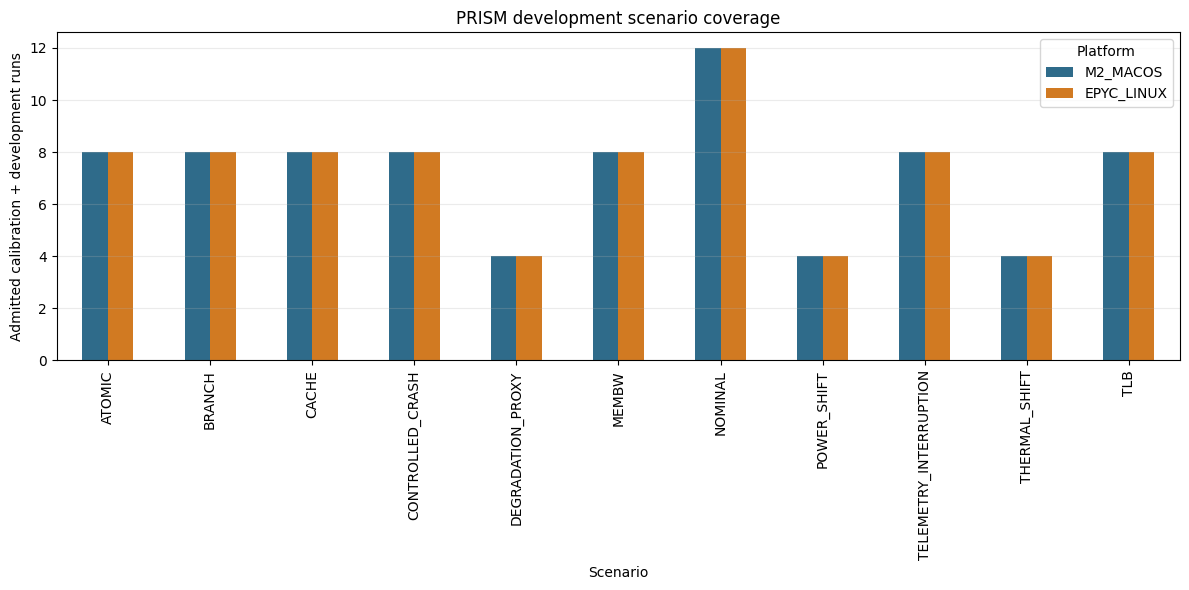

In [40]:
coverage_plot = SCENARIO_COVERAGE_TABLE[["M2_MACOS", "EPYC_LINUX"]]
figure, axis = plt.subplots(figsize=(12, 6))
coverage_plot.plot(kind="bar", ax=axis, color=["#2f6b8a", "#d17a22"])
axis.set_xlabel("Scenario")
axis.set_ylabel("Admitted calibration + development runs")
axis.set_title("PRISM development scenario coverage")
axis.legend(title="Platform")
axis.grid(axis="y", alpha=0.25)
figure.tight_layout()
save_paper_figure(figure, "figure-1-development-scenario-coverage.png")
plt.show()


### Table 3 — Cross-platform data-quality summary

This table reports admitted validity and sensor-quality warnings. Apple sensor
warnings are retained explicitly; they are not silently converted into valid
measurements.


In [41]:
quality_paths = {
    "M2_MACOS": RUNTIME_ROOT / "artifacts" / "data-quality" / "m2_macos.json",
    "EPYC_LINUX": (
        DATA_ROOT
        / "processed"
        / "epyc-linux-audit"
        / "epyc_linux_quality.json"
    ),
}
if all(path.exists() for path in quality_paths.values()):
    quality_rows = []
    for platform_id, quality_path in quality_paths.items():
        quality = json.loads(quality_path.read_text(encoding="utf-8"))
        critical_minima = [
            values["minimum"]
            for values in quality.get(
                "critical_channel_availability", {}
            ).values()
        ]
        quality_rows.append(
            {
                "Platform": platform_id,
                "Valid runs": quality.get("statuses", {}).get("valid", 0),
                "Invalid runs": quality.get("statuses", {}).get("invalid", 0),
                "Valid benign hours": quality.get("valid_benign_hours", 0.0),
                "Warning events": sum(
                    quality.get("warning_counts", {}).values()
                ),
                "Failure events": sum(
                    quality.get("failure_counts", {}).values()
                ),
                "Minimum critical availability": (
                    min(critical_minima) if critical_minima else float("nan")
                ),
            }
        )
    DATA_QUALITY_TABLE = pd.DataFrame(quality_rows)
    save_paper_table(DATA_QUALITY_TABLE, "table-3-data-quality.csv")
else:
    DATA_QUALITY_TABLE = pd.read_csv(
        PAPER_TABLE_ROOT / "table-3-data-quality.csv"
    )
display(DATA_QUALITY_TABLE.round(3))


Saved table: /Users/hsiaopingni/Documents/New project/PRISM-SLM/paper/results/development/table-3-data-quality.csv


,Platform,Valid runs,Invalid runs,Valid benign hours,Warning events,Failure events,Minimum critical availability
0,M2_MACOS,80,0,4.799,86,0,0.815
1,EPYC_LINUX,80,0,4.799,0,0,1.000


### Table 4 — Headline detector comparison

This is the principal development ablation: the static VAR control versus the
guarded, drift-aware VAR at each method's lowest-false-alert detecting operating
point. It must be labeled development evidence in the draft.


In [42]:
headline_rows = []
for label, report in PAPER_REPORTS.items():
    candidate = (
        report.get("selected")
        or report["lowest_false_alert_detecting_candidate"]
    )
    robust_report = label == "Robust residual fusion"
    false_alert_rate = (
        candidate["fah"] if robust_report
        else candidate["false_alerts_per_hour"]
    )
    detected_runs = (
        candidate["detected"] if robust_report
        else candidate["detected_runs"]
    )
    anomaly_runs = (
        candidate["runs"] if robust_report
        else candidate["anomaly_runs"]
    )
    detection_rate = (
        candidate["detection"] if robust_report
        else candidate["anomaly_run_detection_rate"]
    )
    median_ttd = (
        candidate["ttd"] if robust_report
        else candidate["median_time_to_detect_seconds"]
    )
    headline_rows.append(
        {
            "Method": label,
            "Candidates evaluated": report["candidate_count"],
            "False alerts": candidate["false_alerts"],
            "Benign hours": candidate["benign_hours"],
            "False alerts/hour": false_alert_rate,
            "Detected anomaly runs": (
                f"{detected_runs}/{anomaly_runs}"
            ),
            "Detection (%)": 100.0 * detection_rate,
            "Median TTD (s)": median_ttd,
            "Telemetry-fault ID (%)": (
                float("nan") if robust_report
                else 100.0 * candidate["telemetry_fault_identification_rate"]
            ),
            "G3": "PASS" if report["gate_passed"] else "FAIL",
        }
    )
HEADLINE_METHOD_TABLE = pd.DataFrame(headline_rows)
save_paper_table(
    HEADLINE_METHOD_TABLE, "table-4-headline-method-comparison.csv"
)
display(HEADLINE_METHOD_TABLE.round(3))
print("G3 targets: false alerts/hour <= 0.25; detection >= 50%.")


Saved table: /Users/hsiaopingni/Documents/New project/PRISM-SLM/paper/results/development/table-4-headline-method-comparison.csv


,Method,Candidates evaluated,False alerts,Benign hours,False alerts/hour,Detected anomaly runs,Detection (%),Median TTD (s),Telemetry-fault ID (%),G3
0,Static VAR,57,311,12.533,24.814,117/120,97.500,92.497,100.0,FAIL
1,Guarded adaptive VAR,88,9,10.000,0.900,53/120,44.167,172.487,100.0,FAIL


G3 targets: false alerts/hour <= 0.25; detection >= 50%.


### Figure 2 — Candidate detection/false-alert tradeoff

This figure shows every evaluated static and guarded operating point. The shaded
upper-left region is the predeclared G3 feasibility region.


Saved PNG: /Users/hsiaopingni/Documents/New project/PRISM-SLM/paper/figures/development/figure-2-development-operating-points.png


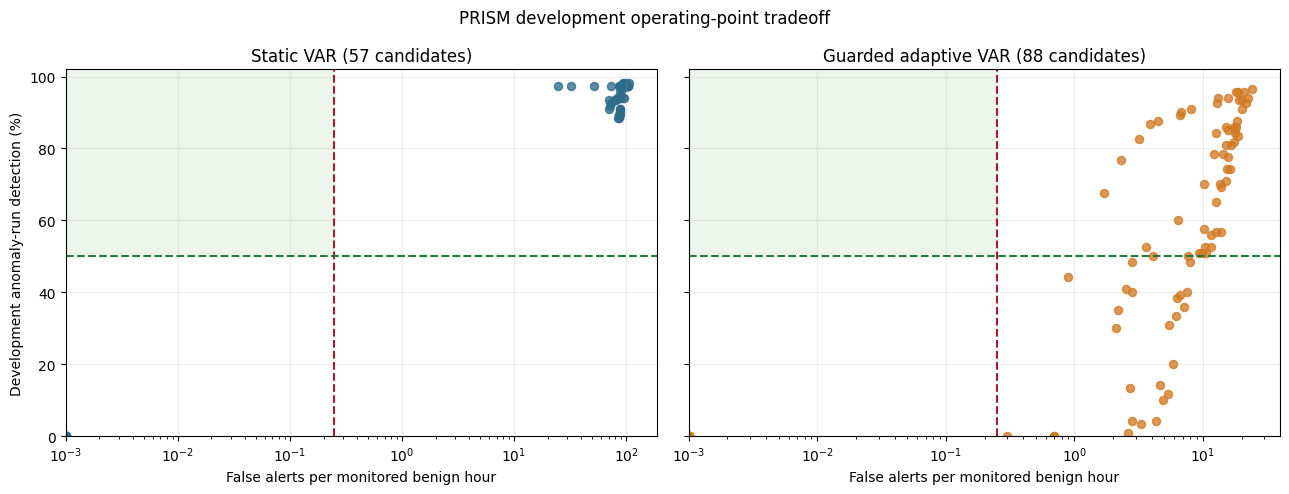

In [43]:
figure, axes = plt.subplots(1, len(PAPER_CANDIDATES), figsize=(6 * len(PAPER_CANDIDATES), 5), sharey=True)
if len(PAPER_CANDIDATES) == 1:
    axes = [axes]
colors = {
    "Static VAR": "#2f6b8a",
    "Guarded adaptive VAR": "#d17a22",
    "Robust residual fusion": "#2a9d8f",
}
for axis, (label, candidates) in zip(axes, PAPER_CANDIDATES.items()):
    if label == "Robust residual fusion":
        x_values = candidates["fah"].clip(lower=1e-3)
        y_values = 100.0 * candidates["detection"]
    else:
        x_values = candidates["false_alerts_per_hour"].clip(lower=1e-3)
        y_values = 100.0 * candidates["anomaly_run_detection_rate"]
    axis.scatter(x_values, y_values, s=34, alpha=0.78, color=colors[label])
    axis.axvline(0.25, color="#a51c30", linestyle="--", linewidth=1.5)
    axis.axhline(50.0, color="#237a3b", linestyle="--", linewidth=1.5)
    axis.axvspan(1e-3, 0.25, ymin=0.5, ymax=1.0, color="#4daf4a", alpha=0.10)
    axis.set_xscale("log")
    axis.set_xlim(left=1e-3)
    axis.set_ylim(0, 102)
    axis.set_title(f"{label} ({len(candidates)} candidates)")
    axis.set_xlabel("False alerts per monitored benign hour")
    axis.grid(alpha=0.22)
axes[0].set_ylabel("Development anomaly-run detection (%)")
figure.suptitle("PRISM development operating-point tradeoff")
figure.tight_layout()
save_paper_figure(figure, "figure-2-development-operating-points.png")
plt.show()


### Figure 3 — Headline static-versus-adaptive performance

This two-panel figure makes the central development tradeoff explicit: guarded
adaptation sharply reduces false alerts, but the current operating point remains
below the minimum detection target.


Saved PNG: /Users/hsiaopingni/Documents/New project/PRISM-SLM/paper/figures/development/figure-3-headline-method-performance.png


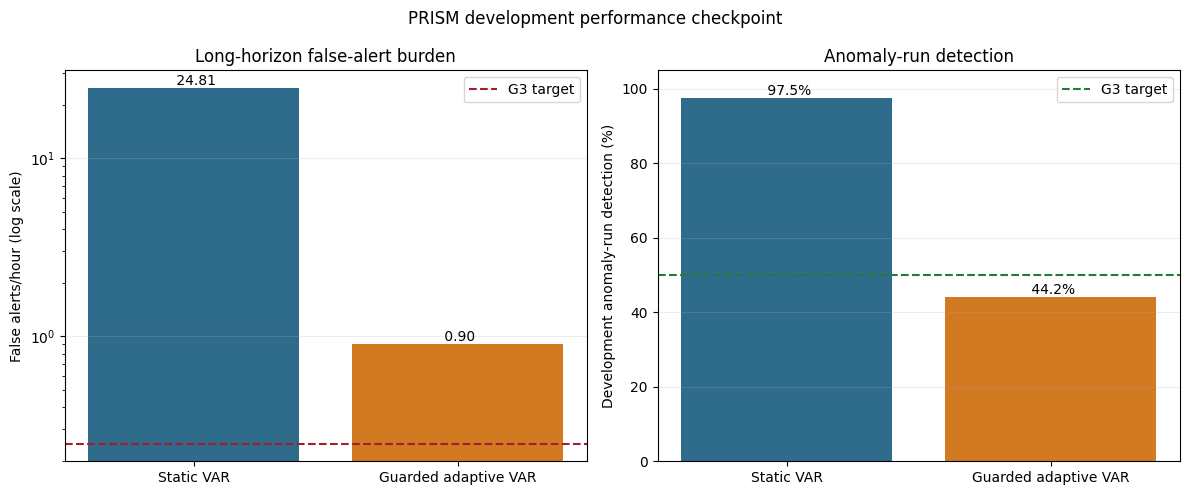

In [44]:
method_labels = HEADLINE_METHOD_TABLE["Method"].tolist()
method_colors = [
    {"Static VAR": "#2f6b8a", "Guarded adaptive VAR": "#d17a22", "Robust residual fusion": "#2a9d8f"}[label]
    for label in method_labels
]
figure, axes = plt.subplots(1, 2, figsize=(12, 5))

false_alert_values = HEADLINE_METHOD_TABLE["False alerts/hour"]
axes[0].bar(method_labels, false_alert_values, color=method_colors)
axes[0].axhline(0.25, color="#a51c30", linestyle="--", label="G3 target")
axes[0].set_yscale("log")
axes[0].set_ylabel("False alerts/hour (log scale)")
axes[0].set_title("Long-horizon false-alert burden")
axes[0].legend()
for index, value in enumerate(false_alert_values):
    axes[0].text(index, value, f" {value:.2f}", ha="center", va="bottom")

detection_values = HEADLINE_METHOD_TABLE["Detection (%)"]
axes[1].bar(method_labels, detection_values, color=method_colors)
axes[1].axhline(50.0, color="#237a3b", linestyle="--", label="G3 target")
axes[1].set_ylim(0, 105)
axes[1].set_ylabel("Development anomaly-run detection (%)")
axes[1].set_title("Anomaly-run detection")
axes[1].legend()
for index, value in enumerate(detection_values):
    axes[1].text(index, value, f" {value:.1f}%", ha="center", va="bottom")

for axis in axes:
    axis.grid(axis="y", alpha=0.22)
figure.suptitle("PRISM development performance checkpoint")
figure.tight_layout()
save_paper_figure(figure, "figure-3-headline-method-performance.png")
plt.show()


### Table 5 — Guarded adaptation safety audit

This result supports the safe-updating contribution by reporting accepted and
rejected updates, fault freezes, shadow-model promotions, and rollbacks.


In [45]:
guarded_audit = PAPER_REPORTS["Guarded adaptive VAR"]["guarded_update_audit_totals"]
GUARDED_AUDIT_TABLE = pd.DataFrame(
    [
        {"Audit event": key.replace("_", " "), "Count": value}
        for key, value in guarded_audit.items()
    ]
).sort_values("Count", ascending=False)
GUARDED_AUDIT_TABLE = GUARDED_AUDIT_TABLE.reset_index(drop=True)
save_paper_table(
    GUARDED_AUDIT_TABLE, "table-5-guarded-update-audit.csv"
)
display(GUARDED_AUDIT_TABLE)


Saved table: /Users/hsiaopingni/Documents/New project/PRISM-SLM/paper/results/development/table-5-guarded-update-audit.csv


,Audit event,Count
0,accepted updates,17767
1,rejected updates,6929
2,promotions,1402
3,fault freezes,192
4,rollbacks,9


### Figure 4 — Guarded adaptation safety audit

The audit visualizes how often the online learner accepted evidence, rejected
unsafe updates, froze during telemetry faults, promoted shadow models, or rolled
back after an adverse promotion.


Saved PNG: /Users/hsiaopingni/Documents/New project/PRISM-SLM/paper/figures/development/figure-4-guarded-update-audit.png


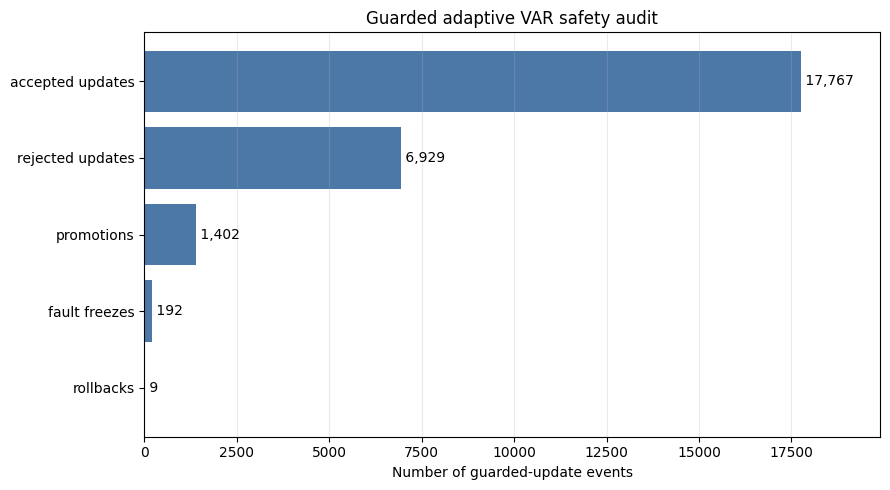

In [46]:
figure, axis = plt.subplots(figsize=(9, 5))
axis.barh(
    GUARDED_AUDIT_TABLE["Audit event"],
    GUARDED_AUDIT_TABLE["Count"],
    color="#4c78a8",
)
axis.invert_yaxis()
axis.set_xlabel("Number of guarded-update events")
axis.set_title("Guarded adaptive VAR safety audit")
axis.grid(axis="x", alpha=0.25)
axis.margins(x=0.12)
for row_index, value in enumerate(GUARDED_AUDIT_TABLE["Count"]):
    axis.text(value, row_index, f" {value:,}", va="center")
figure.tight_layout()
save_paper_figure(figure, "figure-4-guarded-update-audit.png")
plt.show()


### Figure 5 — PRISM research progression and gate status

This figure is for progress reviews and the draft-development record. It shows
which evidence stages are complete and why transfer, method freeze, and locked
testing remain closed.


Saved PNG: /Users/hsiaopingni/Documents/New project/PRISM-SLM/paper/figures/development/figure-5-research-progression.png


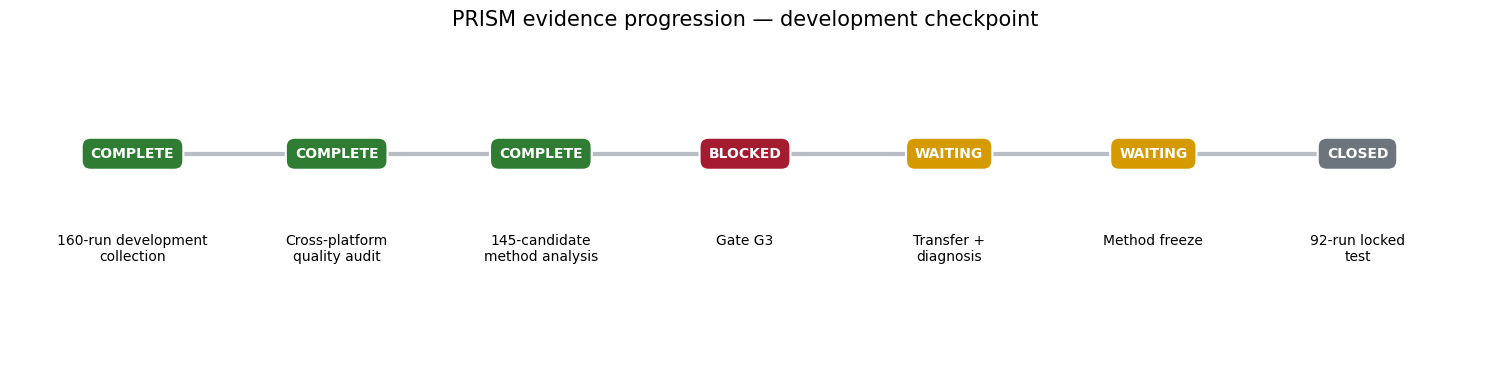

In [47]:
g3_passed = PAPER_REPORTS.get("Robust residual fusion", {}).get("gate_passed", False)
progression = [
    ("160-run development\ncollection", "COMPLETE", "#2e7d32"),
    ("Cross-platform\nquality audit", "COMPLETE", "#2e7d32"),
    ("4,836-candidate\nnormalization analysis", "COMPLETE", "#2e7d32"),
    ("Gate G3", "PASS" if g3_passed else "BLOCKED", "#2e7d32" if g3_passed else "#a51c30"),
    ("Transfer +\ndiagnosis", "READY" if g3_passed else "WAITING", "#d49a00"),
    ("Method freeze", "READY" if g3_passed else "WAITING", "#d49a00"),
    ("92-run locked\ntest", "CLOSED", "#6c757d"),
]
figure, axis = plt.subplots(figsize=(15, 3.8))
axis.plot(range(len(progression)), [0] * len(progression), color="#b8bec4", linewidth=3)
for index, (stage, status, color) in enumerate(progression):
    axis.text(
        index,
        0,
        status,
        ha="center",
        va="center",
        color="white",
        fontsize=10,
        fontweight="bold",
        zorder=3,
        bbox={
            "boxstyle": "round,pad=0.65",
            "facecolor": color,
            "edgecolor": "white",
            "linewidth": 1.5,
        },
    )
    axis.text(index, -0.37, stage, ha="center", va="top", fontsize=10)
axis.set_xlim(-0.6, len(progression) - 0.4)
axis.set_ylim(-0.95, 0.55)
axis.set_title("PRISM evidence progression — development checkpoint", fontsize=15)
axis.axis("off")
figure.tight_layout()
save_paper_figure(figure, "figure-5-research-progression.png")
plt.show()


### Supplement — Complete candidate tables

These full tables provide every evaluated development operating point for
reproducibility and supplementary-material review.


In [48]:
for label, candidates in PAPER_CANDIDATES.items():
    sort_columns = (
        ["fah", "detection"]
        if label == "Robust residual fusion"
        else ["false_alerts_per_hour", "anomaly_run_detection_rate"]
    )
    ordered = candidates.sort_values(
        sort_columns,
        ascending=[True, False],
    ).reset_index(drop=True)
    display(Markdown(f"#### {label}: all {len(ordered)} candidates"))
    display(ordered)

print("Development artifacts:")
for label, paths in PAPER_RESULT_FILES.items():
    print(f"{label}:")
    for path in paths:
        print(f"  {path}")
print()
print("Gate G3 remains closed unless a displayed report says gate_passed=true.")
print("Do not use these development tables as locked-test claims.")


#### Static VAR: all 57 candidates

,method,family,detector,parameters,false_alerts,benign_hours,false_alerts_per_hour,anomaly_runs,detected_runs,anomaly_run_detection_rate,median_time_to_detect_seconds,interruption_runs,telemetry_fault_identification_rate
0,DICE_RIDGE_PERSISTENCE,ridge,persistence,"{""alpha"": 0.01, ""consecutive"": 2, ""cooldown_bl...",0,12.533333,0.000000,120,0,0.000000,NaN,16,1.0
1,DICE_RIDGE_PERSISTENCE,ridge,persistence,"{""alpha"": 0.01, ""consecutive"": 3, ""cooldown_bl...",0,12.533333,0.000000,120,0,0.000000,NaN,16,1.0
2,DICE_RIDGE_PERSISTENCE,ridge,persistence,"{""alpha"": 0.01, ""consecutive"": 5, ""cooldown_bl...",0,12.533333,0.000000,120,0,0.000000,NaN,16,1.0
3,STATIC_VAR_PERSISTENCE,var,persistence,"{""alpha"": 0.01, ""consecutive"": 2, ""cooldown_bl...",0,12.533333,0.000000,120,0,0.000000,NaN,16,1.0
4,STATIC_VAR_PERSISTENCE,var,persistence,"{""alpha"": 0.01, ""consecutive"": 3, ""cooldown_bl...",0,12.533333,0.000000,120,0,0.000000,NaN,16,1.0
5,STATIC_VAR_PERSISTENCE,var,persistence,"{""alpha"": 0.01, ""consecutive"": 5, ""cooldown_bl...",0,12.533333,0.000000,120,0,0.000000,NaN,16,1.0
6,STATIC_VAR_SEQUENTIAL_CONFORMAL,var,eprocess,"{""cooldown_blocks"": 6, ""eta"": 0.9, ""log_thresh...",311,12.533333,24.813830,120,117,0.975000,92.496878,16,1.0
7,STATIC_VAR_SEQUENTIAL_CONFORMAL,var,eprocess,"{""cooldown_blocks"": 6, ""eta"": 0.9, ""log_thresh...",402,12.533333,32.074468,120,117,0.975000,42.497977,16,1.0
8,STATIC_VAR_SEQUENTIAL_CONFORMAL,var,eprocess,"{""cooldown_blocks"": 6, ""eta"": 0.9, ""log_thresh...",653,12.533333,52.101064,120,117,0.975000,42.496284,16,1.0
9,STATIC_VAR_PERSISTENCE,var,persistence,"{""alpha"": 0.02, ""consecutive"": 5, ""cooldown_bl...",886,12.533333,70.691489,120,112,0.933333,7.498068,16,1.0


#### Guarded adaptive VAR: all 88 candidates

,method,family,detector,parameters,false_alerts,benign_hours,false_alerts_per_hour,anomaly_runs,detected_runs,anomaly_run_detection_rate,median_time_to_detect_seconds,interruption_runs,telemetry_fault_identification_rate
0,GUARDED_VAR_PERSISTENCE,guarded_var,persistence,"{""alpha"": 0.005, ""consecutive"": 3, ""cooldown_b...",0,10.0,0.0,120,0,0.000000,NaN,16,1.0
1,GUARDED_VAR_PERSISTENCE,guarded_var,persistence,"{""alpha"": 0.005, ""consecutive"": 5, ""cooldown_b...",0,10.0,0.0,120,0,0.000000,NaN,16,1.0
2,GUARDED_VAR_PERSISTENCE,guarded_var,persistence,"{""alpha"": 0.005, ""consecutive"": 8, ""cooldown_b...",0,10.0,0.0,120,0,0.000000,NaN,16,1.0
3,GUARDED_VAR_PERSISTENCE,guarded_var,persistence,"{""alpha"": 0.005, ""consecutive"": 12, ""cooldown_...",0,10.0,0.0,120,0,0.000000,NaN,16,1.0
4,GUARDED_VAR_PERSISTENCE,guarded_var,persistence,"{""alpha"": 0.001, ""consecutive"": 3, ""cooldown_b...",0,10.0,0.0,120,0,0.000000,NaN,16,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
83,GUARDED_VAR_CUSUM,guarded_var,cusum,"{""cooldown_blocks"": 12, ""reference"": 0.5, ""thr...",202,10.0,20.2,120,112,0.933333,12.493468,16,1.0
84,GUARDED_VAR_SEQUENTIAL_CONFORMAL,guarded_var,eprocess,"{""cooldown_blocks"": 12, ""eta"": 0.5, ""log_thres...",208,10.0,20.8,120,115,0.958333,27.498505,16,1.0
85,GUARDED_VAR_CUSUM,guarded_var,cusum,"{""cooldown_blocks"": 12, ""reference"": 1.0, ""thr...",215,10.0,21.5,120,111,0.925000,7.496950,16,1.0
86,GUARDED_VAR_CUSUM,guarded_var,cusum,"{""cooldown_blocks"": 12, ""reference"": 0.5, ""thr...",225,10.0,22.5,120,113,0.941667,7.498097,16,1.0


Development artifacts:
Static VAR:
  /Users/hsiaopingni/Documents/New project/PRISM-SLM/data/processed/prism-analysis-v1/development-method-selection.json
  /Users/hsiaopingni/Documents/New project/PRISM-SLM/data/processed/prism-analysis-v1/development-method-selection.csv
Guarded adaptive VAR:
  /Users/hsiaopingni/Documents/New project/PRISM-SLM/data/processed/prism-analysis-v1/development-guarded-method-selection.json
  /Users/hsiaopingni/Documents/New project/PRISM-SLM/data/processed/prism-analysis-v1/development-guarded-method-selection.csv

Gate G3 remains closed unless a displayed report says gate_passed=true.
Do not use these development tables as locked-test claims.


## 18. Zero-shot transfer and few-shot destination calibration

Transfer is evaluated without matching native channel names. At zero
destination minutes, the source platform's semantic model, robust scales,
residual calibration, and frozen detector configuration are applied without
refitting. At positive minutes, a chronological prefix of the destination
nominal calibration run is divided into fitting and score-calibration
portions. Development runs remain the evaluation unit.

The default curve is 0, 1, 2, 4, 8, and 12 benign minutes. These are method
development results, not locked-test claims.


In [ ]:
RUN_TRANSFER_ANALYSIS = False
CALIBRATION_MINUTES = (0, 1, 2, 4, 8, 12)
TRANSFER_RESULTS_CSV = ANALYSIS_ROOT / "development-transfer-calibration.csv"


def find_calibration_run(
    cache: dict[str, Any],
    platform_id: str,
    workload: str,
) -> dict[str, Any]:
    matches = [
        run
        for run in cache["runs"].values()
        if run["platform_id"] == platform_id
        and run["workload"] == workload
        and run["planned_split"] == "calibration"
        and run["scenario"] == "NOMINAL"
    ]
    if len(matches) != 1:
        raise RuntimeError(
            f"Expected one calibration run for {platform_id}/{workload}; "
            f"found {len(matches)}"
        )
    return matches[0]


def fit_robust_transfer_classifier(
    cache: dict[str, Any],
    source_platform: str,
    workload: str,
    selected: dict[str, Any],
    source_micro_twin: dict[str, Any],
) -> LogisticRegression:
    """Fit the frozen source-side fusion rule without destination event labels."""
    negative_blocks: list[np.ndarray] = []
    positive_blocks: list[np.ndarray] = []
    for run in cache["runs"].values():
        if run["planned_split"] != "development":
            continue
        if run["platform_id"] != source_platform or run["workload"] != workload:
            continue
        features = robust_local_features(run, source_micro_twin)
        indices = np.arange(len(features))
        valid = ~np.asarray(run["fault"], dtype=bool)
        after_startup = indices >= SELF_REFERENCE_STARTUP_BLOCKS
        onset = run["onset_seconds"]
        if onset is None:
            negative = deterministic_run_sample(
                np.flatnonzero(valid & after_startup),
                run["run_id"],
                NEGATIVE_BLOCKS_PER_RUN,
                "transfer-negative",
            )
            negative_blocks.append(features[negative])
        elif run["scenario"] != "TELEMETRY_INTERRUPTION":
            positive = deterministic_run_sample(
                np.flatnonzero(
                    valid
                    & (run["t"] >= onset)
                    & (
                        run["t"]
                        < onset + POSITIVE_BLOCKS_PER_RUN * BLOCK_SECONDS
                    )
                ),
                run["run_id"],
                POSITIVE_BLOCKS_PER_RUN,
                "transfer-positive",
            )
            positive_blocks.append(features[positive])
    if not negative_blocks or not positive_blocks:
        raise RuntimeError(
            f"Incomplete source transfer evidence for {source_platform}/{workload}"
        )
    negative = np.concatenate(negative_blocks)
    positive = np.concatenate(positive_blocks)
    X = np.concatenate([negative, positive])
    y = np.concatenate([
        np.zeros(len(negative), dtype=int),
        np.ones(len(positive), dtype=int),
    ])
    finite = np.all(np.isfinite(X), axis=1)
    model = LogisticRegression(
        C=float(selected["model_configuration"]["regularization_C"]),
        class_weight="balanced",
        max_iter=2000,
        solver="liblinear",
        random_state=123,
    )
    model.fit(X[finite], y[finite])
    return model


def fit_robust_transfer_bundle(
    cache: dict[str, Any],
    source_platform: str,
    destination_platform: str,
    workload: str,
    selected: dict[str, Any],
    destination_minutes: int,
) -> dict[str, Any]:
    """Keep the source classifier fixed; adapt only on benign calibration."""
    source_run = find_calibration_run(cache, source_platform, workload)
    source_states = compact_semantic_sequence(source_run["x"])
    source_micro_twin = fit_compact_var(
        [source_states],
        ROBUST_MICRO_TWIN_CONFIG["lags"],
        ROBUST_MICRO_TWIN_CONFIG["penalty"],
    )
    classifier = fit_robust_transfer_classifier(
        cache, source_platform, workload, selected, source_micro_twin
    )
    if destination_minutes == 0:
        destination_micro_twin = source_micro_twin
    else:
        destination_run = find_calibration_run(
            cache, destination_platform, workload
        )
        usable_blocks = int(destination_minutes * 60.0 / BLOCK_SECONDS)
        if usable_blocks <= ROBUST_MICRO_TWIN_CONFIG["lags"]:
            raise ValueError("Destination calibration is too short for the VAR lag")
        destination_states = compact_semantic_sequence(
            destination_run["x"]
        )[:usable_blocks]
        destination_micro_twin = fit_compact_var(
            [destination_states],
            ROBUST_MICRO_TWIN_CONFIG["lags"],
            ROBUST_MICRO_TWIN_CONFIG["penalty"],
        )
    return {
        "model": classifier,
        "micro_twin": destination_micro_twin,
        "source_platform": source_platform,
        "destination_platform": destination_platform,
        "destination_calibration_minutes": destination_minutes,
    }


def fit_selected_transfer_bundle(
    run: dict[str, Any],
    selected: dict[str, Any],
    usable_blocks: int | None,
) -> dict[str, Any]:
    family = selected["family"]
    if family == "robust_normalized_fusion":
        raise ValueError(
            "Use fit_robust_transfer_bundle for robust normalized fusion"
        )
    if family == "compact_guarded_var":
        return fit_compact_bundle_from_run(
            run,
            selected["model_configuration"],
            usable_blocks=usable_blocks,
        )
    base_family = "var" if family == "guarded_var" else family
    if base_family not in {"ridge", "var"}:
        raise ValueError(f"Unsupported transfer family: {family}")
    return fit_bundle_from_run(
        run,
        base_family,
        usable_blocks=usable_blocks,
    )


def selected_alert_trace(
    selected: dict[str, Any],
    bundle: dict[str, Any],
    run: dict[str, Any],
) -> tuple[np.ndarray, np.ndarray]:
    family = selected["family"]
    if family == "robust_normalized_fusion":
        features = robust_local_features(run, bundle["micro_twin"])
        score = np.full(len(features), np.nan)
        finite = np.all(np.isfinite(features), axis=1)
        score[finite] = bundle["model"].predict_proba(features[finite])[:, 1]
        indices = np.arange(len(score))
        detector_fault = (
            np.asarray(run["fault"], dtype=bool)
            | (indices < SELF_REFERENCE_STARTUP_BLOCKS)
        )
        alerts, _ = episode_alerts(
            "z_persistence",
            score,
            np.ones(len(score)),
            detector_fault,
            {
                "z_threshold": selected["parameters"]["probability_threshold"],
                "threshold": selected["parameters"]["consecutive_blocks"],
                "reset_ratio": selected["parameters"]["reset_ratio"],
                "reset_blocks": selected["parameters"]["reset_blocks"],
            },
        )
        return alerts, detector_fault
    if family == "compact_guarded_var":
        compact_run = {
            **run,
            "x": compact_semantic_sequence(run["x"]),
        }
        trace = guarded_var_trace(bundle, compact_run)
        alerts, _ = episode_alerts(
            selected["detector"],
            trace["robust_z"],
            trace["pvalues"],
            trace["detector_fault"],
            selected["parameters"],
        )
        return alerts, trace["detector_fault"]
    if family == "guarded_var":
        trace = guarded_var_trace(bundle, run)
        alerts = guarded_sequential_alerts(
            selected["detector"],
            trace["robust_z"],
            trace["pvalues"],
            trace["detector_fault"],
            selected["parameters"],
        )
        return alerts, trace["detector_fault"]
    scores = score_sequence(bundle["model"], run["x"])
    pvalues = conformal_tail_pvalues(
        scores, bundle["calibration_scores"]
    )
    alerts = sequential_alerts(
        selected["detector"],
        scores,
        pvalues,
        run["fault"],
        selected["parameters"],
        bundle["score_center"],
        bundle["score_scale"],
    )
    return alerts, np.asarray(run["fault"], dtype=bool)


def evaluate_selected_transfer(
    cache: dict[str, Any],
    selected: dict[str, Any],
    destination_platform: str,
    bundles: dict[str, dict[str, Any]],
) -> dict[str, Any]:
    false_alerts = 0
    benign_seconds = 0.0
    detected = 0
    anomaly_runs = 0
    delays: list[float] = []
    interruption_runs = 0
    interruption_identified = 0
    for run in cache["runs"].values():
        if run["planned_split"] != "development":
            continue
        if run["platform_id"] != destination_platform:
            continue
        alerts, detector_fault = selected_alert_trace(
            selected, bundles[run["workload"]], run
        )
        onset = run["onset_seconds"]
        if onset is None:
            benign = ~detector_fault
        else:
            benign = (run["t"] < onset) & (~detector_fault)
        false_alerts += int(np.sum(alerts & benign))
        benign_seconds += float(np.sum(benign) * BLOCK_SECONDS)
        if run["scenario"] == "TELEMETRY_INTERRUPTION":
            interruption_runs += 1
            if onset is not None and np.any(
                run["fault"] & (run["t"] >= onset)
            ):
                interruption_identified += 1
            continue
        if onset is None:
            continue
        anomaly_runs += 1
        post = np.flatnonzero(alerts & (run["t"] >= onset))
        if post.size:
            detected += 1
            delays.append(float(run["t"][post[0]] - onset))
    benign_hours = benign_seconds / 3600.0
    return {
        "method": selected.get("method", selected["family"]),
        "family": selected["family"],
        "detector": selected["detector"],
        "parameters": selected["parameters"],
        "false_alerts": false_alerts,
        "benign_hours": benign_hours,
        "false_alerts_per_hour": (
            false_alerts / benign_hours if benign_hours else math.inf
        ),
        "anomaly_runs": anomaly_runs,
        "detected_runs": detected,
        "anomaly_run_detection_rate": (
            detected / anomaly_runs if anomaly_runs else float("nan")
        ),
        "median_time_to_detect_seconds": (
            float(np.median(delays)) if delays else float("nan")
        ),
        "interruption_runs": interruption_runs,
        "telemetry_fault_identification_rate": (
            interruption_identified / interruption_runs
            if interruption_runs
            else float("nan")
        ),
    }


def transfer_calibration_curve_selected(
    cache: dict[str, Any],
    selected: dict[str, Any],
) -> list[dict[str, Any]]:
    if selected is None:
        raise RuntimeError(
            "Transfer analysis is blocked because Gate G3 has no selected "
            "development configuration."
        )
    records: list[dict[str, Any]] = []
    for source_platform, destination_platform in (
        ("M2_MACOS", "EPYC_LINUX"),
        ("EPYC_LINUX", "M2_MACOS"),
    ):
        for minutes in CALIBRATION_MINUTES:
            bundles: dict[str, dict[str, Any]] = {}
            for workload in ("PY_STATS", "PY_AI", "BROWSER", "VIDEO_SW"):
                calibration_platform = (
                    source_platform if minutes == 0 else destination_platform
                )
                calibration_run = find_calibration_run(
                    cache, calibration_platform, workload
                )
                usable_blocks = (
                    None
                    if minutes == 0
                    else int(minutes * 60.0 / BLOCK_SECONDS)
                )
                if selected["family"] == "robust_normalized_fusion":
                    bundles[workload] = fit_robust_transfer_bundle(
                        cache,
                        source_platform,
                        destination_platform,
                        workload,
                        selected,
                        minutes,
                    )
                else:
                    bundles[workload] = fit_selected_transfer_bundle(
                        calibration_run,
                        selected,
                        usable_blocks,
                    )
            result = evaluate_selected_transfer(
                cache, selected, destination_platform, bundles
            )
            records.append(
                {
                    "source_platform": source_platform,
                    "destination_platform": destination_platform,
                    "destination_calibration_minutes": minutes,
                    **result,
                }
            )
    return records


TRANSFER_RESULTS = None
if RUN_TRANSFER_ANALYSIS:
    if PREFREEZE_AUDIT is None:
        PREFREEZE_AUDIT = audit_prefreeze_dataset(
            VERIFY_ALL_RAW_CHECKSUMS
        )
    if SEMANTIC_CACHE is None:
        SEMANTIC_CACHE = load_semantic_cache(
            expected_fingerprint=PREFREEZE_AUDIT["dataset_fingerprint"]
        )
    if not DEVELOPMENT_SELECTION_JSON.exists():
        raise FileNotFoundError(
            "Run Section 17B to write the authoritative development "
            "selection before transfer analysis."
        )
    development_selection = json.loads(
        DEVELOPMENT_SELECTION_JSON.read_text(encoding="utf-8")
    )
    if not development_selection.get("gate_passed"):
        raise RuntimeError(
            "Gate G3 has not passed; transfer analysis remains blocked."
        )
    if (
        development_selection["dataset_fingerprint"]
        != PREFREEZE_AUDIT["dataset_fingerprint"]
    ):
        raise RuntimeError(
            "Authoritative selection does not match the audited dataset."
        )
    TRANSFER_RESULTS = transfer_calibration_curve_selected(
        SEMANTIC_CACHE,
        development_selection["selected"],
    )
    write_csv_records(TRANSFER_RESULTS_CSV, TRANSFER_RESULTS)
    for result in TRANSFER_RESULTS:
        print(
            result["source_platform"],
            "->",
            result["destination_platform"],
            f"{result['destination_calibration_minutes']:>2} min",
            f"FAH={result['false_alerts_per_hour']:.3f}",
            f"detection={result['anomaly_run_detection_rate']:.3f}",
        )
else:
    print(
        "Set RUN_TRANSFER_ANALYSIS=True only after the authoritative "
        "development selection passes Gate G3."
    )


## 19. Explicit method freeze before locked-test collection

This gate writes the sole tracked method-freeze artifact. It records the
raw-manifest fingerprint, feature dictionary, block duration, selected
detector, parameter tuple, and development metrics. It refuses to freeze if
any locked-test row is already valid or if notebook source differs from the
current Git revision. Notebook outputs and execution counts do not affect
the source comparison.

Krish should review the generated artifact before either platform's locked
rows are explicitly enabled. After freeze, no feature, model, threshold,
reset, abstention, or exclusion rule may be tuned from locked-test outcomes.


In [ ]:
FREEZE_METHOD = False
METHOD_FREEZE_PATH = REPO_ROOT / "paper" / "method-freeze.json"


def notebook_source_digest(notebook_bytes: bytes) -> str:
    notebook = json.loads(notebook_bytes)
    canonical = [
        {
            "cell_type": cell.get("cell_type"),
            "metadata": cell.get("metadata", {}),
            "source": cell.get("source", []),
        }
        for cell in notebook.get("cells", [])
    ]
    return hashlib.sha256(
        json.dumps(canonical, sort_keys=True).encode("utf-8")
    ).hexdigest()


def assert_notebook_source_committed() -> str:
    revision = subprocess.check_output(
        ["git", "rev-parse", "HEAD"], cwd=REPO_ROOT, text=True
    ).strip()
    committed = subprocess.check_output(
        [
            "git",
            "show",
            f"{revision}:notebooks/PRISM_Complete_Experiment.ipynb",
        ],
        cwd=REPO_ROOT,
    )
    current = (
        REPO_ROOT / "notebooks" / "PRISM_Complete_Experiment.ipynb"
    ).read_bytes()
    if notebook_source_digest(committed) != notebook_source_digest(current):
        raise RuntimeError(
            "Notebook source is not committed. Commit and push the analysis "
            "revision before freezing the method."
        )
    return revision


def freeze_method() -> Path:
    audit = audit_prefreeze_dataset(verify_checksums=True)
    if not DEVELOPMENT_SELECTION_JSON.exists():
        raise FileNotFoundError(
            "Run Section 17B before freezing the method."
        )
    selection = json.loads(
        DEVELOPMENT_SELECTION_JSON.read_text(encoding="utf-8")
    )
    if not selection.get("gate_passed") or selection.get("selected") is None:
        raise RuntimeError(
            "Gate G3 has not passed. Do not freeze or unlock the test set."
        )
    if selection["dataset_fingerprint"] != audit["dataset_fingerprint"]:
        raise RuntimeError(
            "Authoritative selection does not match the audited dataset"
        )
    if not TRANSFER_RESULTS_CSV.exists():
        raise FileNotFoundError(
            "Run and review development transfer analysis before freezing."
        )
    revision = assert_notebook_source_committed()
    artifact = {
        "status": "method_frozen_before_locked_test",
        "git_commit": revision,
        "analysis_revision": ANALYSIS_REVISION,
        "dataset_fingerprint": audit["dataset_fingerprint"],
        "block_seconds": BLOCK_SECONDS,
        "base_features": BASE_FEATURES,
        "block_features": BLOCK_FEATURES,
        "false_alert_budget_per_hour": FALSE_ALERT_BUDGET_PER_HOUR,
        "minimum_development_detection_rate": (
            MINIMUM_DEVELOPMENT_DETECTION_RATE
        ),
        "selected_development_configuration": selection["selected"],
        "development_selection_artifact": str(
            DEVELOPMENT_SELECTION_JSON
        ),
        "development_transfer_artifact": str(TRANSFER_RESULTS_CSV),
        "locked_test_policy": {
            "used_for_selection": False,
            "single_evaluation_after_freeze": True,
        },
        "l40s_role": "optional_secondary_case_not_part_of_core_freeze",
        "apple_validation_amendment": (
            "db40553 changes only controlled-crash temperature validation; "
            "13 earlier clean Apple acquisitions remain retained"
        ),
    }
    METHOD_FREEZE_PATH.write_text(
        json.dumps(artifact, indent=2, sort_keys=True) + "\n",
        encoding="utf-8",
    )
    return METHOD_FREEZE_PATH


if FREEZE_METHOD:
    print("method freeze:", freeze_method())
else:
    print(
        "Keep FREEZE_METHOD=False until Gate G3, transfer analysis, "
        "diagnosis, advisor review, and a committed notebook revision are "
        "complete. Locked-test collection remains closed."
    )


## 20. Optional NVIDIA L40S feasibility gate (P1 only)

L40S data can strengthen the paper as a **clearly labeled accelerator
observability case**, but it is not required to establish the PRISM P0
contribution. It must not delay dual-platform method selection or locked
evaluation.

A continuous GPU-only trace does **not** prove adaptive telemetry
escalation. If this P1 experiment proceeds, retain the frozen host stream as
the base tier and activate the GPU-native tier after a predeclared evidence
trigger. Include an always-on GPU ablation so escalation duty cycle,
telemetry bytes, overhead, detection delay, and diagnostic benefit can be
measured.

Suggested bounded protocol after Gate G3:

| Item | Predeclared setting |
| --- | --- |
| Device gate | Exact name contains `NVIDIA L40S`; record driver and API availability |
| Workload | `PY_AI` only; fixed software/model/seed/batch configuration |
| Conditions | nominal, GPU compute pressure, GPU memory-bandwidth pressure |
| Repetition | 3 independently restarted runs per condition |
| Timing | 720 s/run, 120 s clean pre-onset, GPU telemetry at 1 Hz |
| Native evidence | utilization, memory, power/energy, temperature, clocks, P-state, PCIe, throttle/reliability reasons, ECC availability |
| Comparison | host-only, always-on GPU, and triggered GPU tier |
| Claim boundary | accelerator observability/escalation case; not GPU lifecycle, aging, or fleet evidence |

The probe below is read-only. It stores no UUID, serial number, hostname, or
user identity. Collection remains deliberately unimplemented until the
exact L40S host, access policy, and plan amendment are approved.


In [51]:
RUN_L40S_PROBE = False
ENABLE_L40S_COLLECTION = False


def probe_l40s() -> list[dict[str, str]]:
    executable = shutil.which("nvidia-smi")
    if executable is None:
        raise RuntimeError("nvidia-smi is not available on this host")
    query = (
        "index,name,driver_version,memory.total,power.limit,"
        "temperature.gpu,pstate"
    )
    completed = subprocess.run(
        [
            executable,
            f"--query-gpu={query}",
            "--format=csv,noheader,nounits",
        ],
        check=True,
        capture_output=True,
        text=True,
    )
    fields = query.split(",")
    devices = [
        dict(zip(fields, [part.strip() for part in line.split(",")]))
        for line in completed.stdout.splitlines()
        if line.strip()
    ]
    l40s = [device for device in devices if "L40S" in device["name"].upper()]
    if not l40s:
        raise RuntimeError(
            "No NVIDIA L40S was detected. Do not substitute a different GPU "
            "without a documented protocol amendment."
        )
    return l40s


if ENABLE_L40S_COLLECTION:
    raise RuntimeError(
        "L40S collection is intentionally closed. First pass Gate G3, "
        "confirm the exact host and permissions, and commit a reviewed "
        "optional-plan amendment."
    )
if RUN_L40S_PROBE:
    print(json.dumps(probe_l40s(), indent=2))
else:
    print(
        "Optional only: run this read-only probe on the candidate GPU host "
        "after the core method passes Gate G3."
    )


Optional only: run this read-only probe on the candidate GPU host after the core method passes Gate G3.


## 21. Analysis self-checks and next gate

These synthetic checks exercise the scaler, both micro-twins, conformal
ranks, and all sequential state machines without reading research outcomes.
They are safe to run before the processed cache exists.

After development analysis passes, create and review the method-freeze
artifact. Only then return to the platform-specific batch controllers and
explicitly enable locked-test collection. The locked test is evaluated once;
it is never used to revise this notebook's method configuration.


In [ ]:
RUN_ANALYSIS_SELF_CHECKS = True


def run_analysis_self_checks() -> None:
    generator = np.random.default_rng(123)
    sequence = np.zeros((80, 6), dtype=float)
    noise = generator.normal(0.0, 0.05, size=sequence.shape)
    for index in range(1, len(sequence)):
        sequence[index] = 0.75 * sequence[index - 1] + noise[index]
    shifted = sequence.copy()
    shifted[45:, 0] += 4.0
    for family in ("ridge", "var"):
        model = fit_micro_twin([sequence[:40]], family)
        scores = score_sequence(model, shifted)
        assert np.isfinite(scores[int(model["lags"]):]).all()
        calibration = scores[int(model["lags"]):40]
        pvalues = conformal_tail_pvalues(scores, calibration)
        faults = np.zeros(len(scores), dtype=bool)
        for candidate in method_candidates():
            if candidate["family"] != family:
                continue
            alerts = sequential_alerts(
                candidate["detector"],
                scores,
                pvalues,
                faults,
                candidate["parameters"],
                float(np.median(calibration)),
                float(
                    1.4826
                    * np.median(
                        np.abs(calibration - np.median(calibration))
                    )
                    or 1.0
                ),
            )
            assert alerts.dtype == np.bool_
            assert len(alerts) == len(scores)
    guarded_model = fit_micro_twin([sequence[:40]], "var")
    guarded_calibration = score_sequence(guarded_model, sequence[:40])
    guarded_bundle = {
        "model": guarded_model,
        "calibration_scores": guarded_calibration[
            np.isfinite(guarded_calibration)
        ],
    }
    guarded_faults = np.zeros(len(shifted), dtype=bool)
    guarded_faults[20] = True
    guarded_trace = guarded_var_trace(
        guarded_bundle,
        {
            "x": shifted,
            "t": np.arange(len(shifted), dtype=float) * BLOCK_SECONDS,
            "fault": guarded_faults,
        },
    )
    assert len(guarded_trace["robust_z"]) == len(shifted)
    assert guarded_trace["audit"]["fault_freezes"] >= 1
    assert np.isfinite(guarded_trace["robust_z"][15:]).any()
    guarded_alerts = guarded_sequential_alerts(
        "z_persistence",
        guarded_trace["robust_z"],
        guarded_trace["pvalues"],
        guarded_trace["detector_fault"],
        {"threshold": 6.0, "consecutive": 3},
    )
    assert guarded_alerts.dtype == np.bool_
    assert len(guarded_alerts) == len(shifted)
    compact_source = np.zeros((24, len(BLOCK_FEATURES)), dtype=float)
    compact = compact_semantic_sequence(compact_source)
    assert compact.shape == (24, len(COMPACT_STATE_NAMES))
    assert stable_development_fold("run-a") == stable_development_fold("run-a")
    episode_scores = np.r_[np.zeros(4), np.ones(8) * 8.0, np.zeros(8)]
    episode_pvalues = np.ones(len(episode_scores), dtype=float)
    episode_faults = np.zeros(len(episode_scores), dtype=bool)
    episode, evidence = episode_alerts(
        "z_persistence",
        episode_scores,
        episode_pvalues,
        episode_faults,
        {
            "z_threshold": 6.0,
            "threshold": 2,
            "reset_ratio": 0.5,
            "reset_blocks": 3,
        },
    )
    assert int(np.sum(episode)) == 1
    assert len(evidence) == len(episode_scores)
    compact_source = np.zeros((24, len(BLOCK_FEATURES)), dtype=float)
    compact = compact_semantic_sequence(compact_source)
    assert compact.shape == (24, len(COMPACT_STATE_NAMES))
    assert stable_development_fold("run-a") == stable_development_fold("run-a")
    episode_scores = np.r_[np.zeros(4), np.ones(8) * 8.0, np.zeros(8)]
    episode_pvalues = np.ones(len(episode_scores), dtype=float)
    episode_faults = np.zeros(len(episode_scores), dtype=bool)
    episode, evidence = episode_alerts(
        "z_persistence",
        episode_scores,
        episode_pvalues,
        episode_faults,
        {
            "z_threshold": 6.0,
            "threshold": 2,
            "reset_ratio": 0.5,
            "reset_blocks": 3,
        },
    )
    assert int(np.sum(episode)) == 1
    assert len(evidence) == len(episode_scores)
    compact_source = np.zeros((24, len(BLOCK_FEATURES)), dtype=float)
    compact = compact_semantic_sequence(compact_source)
    assert compact.shape == (24, len(COMPACT_STATE_NAMES))
    assert stable_development_fold("run-a") == stable_development_fold("run-a")
    episode_scores = np.r_[np.zeros(4), np.ones(8) * 8.0, np.zeros(8)]
    episode_pvalues = np.ones(len(episode_scores), dtype=float)
    episode_faults = np.zeros(len(episode_scores), dtype=bool)
    episode, evidence = episode_alerts(
        "z_persistence",
        episode_scores,
        episode_pvalues,
        episode_faults,
        {
            "z_threshold": 6.0,
            "threshold": 2,
            "reset_ratio": 0.5,
            "reset_blocks": 3,
        },
    )
    assert int(np.sum(episode)) == 1
    assert len(evidence) == len(episode_scores)
    print("PASS: PRISM analysis functions passed synthetic self-checks.")


if RUN_ANALYSIS_SELF_CHECKS:
    run_analysis_self_checks()
else:
    print("Set RUN_ANALYSIS_SELF_CHECKS=True before method selection.")
